# 프로젝트 회고(문서가 너무 길어서 회고로 스포일러 합니다🌝)

## 1. 이번 프로젝트에서 수행한 내용

이번 프로젝트에서는 한국어 문장을 영어로 번역하는
Seq2Seq + Bahdanau Attention 모델을 직접 구성하고 학습했다.

LMS에서 요구하는 기본 구조는 다음과 같았다.

- 한국어 source: Mecab 형태소 분석
- 영어 target: `<start>`, `<end>`를 포함한 token sequence
- Encoder: GRU
- Attention: Bahdanau Attention
- Decoder: GRU
- 학습: Teacher Forcing 기반
- 추론: 이전 예측 token을 다시 Decoder 입력으로 사용하는 autoregressive decoding

전체 데이터를 정제한 후 최종적으로 58,805개의 병렬 문장을 학습에 사용했다.

B0-Mecab 모델은 10 epoch까지 학습하였고,
training loss는 다음과 같이 안정적으로 감소했다.

- Epoch 1: 5.2661
- Epoch 3: 3.1458
- Epoch 5: 2.0883
- Epoch 10: 0.9981

즉 모델의 학습 objective 자체는 정상적으로 최적화되고 있음을 확인할 수 있었다.

하지만 고정된 diagnostic 문장의 번역 결과를 비교했을 때,
loss가 가장 낮은 Epoch 10의 번역이 항상 가장 좋은 것은 아니었다.

예를 들어

`오바마는 대통령이다.`

라는 문장은

- Epoch 3: `obama is the president .`
- Epoch 5: `obama will also be on president .`
- Epoch 10: `obama will be president when he goes to the obama .`


*와 같이 변질..되어갔다...*

따라서 이번 프로젝트에서는
**학습 데이터에 대한 최적화와 새로운 문장에 대한 번역 품질 향상이
동일한 문제가 아니라는 점을 목격했다.**


## 2. 이번 프로젝트의 가장 큰 의의

처음에는 Seq2Seq와 Attention을
Encoder, Decoder, GRU, Attention이라는 각각의 개념으로 이해했다.

이번 프로젝트를 수행하면서 이 개념들이 실제 모델 안에서
어떻게 연결되는지를 하나의 데이터 흐름으로 이해할 수 있게 되었다.

한국어 문장은 먼저 token으로 분리되고 ID로 변환된 뒤
Embedding을 통해 벡터가 된다.

Encoder GRU는 이 sequence를 읽으며 각 위치의 hidden state를 만들고,
Bahdanau Attention은 Decoder가 다음 단어를 생성할 때
어느 source 위치의 정보를 상대적으로 더 참고할지를 계산한다.

Decoder는 Attention의 context와 자신의 hidden state를 이용해
target vocabulary 전체에 대한 다음 token 확률을 계산한다.

즉 이번 프로젝트를 통해 다음의 흐름을 실제 코드와 연결할 수 있었다.

`문장 → Token → ID → Embedding → Encoder → Hidden States
→ Attention → Context → Decoder → Token Logits → 다음 단어`

특히 `<start>`와 `<end>`도 단순한 표시가 아니라
Decoder가 학습하고 예측하는 token이라는 점을 이해하게 됐다.

실제 추론에서도 모델이 `<end>`를 비교적 일찍 선택하면서
내 모델의 출력이 다른 동료들의 모델보다 상대적으로 짧게 종료되는 현상을 확인했다.


## 3. Tokenizer 실험의 의미

LMS의 기본 조건인 Mecab만 사용하는 데 그치지 않고,
동일한 모델 구조와 동일한 학습 데이터에서
한국어 source tokenizer만 SentencePiece Unigram으로 변경하는
추가 ablation을 수행했다.

즉 다음 두 모델을 비교했다.

- B0: Mecab + Seq2Seq Attention
- T1: SentencePiece Unigram + 동일한 Seq2Seq Attention

모델 구조, target tokenizer, vocabulary 크기,
embedding dimension, hidden dimension, optimizer,
batch size, seed 및 학습 pair는 동일하게 유지하였다.

이를 통해 모델 구조가 아닌
**입력 representation의 차이만 비교하려고 하였다.**

결과는 한쪽 tokenizer가 항상 우수하다는 형태로 나오지 않았다.

예를 들어 Epoch 3에서

`오바마는 대통령이다.`

- Mecab: `obama is the president .`
- Unigram: `obama will also be re-elected .`

에서는 Mecab이 더 정확했다.

반대로

`일곱 명의 사망자가 발생했다.`

- Mecab: `the death toll was killed .`
- Unigram: `several people were killed .`

에서는 Unigram이 훨씬 자연스러운 사건 구조를 만들었다.

또한 희귀 기술 용어에서는 Unigram이 source `<unk>`를 줄일 수 있었지만,
그 사실 자체가 정확한 번역으로 이어지지는 않았다.

따라서 이번 실험에서 얻은 중요한 결론은

**“Tokenizer가 정보를 표현할 수 있게 만드는 것”과
“모델이 그 표현의 의미를 학습하는 것”은 서로 다른 문제**

라는 점이었다.


## 4. Epoch를 많이 돌리는 것과 좋은 모델은 같은 것이 아니었다

이번 프로젝트에서 특히 중요하게 느낀 부분이다.

B0-Mecab의 training loss는

`5.2661 → 0.9981`

까지 계속 감소하였다.

하지만 diagnostic 문장에서는
Epoch 3 또는 Epoch 5의 번역이
Epoch 10보다 좋은 경우가 여러 번 나타났다.

따라서

`더 많은 Epoch`
→ `더 낮은 Training Loss`
→ `더 좋은 번역`

이라는 단순한 관계가 성립하지 않았다.

이 경험을 통해 모델 학습에서
**optimization과 generalization을 구분해야 하는 이유**를 이해하게 되었다.

Optimization은 학습 데이터에서 틀리는 정도를 줄이도록
모델 parameter를 조정하는 과정이다.

반면 generalization은
학습에서 정확히 보지 않은 입력에서도
학습한 원리를 이용해 적절한 결과를 만드는 능력이다.

이번 프로젝트에서는 별도의 validation set을 만들지 않았기 때문에
일반화 성능을 정량적으로 측정하지는 못했다.

대신 training corpus와 exact match되지 않는
12개의 diagnostic probe를 구성하여
epoch와 tokenizer에 따른 번역 행동의 차이를 정성적으로 관찰했다.


## 5. 이번 프로젝트의 한계

이번 프로젝트의 가장 큰 한계는
train / validation / test를 분리하지 않았다는 점이다.

이는 이번 LMS 조건에 맞춘 것이지만,
그 결과 다음과 같은 한계가 발생하였다.

첫째,
training loss만 존재하기 때문에
어느 epoch의 checkpoint가 실제로 가장 좋은 모델인지
객관적으로 선택할 수 없다.

Epoch 3의 번역이 좋아 보인다고 해서
Epoch 3이 전체 데이터에 대해 가장 좋은 모델이라고 말할 수 없다.

둘째,
P01~P12는 model selection 또는 정식 성능평가를 위해
독립적으로 구축된 test set이 아니다.

따라서 이 결과는
“generalization score”라기보다는
모델의 행동을 관찰하는 diagnostic 결과로 해석해야 한다.

셋째,
학습에서는 100% Teacher Forcing을 사용했지만
추론에서는 이전 단계의 모델 예측을 다음 입력으로 사용하였다.

즉 학습과 실제 생성 환경 사이에 차이가 존재한다.

이러한 차이는 exposure bias와 연결될 수 있으며,
다음과 같은 반복 생성도 관찰되었다.

`citizens were cities in cities cities in cities cities .`

하지만 이번 실험에서는
Teacher Forcing ratio 자체를 독립 변수로 두고 비교하지 않았으므로
반복 생성의 원인을 Teacher Forcing 하나로 단정할 수는 없다.



## 6. 앞으로 내가 해야 할 일

### 1) 반드시 Validation 구조를 만든다

후속 개인 연구에서는
Train / Validation / Test를 명확히 분리해야겠다.

Training Loss만으로 모델을 판단하지 않고
Validation Loss 또는 task에 맞는 평가 지표를 사용해
checkpoint를 선택하는 구조를 만든다.

이번 실험에서 경험한

“Epoch 10의 Training Loss는 더 낮지만
Epoch 3의 번역이 더 좋아 보이는 현상”

을 정량적으로 확인하기 위해서도 필요하다.

# GD05. Seq2Seq with Attention

## 프로젝트 목표

한국어-영어 병렬 말뭉치를 이용하여 Attention 기반 Seq2Seq 번역기를 구현한다.

## Rubric

### 1. 텍스트 데이터 전처리
- 구두점 처리
- 대소문자 처리
- 띄어쓰기 처리
- 한국어 형태소 분석
- 병렬 문장 pair 보존
- 중복 제거
- 길이 필터링

### 2. Attentional Seq2Seq 학습
- Encoder-Decoder 구조 정상 동작
- Bahdanau Attention 정상 동작
- Training loss가 안정적으로 감소

### 3. 번역 결과
다음 테스트 문장에 대해 의미가 통하는 영어 번역을 생성한다.
| ID      | 테스트 문장                          | 관찰 초점                   | 테스트 의의                                                                                                                      |
| ------- | ------------------------------- | ----------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **P01** | 오바마는 대통령이다.                     | baseline                | 가장 단순한 평서문 기준점. `오바마 ↔ obama`, `대통령 ↔ president` 같은 기본 의미 대응과 attention 정렬을 확인한다.                                           |
| **P02** | 시민들은 도시 속에 산다.                  | baseline                | 특정 고유명사에 덜 의존하는 일반 명사·복수·장소 표현을 확인한다. 기본적인 문장 구조 번역 능력을 보는 보조 baseline이다.                                                   |
| **P03** | 커피는 필요 없다.                      | negation                | 짧은 문장에서 부정 의미 `없다`가 영어 `not`, `no need` 등으로 반영되는지 확인한다. 긍정적인 영어 문장만 그럴듯하게 만드는 모델인지 구분하는 데 유용하다.                             |
| **P04** | 일곱 명의 사망자가 발생했다.                | number_word             | 한글 수사 `일곱`과 명수 표현을 처리하는지 확인한다. P10과 비교해 숫자의 표기 방식이 source representation과 번역 결과에 미치는 영향을 본다.                                |
| **P05** | 구글 번역 결과를 뛰어 넘어보자!              | proper_noun_exclamation | 한글로 표기된 외래 고유명사 `구글`과 느낌표를 동시에 테스트한다. 고유명사 OOV와 문장부호 보존이 번역에 어떤 영향을 주는지 확인한다.                                               |
| **P06** | 물음표는 나라마다 쓰임이 다른가?              | question_mark           | 의문문 구조와 `?` 보존 여부를 확인한다. Mecab에서는 일부 희귀 형태소가 OOV가 되었기 때문에, 질문 형식은 유지하면서 내용이 얼마나 보존되는지도 볼 수 있다.                              |
| **P07** | 오바마는 이제 대통령이 아니다.               | negation_contrast       | P01의 최소대조쌍. 핵심 명사와 주어는 거의 그대로 두고 `이제`, `아니다`만 추가하여 모델이 긍정/부정 의미 차이를 실제 출력에 반영하는지 확인한다.                                      |
| **P08** | 닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?   | technical_oov           | 전문용어·희귀어 처리 테스트. Mecab 20k에서는 일부 토큰이 `<unk>`가 되었고 Unigram에서는 UNK 없이 더 작은 subword로 보존되어, 이번 tokenizer ablation의 핵심 사례다.      |
| **P09** | 오바마는 대통령인가?                     | statement_question      | P01의 의문문 대조군. 동일한 핵심 어휘를 유지한 채 평서문을 의문문으로 바꾸어 문장 유형과 물음표가 출력에 반영되는지 확인한다.                                                   |
| **P10** | 7명의 사망자가 발생했다.                  | digit_contrast          | P04의 숫자 표기 대조군. `일곱` 대신 숫자 `7`을 사용해 동일 의미가 서로 다른 표면형으로 들어갈 때 tokenization과 번역 결과가 얼마나 일관적인지 본다.                             |
| **P11** | 닷 프로덕트 어텐션 이렇게 쓰면 어떤 용어인지 아시나요? | spacing_contrast        | P08의 띄어쓰기 대조군. Mecab에서는 P08과 사실상 같은 형태소열로 수렴했지만 SentencePiece에서는 다른 subword 경계가 생겨, tokenizer가 띄어쓰기 정보를 얼마나 보존하는지 비교할 수 있다. |
| **P12** | Google 번역 결과를 뛰어 넘어보자!          | latin_contrast          | P05의 표기체계 대조군. `구글`을 `Google`로 바꾸어 한글 음차와 Latin script가 OOV, subword 분절, 번역 결과에 어떤 차이를 만드는지 확인한다.                           |



```
본 diagnostic probe는 모든 문장이 학습 corpus와 exact match되지 않는 것을 확인한 뒤 사용하였으며, 엄밀한 독립 test set의 성능평가라기보다 tokenization, OOV, 최소대조 표현, 문장부호 및 의미 보존 여부를 관찰하기 위한 진단용 입력 세트로 사용했다.
```




## 추가 실험 질문

본 프로젝트는 추가로 다음 질문을 확인한다.

> 한국어 입력을 어떻게 정제하고 토큰화하는가에 따라
> Seq2Seq 번역 모델이 입력 문장을 표현하는 방식과
> 처음 보는 문장에 대한 번역 결과가 어떻게 달라지는가?

특히 다음 현상을 관찰한다.

- 부정 표현을 구분할 수 있는가?
- 문장부호와 의문문을 구분할 수 있는가?
- 숫자 표현이 달라져도 의미를 유지하는가?
- 고유명사와 외래어를 처리할 수 있는가?
- 띄어쓰기가 낯선 합성어·전문용어를 어떻게 처리하는가?
- 학습 vocabulary에 없는 표현에서 `<unk>`가 얼마나 발생하는가?
- Attention은 번역 단어를 생성할 때 실제로 어떤 입력 토큰에 집중하는가?

## 그래서 제 이번 실험의 범위는 총 3단계로 확장됩니다:

| 단계       | 실험                               |  모델 재학습 | 목적                  |
| -------- | -------------------------------- | ------: | ------------------- |
| **B0**   | LMS Baseline: Mecab              |       O | 루브릭 완성              |
| **D1**   | 전처리·토큰화 진단                       |       X | 모델에 넣기 전에 데이터 차이 이해 |
| **T1**   | Mecab ↔ SentencePiece Unigram 비교 |       O | 한국어 토큰화 방식의 영향 비교   |


# 0. 환경 설정

In [1]:
# ============================================================
# 0-1. Runtime & Library Check
# ============================================================

import sys
import torch

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Python : 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda


# 연구 흐름


```
                       

                   Korean-English Corpus
                           │
                    pair integrity 확인
                           │
                       중복 제거
                           │
                   의미 보존형 정규화
                           │
              ┌────────────┴────────────┐
              │                         │
          Baseline B0                  T1
            Mecab               SentencePiece Unigram
              │                         │
              └────────────┬────────────┘
                           │
                  동일 Vocabulary 조건 검토
                  동일 Seq2Seq + Bahdanau
                  동일 학습 조건
                           │
                ┌──────────┴─────────┐
                │                    │
          Rubric 평가          Diagnostic Probe
                │                    │
          Training Loss        토큰화 / UNK
          기본 4문장           추가·대조 문장
          번역 확인            Attention Map
                │                    │
                └──────────┬─────────┘
                           │
                      결과 비교
                           │
               "무엇이 왜 달라졌는가?"
```



# 2. Data Download 및 원본 데이터 점검

LMS 프로젝트에서 지정한 `korean-english-park.train.tar.gz`를 이용하여
한국어-영어 병렬 말뭉치를 준비한다.

전처리를 적용하기 전에 원본 데이터 자체를 먼저 확인한다.

원본 파일
→ 한영 pair 정합성
→ 데이터 규모
→ 중복
→ 길이 분포
→ 문자 구성
→ 전처리 설계

### 점검 원칙

한영 병렬 데이터에서는 같은 행의 한국어와 영어가 하나의 학습 pair이므로,
두 언어를 개별적으로 삭제하거나 정렬하지 않는다.

특히 중복 제거 역시 `(한국어, 영어)` pair 전체를 하나의 단위로 처리하여
병렬 관계가 흐트러지지 않도록 한다.

또한 이번 단계에서 측정하는 문장 길이는 원본 데이터 진단을 위한 값이며,
LMS가 요구하는 `토큰 길이 <= 40` 필터는 실제 전처리 및 토큰화 이후 별도로 적용한다.

In [6]:
# ============================================================
# 2-1. Library Version Check
# ============================================================

import pandas
import torch
import matplotlib

print("pandas     :", pandas.__version__)
print("PyTorch    :", torch.__version__)
print("matplotlib :", matplotlib.__version__)

pandas     : 2.2.3
PyTorch    : 2.11.0+cu128
matplotlib : 3.10.0


In [7]:
# ============================================================
# 2-2. Download Korean-English Parallel Corpus
# ============================================================

import urllib.request
from pathlib import Path

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "jungyeul/korean-parallel-corpora/master/"
    "korean-english-news-v1/korean-english-park.train.tar.gz"
)

ARCHIVE_PATH = DATA_DIR / "korean-english-park.train.tar.gz"

if not ARCHIVE_PATH.exists():
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
    print("다운로드 완료!")
else:
    print("이미 다운로드된 파일을 사용합니다.")

print("Archive :", ARCHIVE_PATH)
print(f"Size    : {ARCHIVE_PATH.stat().st_size / (1024**2):.2f} MB")

데이터 다운로드 중...
다운로드 완료!
Archive : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/korean-english-park.train.tar.gz
Size    : 8.31 MB


In [8]:
# ============================================================
# 2-3. Inspect & Extract Archive
# ============================================================

import tarfile

EXTRACT_DIR = DATA_DIR / "korean-english-park.train"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
    members = tar.getnames()

print("[압축 파일 내부]")
for name in members:
    print("-", name)

[압축 파일 내부]
- korean-english-park.train.en
- korean-english-park.train.ko


In [9]:
# Python 3.13의 안전한 tar extraction filter 사용

if not any(EXTRACT_DIR.iterdir()):
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(EXTRACT_DIR, filter="data")
    print("압축 해제 완료!")
else:
    print("이미 압축 해제된 데이터가 있습니다.")

print("Extract directory:", EXTRACT_DIR)

압축 해제 완료!
Extract directory: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/korean-english-park.train


In [10]:
# ============================================================
# 2-4. Locate Korean / English Files
# ============================================================

extracted_files = sorted(
    p for p in EXTRACT_DIR.rglob("*")
    if p.is_file()
)

print("[압축 해제된 파일]")
for path in extracted_files:
    print("-", path.name)

kor_candidates = [
    p for p in extracted_files
    if p.name.endswith(".ko")
]

eng_candidates = [
    p for p in extracted_files
    if p.name.endswith(".en")
]

print("\nKorean candidates:", kor_candidates)
print("English candidates:", eng_candidates)

assert len(kor_candidates) == 1, \
    f"한국어 파일을 하나로 특정할 수 없습니다: {kor_candidates}"

assert len(eng_candidates) == 1, \
    f"영어 파일을 하나로 특정할 수 없습니다: {eng_candidates}"

KOR_PATH = kor_candidates[0]
ENG_PATH = eng_candidates[0]

print("\nKOR_PATH:", KOR_PATH)
print("ENG_PATH:", ENG_PATH)

[압축 해제된 파일]
- korean-english-park.train.en
- korean-english-park.train.ko

Korean candidates: [PosixPath('/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/korean-english-park.train/korean-english-park.train.ko')]
English candidates: [PosixPath('/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/korean-english-park.train/korean-english-park.train.en')]

KOR_PATH: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/korean-english-park.train/korean-english-park.train.ko
ENG_PATH: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/korean-english-park.train/korean-english-park.train.en


In [11]:
# ============================================================
# 2-5. 원본 병렬 데이터 불러오기
# ============================================================

with open(KOR_PATH, "r", encoding="utf-8") as f:
    kor_raw = [line.rstrip("\n") for line in f]

with open(ENG_PATH, "r", encoding="utf-8") as f:
    eng_raw = [line.rstrip("\n") for line in f]

print("한국어 문장 수:", len(kor_raw))
print("영어 문장 수  :", len(eng_raw))

한국어 문장 수: 94123
영어 문장 수  : 94123


In [12]:
assert len(kor_raw) == len(eng_raw), (
    "한국어와 영어 문장 수가 다릅니다. "
    "이 상태에서 zip()을 사용하면 일부 데이터가 조용히 유실될 수 있습니다."
)

print("한영 문장 수 일치 확인 완료")

한영 문장 수 일치 확인 완료


In [13]:
# ============================================================
# 2-6. 페어 구성과 내용 확인해보기
# ============================================================

raw_pairs = list(zip(kor_raw, eng_raw))

print("전체 병렬 pair 수:", len(raw_pairs))

전체 병렬 pair 수: 94123


In [14]:
import random
import pandas as pd

rng = random.Random(42)
sample_indices = rng.sample(
    range(len(raw_pairs)),
    k=min(5, len(raw_pairs))
)

sample_df = pd.DataFrame(
    [
        {
            "index": idx,
            "Korean": raw_pairs[idx][0],
            "English": raw_pairs[idx][1],
        }
        for idx in sample_indices
    ]
)

display(sample_df)

,index,Korean,English
0,83810,노무현 대통령은 미군이 우리 정부의 동의 없이 동북아 지역 분쟁에 개입하는 것을 허...,"President Roh Moo-hyun, Tuesday clarified that..."
1,14592,JP모건은 또 인수작업을 촉진하기 위해 베어스턴스 주식 39.5%를 인수할 것이라며...,It also includes a provision for JPMorgan to b...
2,3278,작년 가을 미국일부에서 만 개봉돼 적정한 550만 달러를 벌어들인 이 영화는 1억 ...,"The movie, which had a limited U.S. release la..."
3,36048,"카리 모하마드 유수프 대변인은 ""우리는 그들의 결론을 기다리고 있다""며 ""탈레반 수...",with a list of eight prisoners it wanted relea...
4,32098,미국 마이애미 국립허리케인센터(NHC)에따르면 이 지역에 내려졌던 폭풍 주의보는 9...,"At 11 p.m. ET, all storm warnings and watches ..."


In [15]:
# ============================================================
# 2-7. 빈문장 그리고 페어 정합성 체크
# ============================================================

blank_kor = sum(not kor.strip() for kor in kor_raw)
blank_eng = sum(not eng.strip() for eng in eng_raw)

one_side_blank = sum(
    bool(kor.strip()) != bool(eng.strip())
    for kor, eng in raw_pairs
)

both_blank = sum(
    (not kor.strip()) and (not eng.strip())
    for kor, eng in raw_pairs
)

print("빈 한국어 문장       :", blank_kor)
print("빈 영어 문장         :", blank_eng)
print("한쪽만 빈 pair       :", one_side_blank)
print("양쪽 모두 빈 pair    :", both_blank)

빈 한국어 문장       : 0
빈 영어 문장         : 0
한쪽만 빈 pair       : 0
양쪽 모두 빈 pair    : 0


In [16]:
# ============================================================
# 2-8. 중복 분석
# ============================================================

unique_pairs = set(raw_pairs)

exact_pair_duplicates = len(raw_pairs) - len(unique_pairs)

kor_duplicate_rows = len(kor_raw) - len(set(kor_raw))
eng_duplicate_rows = len(eng_raw) - len(set(eng_raw))

print("전체 pair 수          :", len(raw_pairs))
print("고유 pair 수          :", len(unique_pairs))
print("완전 중복 pair 수     :", exact_pair_duplicates)

print("\n[진단용]")
print("한국어 문장 중복 행 수:", kor_duplicate_rows)
print("영어 문장 중복 행 수  :", eng_duplicate_rows)

전체 pair 수          : 94123
고유 pair 수          : 78968
완전 중복 pair 수     : 15155

[진단용]
한국어 문장 중복 행 수: 16532
영어 문장 중복 행 수  : 18525


In [17]:
# ============================================================
# 2-9. 원본 문장길이 분포 확인
# ============================================================

length_df = pd.DataFrame({
    "kor_chars": [len(x) for x in kor_raw],
    "eng_chars": [len(x) for x in eng_raw],

    "kor_ws_tokens": [
        len(x.split()) for x in kor_raw
    ],
    "eng_ws_tokens": [
        len(x.split()) for x in eng_raw
    ],
})

length_summary = length_df.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

display(length_summary)

,kor_chars,eng_chars,kor_ws_tokens,eng_ws_tokens
count,94123.000000,94123.000000,94123.000000,94123.000000
mean,60.780489,126.108698,14.047066,20.896688
std,29.748743,64.366194,6.812895,10.471232
min,1.000000,1.000000,1.000000,1.000000
50%,59.000000,121.000000,14.000000,20.000000
75%,79.000000,168.000000,18.000000,28.000000
90%,99.000000,213.000000,23.000000,35.000000
95%,112.000000,239.000000,26.000000,39.000000
99%,142.000000,294.000000,33.000000,48.000000
max,377.000000,605.000000,82.000000,90.000000


In [18]:
# ============================================================
# 2-10. 문자 구성 확인해보기
# ============================================================

import re

def sentence_ratio(sentences, pattern):
    regex = re.compile(pattern)

    return sum(
        bool(regex.search(sentence))
        for sentence in sentences
    ) / len(sentences)


character_report = pd.DataFrame({
    "feature": [
        "한글 포함",
        "영문자 포함",
        "숫자 포함",
        "? 포함",
        "! 포함",
        ". 포함",
        ", 포함",
    ],

    "Korean corpus": [
        sentence_ratio(kor_raw, r"[가-힣]"),
        sentence_ratio(kor_raw, r"[A-Za-z]"),
        sentence_ratio(kor_raw, r"\d"),
        sentence_ratio(kor_raw, r"\?"),
        sentence_ratio(kor_raw, r"!"),
        sentence_ratio(kor_raw, r"\."),
        sentence_ratio(kor_raw, r","),
    ],

    "English corpus": [
        sentence_ratio(eng_raw, r"[가-힣]"),
        sentence_ratio(eng_raw, r"[A-Za-z]"),
        sentence_ratio(eng_raw, r"\d"),
        sentence_ratio(eng_raw, r"\?"),
        sentence_ratio(eng_raw, r"!"),
        sentence_ratio(eng_raw, r"\."),
        sentence_ratio(eng_raw, r","),
    ],
})

character_report["Korean corpus"] *= 100
character_report["English corpus"] *= 100

display(character_report.round(2))

,feature,Korean corpus,English corpus
0,한글 포함,99.87,0.00
1,영문자 포함,19.06,99.92
2,숫자 포함,42.45,26.48
3,? 포함,0.63,1.47
4,! 포함,1.30,0.23
5,. 포함,89.23,93.27
6,", 포함",21.31,59.42


| EDA 결과                       | 해석                         | 프로젝트 결정                                             |
| ---------------------------- | -------------------------- | --------------------------------------------------- |
| 94,123 pair / 고유 pair 78,968 | 완전 중복이 15,155쌍으로 상당함       | 반드시 **한영 pair 단위 `set` 중복 제거**                      |
| 빈 문장 0 / 한쪽 빈 pair 0         | 병렬 구조의 기본 상태는 양호           | 빈 행 제거 로직은 안전장치로만 유지                                |
| 한국어 중복 16,532 / 영어 중복 18,525 | 한 언어만 중복이라고 제거하면 병렬쌍 손상 가능 | 한국어/영어 개별 dedup 금지                                  |
| 한국어 공백 토큰 95% = 26           | 대부분 짧아 보임                  | 하지만 Mecab 후 토큰 수가 늘 수 있으므로 **아직 40 필터 금지**          |
| 영어 공백 토큰 95% = 39            | 이미 40에 가까움                 | punctuation 분리 + `<start>/<end>` 후 일부가 40 초과할 가능성 큼 |
| 한국어 문장 42.45%에 숫자            | 숫자가 뉴스 corpus의 중요한 구성요소    | 숫자 삭제 금지                                            |
| 한국어 문장 19.06%에 영문자           | NHC, JP Morgan 등 영문 표현이 흔함 | `[가-힣]`만 남기는 regex 금지                               |
| 한국어의 `.` 89.23%, `,` 21.31%  | 문장부호가 매우 흔함                | 최소 `. , ? !` 보존                                     |
| `?`, `!`도 실제 존재              | 네 diagnostic 문장과 직접 연결     | 의문/감탄 정보를 제거하지 않음                                   |


## EDA 결과,, 최종 실험구조

| Run               | 한국어 입력                                   | 영어 Target               | 모델                    | 역할             |
| ----------------- | ---------------------------------------- | ----------------------- | --------------------- | -------------- |
| **B0-Mecab**      | 보존형 preprocessing + Mecab                | split + `<start>/<end>` | GRU + Bahdanau        | 루브릭 Baseline   |
| **D1-Diagnostic** | 여러 전처리 결과 비교                             | 없음                      | 학습 없음                 | 입력 표현 분석       |
| **T1-Unigram**    | 동일 preprocessing + SentencePiece Unigram | B0와 동일                  | **동일 GRU + Bahdanau** | 토크나이저 ablation |


### 모델 재학습 비교는 딱 한가지 변수
`Mecab` vs
`SentencePiece Unigram`

그 외에는 아래 항목 모두 고정


```
random seed
training pairs
English tokenizer
vocabulary budget
MAX_LEN
Embedding Size
Hidden Size
GRU
Bahdanau Attention
Adam
learning rate
batch size
epoch
loss
gradient clipping
```



In [21]:
# ============================================================
# 실험 데이터 고정하기
# ============================================================

probe_data = [
    ("P01", "baseline", "오바마는 대통령이다."),
    ("P02", "baseline", "시민들은 도시 속에 산다."),
    ("P03", "negation", "커피는 필요 없다."),
    ("P04", "number_word", "일곱 명의 사망자가 발생했다."),

    ("P05", "proper_noun_exclamation", "구글 번역 결과를 뛰어 넘어보자!"),
    ("P06", "question_mark", "물음표는 나라마다 쓰임이 다른가?"),
    ("P07", "negation_contrast", "오바마는 이제 대통령이 아니다."),
    ("P08", "technical_oov", "닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?"),

    # 최소 대조쌍
    ("P09", "statement_question", "오바마는 대통령인가?"),
    ("P10", "digit_contrast", "7명의 사망자가 발생했다."),
    ("P11", "spacing_contrast", "닷 프로덕트 어텐션 이렇게 쓰면 어떤 용어인지 아시나요?"),
    ("P12", "latin_contrast", "Google 번역 결과를 뛰어 넘어보자!"),
]

probe_df = pd.DataFrame(
    probe_data,
    columns=["id", "focus", "korean"]
)

display(probe_df)

PROBE_PATH = OUTPUT_DIR / "diagnostic_probe_v1.csv"
probe_df.to_csv(PROBE_PATH, index=False, encoding="utf-8-sig")

print("Saved:", PROBE_PATH)

,id,focus,korean
0,P01,baseline,오바마는 대통령이다.
1,P02,baseline,시민들은 도시 속에 산다.
2,P03,negation,커피는 필요 없다.
3,P04,number_word,일곱 명의 사망자가 발생했다.
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자!
5,P06,question_mark,물음표는 나라마다 쓰임이 다른가?
6,P07,negation_contrast,오바마는 이제 대통령이 아니다.
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?
8,P09,statement_question,오바마는 대통령인가?
9,P10,digit_contrast,7명의 사망자가 발생했다.


Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/diagnostic_probe_v1.csv


In [22]:
# ============================================================
# 3-1. 행 순서를 유지하면서 중복 제거
# ============================================================

seen = set()
cleaned_corpus = []

for pair in raw_pairs:
    if pair not in seen:
        seen.add(pair)
        cleaned_corpus.append(pair)

print("Original pairs :", len(raw_pairs))
print("Cleaned pairs  :", len(cleaned_corpus))
print("Removed        :", len(raw_pairs) - len(cleaned_corpus))

assert len(cleaned_corpus) == len(set(cleaned_corpus))

print("pair 단위 중복 제거 완료")

Original pairs : 94123
Cleaned pairs  : 78968
Removed        : 15155
pair 단위 중복 제거 완료


In [23]:
# ============================================================
# 3-2. 전처리 방식 고정하기.
# ============================================================

import re
import unicodedata


PUNCT_TRANSLATION = str.maketrans({
    "“": '"',
    "”": '"',
    "‘": "'",
    "’": "'",
    "–": "-",
    "—": "-",
})


def normalize_common(text):
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(PUNCT_TRANSLATION)

    # 주요 문장부호를 독립 token으로 처리하기 위한 공백
    text = re.sub(r"([?.!,;:])", r" \1 ", text)

    # 연속 공백 정리
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def preprocess_korean(sentence):
    sentence = normalize_common(sentence)

    # EDA 근거:
    # - 한글 보존
    # - 영문자 보존
    # - 숫자 보존
    # - 주요 문장부호 및 뉴스 데이터에 자주 등장할 수 있는 기호 보존
    sentence = re.sub(
        r"""[^가-힣ㄱ-ㅎㅏ-ㅣA-Za-z0-9\s?.!,;:'"%+/$₩£€¥()&#-]""",
        " ",
        sentence,
    )

    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence


def preprocess_english(sentence, add_special_tokens=True):
    sentence = normalize_common(sentence).lower()

    sentence = re.sub(
        r"""[^a-z0-9\s?.!,;:'"%+/$₩£€¥()&#-]""",
        " ",
        sentence,
    )

    sentence = re.sub(r"\s+", " ", sentence).strip()

    if add_special_tokens:
        sentence = f"<start> {sentence} <end>"

    return sentence


print("preprocessing functions ready")

preprocessing functions ready


### 전처리 정책 유지 및 변경사항


유지!
```
lowercase
punctuation spacing
whitespace normalization
regex cleaning
```

한국어 corpus 분석으로 변경!


```
숫자 보존
Latin alphabet 보존
한국어 보존
구두점 보존
뉴스 데이터 기호 일부 보존
```



In [24]:
# ============================================================
# 3-3. 전처리 검사
# ============================================================

for sentence in probe_df["korean"]:
    print("RAW :", sentence)
    print("NORM:", preprocess_korean(sentence))
    print("-" * 80)

RAW : 오바마는 대통령이다.
NORM: 오바마는 대통령이다 .
--------------------------------------------------------------------------------
RAW : 시민들은 도시 속에 산다.
NORM: 시민들은 도시 속에 산다 .
--------------------------------------------------------------------------------
RAW : 커피는 필요 없다.
NORM: 커피는 필요 없다 .
--------------------------------------------------------------------------------
RAW : 일곱 명의 사망자가 발생했다.
NORM: 일곱 명의 사망자가 발생했다 .
--------------------------------------------------------------------------------
RAW : 구글 번역 결과를 뛰어 넘어보자!
NORM: 구글 번역 결과를 뛰어 넘어보자 !
--------------------------------------------------------------------------------
RAW : 물음표는 나라마다 쓰임이 다른가?
NORM: 물음표는 나라마다 쓰임이 다른가 ?
--------------------------------------------------------------------------------
RAW : 오바마는 이제 대통령이 아니다.
NORM: 오바마는 이제 대통령이 아니다 .
--------------------------------------------------------------------------------
RAW : 닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?
NORM: 닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요 ?
-----------------------------------------------

In [25]:
for kor, eng in cleaned_corpus[:5]:
    print("[KOR RAW ]", kor)
    print("[KOR NORM]", preprocess_korean(kor))

    print("[ENG RAW ]", eng)
    print("[ENG NORM]", preprocess_english(eng))
    print("=" * 100)

[KOR RAW ] 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
[KOR NORM] 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐 ? "
[ENG RAW ] Much of personal computing is about "can you top this?"
[ENG NORM] <start> much of personal computing is about "can you top this ? " <end>
[KOR RAW ] 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
[KOR NORM] 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
[ENG RAW ] so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
[ENG NORM] <start> so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse . <end>
[KOR RAW ] 그러나 이것은 또한 책상도 필요로 하지 않는다.
[KOR NORM] 그러나 이것은 또한 책상도 필요로 하지 않는다 .
[ENG RAW ] Like all optical mice, But it also doesn't need a desk.
[ENG NORM] <start> like all optical mice , but it also doesn't need a desk . <end>
[KOR RAW ] 79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
[KOR NORM] 7

In [26]:
# ============================================================
# 3-4. 혹시 전처리 때문에 새로운 중복이 생겼을 수 있으니 체크
# ============================================================

normalized_pairs = [
    (
        preprocess_korean(kor),
        preprocess_english(eng, add_special_tokens=False),
    )
    for kor, eng in cleaned_corpus
]

normalized_unique = set(normalized_pairs)

print("Raw-deduplicated pairs :", len(cleaned_corpus))
print("Normalized unique pairs:", len(normalized_unique))
print(
    "New duplicates caused by normalization:",
    len(cleaned_corpus) - len(normalized_unique)
)

empty_after_normalization = sum(
    (not kor.strip()) or (not eng.strip())
    for kor, eng in normalized_pairs
)

print("Empty pairs after normalization:", empty_after_normalization)

Raw-deduplicated pairs : 78968
Normalized unique pairs: 78938
New duplicates caused by normalization: 30
Empty pairs after normalization: 1


## 3-5. 정규화 이후 학습용 Corpus 구성

LMS 요구사항에 따라 원본 한영 병렬 pair를 기준으로 중복을 제거하여
`cleaned_corpus`를 먼저 생성함

EDA 결과:

- 원본 pair: 94,123
- pair 단위 중복 제거 후: 78,968
- 제거된 완전 중복 pair: 15,155
- 정규화 이후 새롭게 동일해진 pair: 30
- 정규화 이후 빈 문장이 포함된 pair: 1

따라서 LMS의 `cleaned_corpus`는 그대로 보존하고,
실제 모델 학습에는 정규화 이후 빈 pair와 중복 pair를 다시 제거한
`normalized_cleaned_corpus`를 사용한다.

이 추가 정제 역시 한국어와 영어를 개별적으로 처리하지 않고
항상 `(한국어, 영어)` pair 단위로 수행한다.

In [28]:
# ============================================================
# 3-5-1. 빈 pair 1개 왜 생겼지?
# ============================================================

empty_normalized_pairs = []

for idx, ((kor_raw_pair, eng_raw_pair), (kor_norm, eng_norm)) in enumerate(
    zip(cleaned_corpus, normalized_pairs)
):
    if (not kor_norm.strip()) or (not eng_norm.strip()):
        empty_normalized_pairs.append({
            "index": idx,
            "kor_raw": kor_raw_pair,
            "eng_raw": eng_raw_pair,
            "kor_norm": kor_norm,
            "eng_norm": eng_norm,
        })

print("Empty normalized pairs:", len(empty_normalized_pairs))

for item in empty_normalized_pairs:
    print("=" * 100)
    for key, value in item.items():
        print(f"{key}: {value}")

Empty normalized pairs: 1
index: 49455
kor_raw: ST.
eng_raw: ·
kor_norm: ST .
eng_norm: 


In [29]:
# ============================================================
# 3-5-2. 학습용 코퍼스
# ============================================================

seen = set()
normalized_cleaned_corpus = []

for kor_norm, eng_norm in normalized_pairs:

    # 정규화 후 빈 문장 제거
    if not kor_norm.strip() or not eng_norm.strip():
        continue

    pair = (kor_norm, eng_norm)

    # 정규화로 새롭게 생긴 중복도 pair 단위로 제거
    if pair not in seen:
        seen.add(pair)
        normalized_cleaned_corpus.append(pair)

print("Raw cleaned corpus        :", len(cleaned_corpus))
print("Normalized training corpus:", len(normalized_cleaned_corpus))
print(
    "Additional removed        :",
    len(cleaned_corpus) - len(normalized_cleaned_corpus)
)

Raw cleaned corpus        : 78968
Normalized training corpus: 78937
Additional removed        : 31


In [30]:
# ============================================================
# 3-6. Install KoNLPy & MeCab
# ============================================================

!pip install -q konlpy mecab-python3 mecab-ko-dic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 46.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.3/591.3 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 37.1 MB/s eta 0:00:00


In [31]:
# ============================================================
# 3-6-1. 메캅 설치 확인
# ============================================================

import konlpy
import MeCab
import mecab_ko_dic

print("KoNLPy version:", konlpy.__version__)
print("MeCab module   :", MeCab)
print("Dictionary args:", mecab_ko_dic.MECAB_ARGS)

KoNLPy version: 0.6.0
MeCab module   : <module 'MeCab' from '/usr/local/lib/python3.13/dist-packages/MeCab/__init__.py'>
Dictionary args: -r "/usr/local/lib/python3.13/dist-packages/mecab_ko_dic/dicdir/mecabrc" -d "/usr/local/lib/python3.13/dist-packages/mecab_ko_dic/dicdir"


In [32]:
from konlpy.tag import Mecab
import mecab_ko_dic
from pathlib import Path

print("Dictionary path:", mecab_ko_dic.DICDIR)

Dictionary path: /usr/local/lib/python3.13/dist-packages/mecab_ko_dic/dicdir


In [36]:
# ============================================================
# 3-7-1. Verify MeCab Engine + Korean Dictionary
# ============================================================

import MeCab
import mecab_ko_dic

tagger = MeCab.Tagger(mecab_ko_dic.MECAB_ARGS)

test_sentence = "오바마는 이제 대통령이 아니다."

print(tagger.parse(test_sentence))

오바마	NNP,인명,F,오바마,*,*,*,*
는	JX,*,T,는,*,*,*,*
이제	MAG,성분부사/시간부사,F,이제,*,*,*,*
대통령	NNG,*,T,대통령,*,*,*,*
이	JKC,*,F,이,*,*,*,*
아니	VCN,*,F,아니,*,*,*,*
다	EF,*,F,다,*,*,*,*
.	SF,*,*,*,*,*,*,*
EOS



In [37]:
# ============================================================
# 3-7-2. 경로 연결 konlpy mecabrc
# ============================================================

from pathlib import Path
import mecab_ko_dic

source_mecabrc = Path(mecab_ko_dic.DICDIR) / "mecabrc"
target_dir = Path("/usr/local/etc")
target_mecabrc = target_dir / "mecabrc"

target_dir.mkdir(parents=True, exist_ok=True)

if target_mecabrc.exists() or target_mecabrc.is_symlink():
    target_mecabrc.unlink()

target_mecabrc.symlink_to(source_mecabrc)

print("Source:", source_mecabrc)
print("Target:", target_mecabrc)
print("Exists:", target_mecabrc.exists())

Source: /usr/local/lib/python3.13/dist-packages/mecab_ko_dic/dicdir/mecabrc
Target: /usr/local/etc/mecabrc
Exists: True


In [38]:
# ============================================================
# 3-7-3. 메캅 검증
# ============================================================

from konlpy.tag import Mecab
import mecab_ko_dic

mecab = Mecab(dicpath=str(mecab_ko_dic.DICDIR))

test_sentence = "오바마는 이제 대통령이 아니다."
normalized_sentence = preprocess_korean(test_sentence)

print("원문   :", test_sentence)
print("정규화 :", normalized_sentence)
print("형태소 :", mecab.morphs(normalized_sentence))
print("품사   :", mecab.pos(normalized_sentence))

원문   : 오바마는 이제 대통령이 아니다.
정규화 : 오바마는 이제 대통령이 아니다 .
형태소 : ['오바마', '는', '이제', '대통령', '이', '아니', '다', '.']
품사   : [('오바마', 'NNP'), ('는', 'JX'), ('이제', 'MAG'), ('대통령', 'NNG'), ('이', 'JKC'), ('아니', 'VCN'), ('다', 'EF'), ('.', 'SF')]


In [39]:
# ============================================================
# 3-8. 고정 테스트 문장 전부 메캅으로 확인해보기
# ============================================================

probe_mecab_rows = []

for _, row in probe_df.iterrows():
    normalized = preprocess_korean(row["korean"])

    morphs = mecab.morphs(normalized)
    pos_tags = mecab.pos(normalized)

    probe_mecab_rows.append({
        "id": row["id"],
        "focus": row["focus"],
        "raw": row["korean"],
        "normalized": normalized,
        "mecab_tokens": morphs,
        "pos_tags": pos_tags,
        "token_count": len(morphs),
    })

probe_mecab_df = pd.DataFrame(probe_mecab_rows)

display(
    probe_mecab_df[
        [
            "id",
            "focus",
            "normalized",
            "mecab_tokens",
            "token_count",
        ]
    ]
)

,id,focus,normalized,mecab_tokens,token_count
0,P01,baseline,오바마는 대통령이다 .,"[오바마, 는, 대통령, 이, 다, .]",6
1,P02,baseline,시민들은 도시 속에 산다 .,"[시민, 들, 은, 도시, 속, 에, 산다, .]",8
2,P03,negation,커피는 필요 없다 .,"[커피, 는, 필요, 없, 다, .]",6
3,P04,number_word,일곱 명의 사망자가 발생했다 .,"[일곱, 명, 의, 사망자, 가, 발생, 했, 다, .]",9
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자 !,"[구글, 번역, 결과, 를, 뛰, 어, 넘어보, 자, !]",9
5,P06,question_mark,물음표는 나라마다 쓰임이 다른가 ?,"[물음표, 는, 나라, 마다, 쓰임, 이, 다른가, ?]",8
6,P07,negation_contrast,오바마는 이제 대통령이 아니다 .,"[오바마, 는, 이제, 대통령, 이, 아니, 다, .]",8
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요 ?,"[닷, 프로덕트, 어텐션, 이렇게, 쓰, 면, 어떤, 용어, 인지, 아, 시, 나요...",13
8,P09,statement_question,오바마는 대통령인가 ?,"[오바마, 는, 대통령, 인가, ?]",5
9,P10,digit_contrast,7명의 사망자가 발생했다 .,"[7, 명, 의, 사망자, 가, 발생, 했, 다, .]",9


In [40]:
PROBE_MECAB_PATH = (
    OUTPUT_DIR / "diagnostic_probe_v1_mecab.csv"
)

probe_mecab_df.to_csv(
    PROBE_MECAB_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", PROBE_MECAB_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/diagnostic_probe_v1_mecab.csv


In [41]:
# ============================================================
# 3-9. 전체 코퍼스 형태소 분석
# ============================================================

from tqdm.auto import tqdm
import pickle

MECAB_CACHE_PATH = DATA_DIR / "mecab_tokenized_corpus.pkl"

if MECAB_CACHE_PATH.exists():
    print("저장된 Mecab tokenization 결과를 불러옵니다.")

    with open(MECAB_CACHE_PATH, "rb") as f:
        tokenized_data = pickle.load(f)

    kor_mecab_tokens = tokenized_data["kor"]
    eng_tokens = tokenized_data["eng"]

else:
    kor_mecab_tokens = []
    eng_tokens = []

    for kor_norm, eng_norm in tqdm(
        normalized_cleaned_corpus,
        desc="Mecab tokenization"
    ):
        # 한국어: KoNLPy Mecab
        kor_tokens = mecab.morphs(kor_norm)

        # 영어: LMS 지시대로 split()
        # <start>, <end> 추가
        eng_sentence = f"<start> {eng_norm} <end>"
        en_tokens = eng_sentence.split()

        kor_mecab_tokens.append(kor_tokens)
        eng_tokens.append(en_tokens)

    with open(MECAB_CACHE_PATH, "wb") as f:
        pickle.dump(
            {
                "kor": kor_mecab_tokens,
                "eng": eng_tokens,
            },
            f
        )

    print("Cache saved:", MECAB_CACHE_PATH)

print("Korean:", len(kor_mecab_tokens))
print("English:", len(eng_tokens))

assert len(kor_mecab_tokens) == len(eng_tokens)

Mecab tokenization:   0%|          | 0/78937 [00:00<?, ?it/s]

Cache saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/mecab_tokenized_corpus.pkl
Korean: 78937
English: 78937


In [42]:
# ============================================================
# 3-10. 토큰 길이 분석
# ============================================================

token_length_df = pd.DataFrame({
    "kor_mecab_len": [
        len(tokens)
        for tokens in kor_mecab_tokens
    ],
    "eng_token_len": [
        len(tokens)
        for tokens in eng_tokens
    ],
})

display(
    token_length_df.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

,kor_mecab_len,eng_token_len
count,78937.000000,78937.000000
mean,30.468259,26.855885
std,13.076067,10.871024
min,1.000000,3.000000
50%,29.000000,26.000000
75%,38.000000,34.000000
90%,47.000000,41.000000
95%,53.000000,46.000000
99%,67.000000,56.000000
max,128.000000,97.000000


In [43]:
MAX_LEN = 40

mecab_length_mask = [
    (len(kor_tokens) <= MAX_LEN)
    and
    (len(en_tokens) <= MAX_LEN)

    for kor_tokens, en_tokens
    in zip(kor_mecab_tokens, eng_tokens)
]

kept_count = sum(mecab_length_mask)
removed_count = len(mecab_length_mask) - kept_count

print("전체 pair        :", len(mecab_length_mask))
print("40 이하 유지     :", kept_count)
print("40 초과 제거     :", removed_count)
print(
    "Retention rate   :",
    f"{kept_count / len(mecab_length_mask) * 100:.2f}%"
)

전체 pair        : 78937
40 이하 유지     : 59755
40 초과 제거     : 19182
Retention rate   : 75.70%


In [44]:
kor_over_40 = sum(
    len(tokens) > MAX_LEN
    for tokens in kor_mecab_tokens
)

eng_over_40 = sum(
    len(tokens) > MAX_LEN
    for tokens in eng_tokens
)

both_over_40 = sum(
    (len(kor) > MAX_LEN)
    and
    (len(eng) > MAX_LEN)

    for kor, eng
    in zip(kor_mecab_tokens, eng_tokens)
)

print("한국어 > 40 :", kor_over_40)
print("영어   > 40 :", eng_over_40)
print("양쪽   > 40 :", both_over_40)

한국어 > 40 : 16109
영어   > 40 : 8788
양쪽   > 40 : 5715


### 토큰 길이를 분석해보니...
바로 SentencePiece부터 만들기보다는 LMS Step 3의 “단어 수를 실험해서 결정하라(최소 10,000)”를 먼저 수행하는 게 낫다는 판단

순서는
- Mecab vocabulary를 몇 개로 잡을지 결정하고
- 동일한 규모를 SentencePiece에도 적용한 뒤
- SentencePiece token length를 측정하고
- 최종 shared corpus를 정한다.



```
Mecab 전체 token 분석
        ↓
10k / 15k / 20k / 30k coverage 비교
        ↓
한국어 vocab budget 확정
        ↓
SentencePiece Unigram 학습
        ↓
SP token length 측정
        ↓
Mecab <= 40
AND
SentencePiece <= 40
AND
English <= 40
        ↓
shared corpus 확정
        ↓
B0 Mecab vs T1 Unigram
```



## 3-11. Vocabulary Size 실험

LMS에서는 vocabulary 크기를 최소 10,000 이상으로 설정하고,
실험을 통해 적절한 값을 선택하도록 요구한다.

따라서 임의의 vocabulary 크기를 바로 지정하지 않고,
Mecab 형태소 분석 결과에서 실제 토큰 빈도를 계산하여
10k / 15k / 20k / 30k vocabulary가 전체 토큰을 어느 정도
포함할 수 있는지 비교한다.

이 단계에서는 다음을 확인한다.

- 고유 형태소 수
- 전체 token 수
- vocabulary 크기별 token coverage
- vocabulary 밖으로 밀려나는 token 비율(OOV 예상 비율)
- 저빈도 형태소의 규모

이 결과를 바탕으로 Baseline에서 사용할 한국어 vocabulary 크기를 결정하고,
추가 SentencePiece 실험에서도 동일한 vocabulary budget을 사용한다.

In [45]:
# ============================================================
# 3-11. Mecab Vocabulary 빈도 분석
# ============================================================

from collections import Counter

kor_token_counter = Counter(
    token
    for sentence in kor_mecab_tokens
    for token in sentence
)

total_kor_tokens = sum(kor_token_counter.values())
unique_kor_tokens = len(kor_token_counter)

print("전체 한국어 token 수 :", f"{total_kor_tokens:,}")
print("고유 형태소 수       :", f"{unique_kor_tokens:,}")

전체 한국어 token 수 : 2,405,073
고유 형태소 수       : 53,432


In [46]:
# ============================================================
# 3-12. Vocabulary 커버리지 비교
# ============================================================

VOCAB_CANDIDATES = [10_000, 15_000, 20_000, 30_000]

most_common_tokens = kor_token_counter.most_common()

coverage_rows = []

for vocab_size in VOCAB_CANDIDATES:
    covered_tokens = sum(
        freq
        for _, freq in most_common_tokens[:vocab_size]
    )

    coverage = covered_tokens / total_kor_tokens
    oov_rate = 1 - coverage

    coverage_rows.append({
        "vocab_size": vocab_size,
        "covered_tokens": covered_tokens,
        "coverage_percent": coverage * 100,
        "estimated_oov_percent": oov_rate * 100,
    })

vocab_coverage_df = pd.DataFrame(coverage_rows)

display(vocab_coverage_df.round(4))

,vocab_size,covered_tokens,coverage_percent,estimated_oov_percent
0,10000,2285557,95.0307,4.9693
1,15000,2328356,96.8102,3.1898
2,20000,2352472,97.8129,2.1871
3,30000,2378650,98.9014,1.0986


In [47]:
# ============================================================
# 3-13. 저빈도 형태소 체크
# ============================================================

thresholds = [2, 3, 5, 10]

rare_rows = []

for threshold in thresholds:
    rare_types = sum(
        freq < threshold
        for freq in kor_token_counter.values()
    )

    rare_token_count = sum(
        freq
        for freq in kor_token_counter.values()
        if freq < threshold
    )

    rare_rows.append({
        "frequency_below": threshold,
        "rare_types": rare_types,
        "rare_type_percent":
            rare_types / unique_kor_tokens * 100,
        "rare_token_count": rare_token_count,
        "rare_token_percent":
            rare_token_count / total_kor_tokens * 100,
    })

rare_df = pd.DataFrame(rare_rows)

display(rare_df.round(4))

,frequency_below,rare_types,rare_type_percent,rare_token_count,rare_token_percent
0,2,20441,38.2561,20441,0.8499
1,3,28146,52.6763,35851,1.4906
2,5,35344,66.1476,60249,2.5051
3,10,41894,78.4062,103099,4.2867


In [48]:
# ============================================================
# 3-14. 영어 voca 체크
# ============================================================

eng_token_counter = Counter(
    token
    for sentence in eng_tokens
    for token in sentence
)

total_eng_tokens = sum(eng_token_counter.values())
unique_eng_tokens = len(eng_token_counter)

print("전체 영어 token 수 :", f"{total_eng_tokens:,}")
print("고유 영어 token 수 :", f"{unique_eng_tokens:,}")

전체 영어 token 수 : 2,119,923
고유 영어 token 수 : 64,865


In [49]:
def compare_vocab_coverage(counter, candidates):
    total = sum(counter.values())
    most_common = counter.most_common()

    rows = []

    for vocab_size in candidates:
        covered = sum(
            freq
            for _, freq in most_common[:vocab_size]
        )

        rows.append({
            "vocab_size": vocab_size,
            "coverage_percent":
                covered / total * 100,
            "estimated_oov_percent":
                (1 - covered / total) * 100,
        })

    return pd.DataFrame(rows)


print("[Korean - Mecab]")
display(
    compare_vocab_coverage(
        kor_token_counter,
        VOCAB_CANDIDATES
    ).round(4)
)

print("[English]")
display(
    compare_vocab_coverage(
        eng_token_counter,
        VOCAB_CANDIDATES
    ).round(4)
)

[Korean - Mecab]


,vocab_size,coverage_percent,estimated_oov_percent
0,10000,95.0307,4.9693
1,15000,96.8102,3.1898
2,20000,97.8129,2.1871
3,30000,98.9014,1.0986


[English]


,vocab_size,coverage_percent,estimated_oov_percent
0,10000,93.6434,6.3566
1,15000,95.6450,4.3550
2,20000,96.7938,3.2062
3,30000,98.0817,1.9183


In [50]:
# ============================================================
# 3-15. 최종 학습 코퍼스 확정 전이므로 인덱스 보존
# ============================================================

mecab_eligible_indices = [
    idx
    for idx, keep
    in enumerate(mecab_length_mask)
    if keep
]

print(
    "Mecab baseline eligible pairs:",
    len(mecab_eligible_indices)
)

Mecab baseline eligible pairs: 59755


### Mecab 토큰화 및 길이 분석 결과

정규화된 78,937개 한영 병렬 pair에 대해 KoNLPy Mecab 형태소 분석을 수행했다.

- 한국어 평균 길이: 30.47 tokens
- 영어 평균 길이: 26.86 tokens
- 한국어 중앙값: 29 tokens
- 영어 중앙값: 26 tokens

LMS 기준인 양쪽 문장 `token length <= 40` 조건을 적용할 경우:

- 전체 pair: 78,937
- 유지 pair: 59,755
- 제거 pair: 19,182
- 유지율: 75.70%

40 token을 초과하는 문장은 한국어 16,109개, 영어 8,788개였으며,
양쪽 모두 초과하는 pair는 5,715개였다.

원본 공백 기준 EDA보다 Mecab 적용 후 한국어 sequence가 길어졌으며,
`MAX_LEN=40` 조건이 전체 학습 후보 데이터의 약 24%를 제거하는
실질적인 필터임을 확인했다.

또한 테스트 문장에서 확인한것:

- `대통령이 아니다` → `대통령 / 이 / 아니 / 다`로 분리되어 부정 정보가 명시적으로 보존됨
- `일곱 명의`와 `7명의`는 수 표현만 달라지고 나머지 형태소 구조는 동일함
- `닷프로덕트어텐션`과 `닷 프로덕트 어텐션`은 동일한 Mecab 형태소열로 분석됨
- `구글`과 `Google`의 표기 차이는 그대로 보존됨

이 결과를 Baseline으로 두고, 이후 SentencePiece Unigram의
subword 분절 결과 및 sequence length와 비교한다.

### 메모: 센텐스피스는 UNK를 줄이지만 시퀀스 길이가 길어진다. 그래서 이 trade-off 관례를 알고 넘어가자!

### Vocabulary Size 결정

Mecab 형태소 분석 결과 총 2,405,073개의 한국어 token과
53,432개의 고유 형태소가 확인되었다.


Vocabulary 후보별 coverage는 다음과 같았다.

| vocab size | Korean coverage | Korean OOV | English coverage | English OOV |
|---:|---:|---:|---:|---:|
| 10,000 | 95.03% | 4.97% | 93.64% | 6.36% |
| 15,000 | 96.81% | 3.19% | 95.65% | 4.36% |
| 20,000 | 97.81% | 2.19% | 96.79% | 3.21% |
| 30,000 | 98.90% | 1.10% | 98.08% | 1.92% |

20k에서 30k로 vocabulary를 50% 증가시킬 경우
coverage 개선은 한국어 약 1.09%p, 영어 약 1.29%p에 그쳤다.

또한 한국어 고유 형태소의 66.15%가 등장 빈도 5회 미만이지만,
이들이 실제 전체 token에서 차지하는 비중은 2.51%였다.

### 형태소 종류는 이런 식인것이다~


```
              형태소 종류(type)
                    │
       ┌────────────┴────────────┐
       │                         │
매우 자주 등장               아주 드물게 등장
종류는 적음                  종류는 엄청 많음
token 대부분 차지            실제 token 비중은 작음
```



따라서 long-tail vocabulary를 모두 포함하기 위해 모델 크기를
지나치게 증가시키기보다, 성능과 계산 비용의 균형을 고려해
source와 target vocabulary budget을 각각 20,000으로 설정한다.

추가 실험에서는 동일한 20,000 vocabulary budget을 이용하여
Mecab 형태소 기반 입력과 SentencePiece Unigram subword 입력을 비교한다.

In [51]:
# ============================================================
# 3-16. 앞으로 바뀌면 안되는 데이터 실험 조건 고정!
# ============================================================

SEED = 42

SRC_VOCAB_SIZE = 20_000
TGT_VOCAB_SIZE = 20_000

MAX_LEN = 40

SP_MODEL_TYPE = "unigram"
SP_CHARACTER_COVERAGE = 1.0

experiment_config = {
    "seed": SEED,
    "src_vocab_size": SRC_VOCAB_SIZE,
    "tgt_vocab_size": TGT_VOCAB_SIZE,
    "max_len": MAX_LEN,
    "baseline_tokenizer": "KoNLPy Mecab",
    "ablation_tokenizer": "SentencePiece Unigram",
    "sentencepiece_character_coverage": SP_CHARACTER_COVERAGE,
}

experiment_config

{'seed': 42,
 'src_vocab_size': 20000,
 'tgt_vocab_size': 20000,
 'max_len': 40,
 'baseline_tokenizer': 'KoNLPy Mecab',
 'ablation_tokenizer': 'SentencePiece Unigram',
 'sentencepiece_character_coverage': 1.0}

In [52]:
import json

CONFIG_PATH = OUTPUT_DIR / "experiment_config_v1.json"

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(
        experiment_config,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Saved:", CONFIG_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/experiment_config_v1.json


### T1 실험용 센텐스피스 유니그램 만들기

Mecab 결과를 SentencePiece에 넣는 것이 아니라, 동일한 정규화 한국어 문장을 SentencePiece가 직접 분절하게 한다.

```
동일한 normalized Korean
        │
        ├── Mecab
        │    ↓
        │ 형태소
        │
        └── SentencePiece
             ↓
          subword
```



## 현재까지의 실험 구조 복기해보기



```
                78,937 normalized pairs
                           │
             ┌─────────────┴─────────────┐
             │                           │
          Mecab                       Unigram
        morphology                    subword
             │                           │
       20k vocabulary               20k vocabulary
             │                           │
     sequence length = 30.47        sequence length = ?
             │                           │
             └─────────────┬─────────────┘
                           │
                    Shared <= 40
                           │
               동일한 한영 training pairs
                           │
             ┌─────────────┴─────────────┐
             │                           │
        B0 — Mecab                  T1 — Unigram
             │                           │
             └─────────────┬─────────────┘
                           │
                   동일 GRU + Bahdanau
                           │
                 12 Diagnostic Probes
                           │
              Token / OOV / Translation
                    / Attention
```



In [53]:
# ============================================================
# 3-17. 센텐스피스 학습용 코퍼스 저장
# ============================================================

SP_TRAIN_PATH = (
    DATA_DIR / "sentencepiece_korean_train.txt"
)

with open(SP_TRAIN_PATH, "w", encoding="utf-8") as f:
    for kor_norm, _ in normalized_cleaned_corpus:
        f.write(kor_norm + "\n")

print("SentencePiece training text:", SP_TRAIN_PATH)
print("Sentences:", len(normalized_cleaned_corpus))

SentencePiece training text: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/sentencepiece_korean_train.txt
Sentences: 78937


In [54]:
# ============================================================
# 3-18. 센텐스피스 유니그램 학습
# ============================================================

import sentencepiece as spm

TOKENIZER_DIR = MODEL_DIR / "tokenizers"
TOKENIZER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SP_PREFIX = TOKENIZER_DIR / "ko_unigram_20k"

SP_MODEL_PATH = Path(
    str(SP_PREFIX) + ".model"
)

if not SP_MODEL_PATH.exists():

    spm.SentencePieceTrainer.train(
        input=str(SP_TRAIN_PATH),
        model_prefix=str(SP_PREFIX),

        model_type=SP_MODEL_TYPE,
        vocab_size=SRC_VOCAB_SIZE,

        # 이미 우리가 NFKC + regex 정규화를 수행했으므로
        # SentencePiece에서 별도 문자열 정규화를 중복 적용하지 않는다.
        normalization_rule_name="identity",

        # 이번 corpus에서 허용한 문자 정보를 최대한 보존
        character_coverage=SP_CHARACTER_COVERAGE,

        # source tokenizer이므로 BOS/EOS는 사용하지 않음
        pad_id=0,
        unk_id=1,
        bos_id=-1,
        eos_id=-1,

        # 재현성을 위해 문장 sampling/shuffle 사용하지 않음
        input_sentence_size=0,
        shuffle_input_sentence=False,
    )

    print("SentencePiece training completed.")

else:
    print("Existing SentencePiece model loaded.")

print("Model:", SP_MODEL_PATH)

SentencePiece training completed.
Model: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/tokenizers/ko_unigram_20k.model


In [55]:
# ============================================================
# 3-19. 토크나이저 로드 및 검증
# ============================================================

sp = spm.SentencePieceProcessor()

sp.load(str(SP_MODEL_PATH))

print("Vocabulary size:", sp.get_piece_size())

assert sp.get_piece_size() == SRC_VOCAB_SIZE

Vocabulary size: 20000


In [56]:
# ============================================================
# 3-20. probe 12개 비교
# ============================================================

probe_compare_rows = []

for _, row in probe_df.iterrows():

    normalized = preprocess_korean(
        row["korean"]
    )

    mecab_tokens = mecab.morphs(
        normalized
    )

    unigram_tokens = sp.encode(
        normalized,
        out_type=str
    )

    unigram_ids = sp.encode(
        normalized,
        out_type=int
    )

    unigram_unk = sum(
        token_id == sp.unk_id()
        for token_id in unigram_ids
    )

    probe_compare_rows.append({
        "id": row["id"],
        "focus": row["focus"],
        "normalized": normalized,

        "mecab_tokens": mecab_tokens,
        "mecab_len": len(mecab_tokens),

        "unigram_tokens": unigram_tokens,
        "unigram_len": len(unigram_tokens),

        "unigram_unk": unigram_unk,
    })


probe_tokenizer_compare_df = pd.DataFrame(
    probe_compare_rows
)

display(
    probe_tokenizer_compare_df[
        [
            "id",
            "focus",
            "mecab_tokens",
            "mecab_len",
            "unigram_tokens",
            "unigram_len",
            "unigram_unk",
        ]
    ]
)

,id,focus,mecab_tokens,mecab_len,unigram_tokens,unigram_len,unigram_unk
0,P01,baseline,"[오바마, 는, 대통령, 이, 다, .]",6,"[▁오바마는, ▁대통령이, 다, ▁.]",4,0
1,P02,baseline,"[시민, 들, 은, 도시, 속, 에, 산다, .]",8,"[▁시민들은, ▁도시, ▁속에, ▁산, 다, ▁.]",6,0
2,P03,negation,"[커피, 는, 필요, 없, 다, .]",6,"[▁커피, 는, ▁필요, ▁없다, ▁.]",5,0
3,P04,number_word,"[일곱, 명, 의, 사망자, 가, 발생, 했, 다, .]",9,"[▁일, 곱, ▁명의, ▁사망자가, ▁발생했다, ▁.]",6,0
4,P05,proper_noun_exclamation,"[구글, 번역, 결과, 를, 뛰, 어, 넘어보, 자, !]",9,"[▁구글, ▁번역, ▁결과를, ▁뛰어, ▁넘어, 보, 자, ▁, !]",9,0
5,P06,question_mark,"[물음표, 는, 나라, 마다, 쓰임, 이, 다른가, ?]",8,"[▁물, 음, 표, 는, ▁나라, 마다, ▁쓰, 임, 이, ▁다른, 가, ▁, ?]",13,0
6,P07,negation_contrast,"[오바마, 는, 이제, 대통령, 이, 아니, 다, .]",8,"[▁오바마는, ▁이제, ▁대통령이, ▁아니다, ▁.]",5,0
7,P08,technical_oov,"[닷, 프로덕트, 어텐션, 이렇게, 쓰, 면, 어떤, 용어, 인지, 아, 시, 나요...",13,"[▁닷, 프, 로, 덕, 트, 어, 텐, 션, ▁이렇게, ▁쓰, 면, ▁어떤, ▁용...",21,0
8,P09,statement_question,"[오바마, 는, 대통령, 인가, ?]",5,"[▁오바마는, ▁대통령, 인, 가, ▁, ?]",6,0
9,P10,digit_contrast,"[7, 명, 의, 사망자, 가, 발생, 했, 다, .]",9,"[▁7, 명의, ▁사망자가, ▁발생했다, ▁.]",5,0


In [57]:
# ============================================================
# 3-21. 전체 sentencepiece 코퍼스를 변환
# ============================================================

SP_CACHE_PATH = (
    DATA_DIR /
    "unigram20k_tokenized_corpus.pkl"
)

if SP_CACHE_PATH.exists():

    print(
        "저장된 SentencePiece 결과를 불러옵니다."
    )

    with open(SP_CACHE_PATH, "rb") as f:
        kor_unigram_tokens = pickle.load(f)

else:

    kor_unigram_tokens = []

    for kor_norm, _ in tqdm(
        normalized_cleaned_corpus,
        desc="SentencePiece tokenization"
    ):

        tokens = sp.encode(
            kor_norm,
            out_type=str
        )

        kor_unigram_tokens.append(
            tokens
        )

    with open(SP_CACHE_PATH, "wb") as f:
        pickle.dump(
            kor_unigram_tokens,
            f
        )

    print(
        "Cache saved:",
        SP_CACHE_PATH
    )

print(
    "SentencePiece sentences:",
    len(kor_unigram_tokens)
)

assert (
    len(kor_unigram_tokens)
    ==
    len(kor_mecab_tokens)
    ==
    len(eng_tokens)
)

SentencePiece tokenization:   0%|          | 0/78937 [00:00<?, ?it/s]

Cache saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/unigram20k_tokenized_corpus.pkl
SentencePiece sentences: 78937


In [58]:
# ============================================================
# 3-22. Mecab vs Unigram Sequence 길이 비교. trade-off 관계 확인하기
# ============================================================

tokenizer_length_df = pd.DataFrame({
    "mecab_len": [
        len(x)
        for x in kor_mecab_tokens
    ],

    "unigram_len": [
        len(x)
        for x in kor_unigram_tokens
    ],

    "english_len": [
        len(x)
        for x in eng_tokens
    ],
})

display(
    tokenizer_length_df.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

,mecab_len,unigram_len,english_len
count,78937.000000,78937.000000,78937.000000
mean,30.468259,25.656764,26.855885
std,13.076067,11.616757,10.871024
min,1.000000,1.000000,3.000000
50%,29.000000,24.000000,26.000000
75%,38.000000,32.000000,34.000000
90%,47.000000,41.000000,41.000000
95%,53.000000,47.000000,46.000000
99%,67.000000,60.000000,56.000000
max,128.000000,171.000000,97.000000


In [59]:
mecab_avg = (
    tokenizer_length_df["mecab_len"].mean()
)

unigram_avg = (
    tokenizer_length_df["unigram_len"].mean()
)

print(
    "Mecab 평균 길이  :",
    f"{mecab_avg:.2f}"
)

print(
    "Unigram 평균 길이:",
    f"{unigram_avg:.2f}"
)

print(
    "평균 길이 변화   :",
    f"{unigram_avg - mecab_avg:+.2f}"
)

Mecab 평균 길이  : 30.47
Unigram 평균 길이: 25.66
평균 길이 변화   : -4.81


In [60]:
# ============================================================
# 3-23. Shared Corpus 계산
# ============================================================

shared_length_mask = [

    (
        len(mecab_tokens) <= MAX_LEN
        and
        len(unigram_tokens) <= MAX_LEN
        and
        len(en_tokens) <= MAX_LEN
    )

    for (
        mecab_tokens,
        unigram_tokens,
        en_tokens,
    )
    in zip(
        kor_mecab_tokens,
        kor_unigram_tokens,
        eng_tokens,
    )
]

shared_count = sum(
    shared_length_mask
)

print(
    "전체 pair          :",
    len(shared_length_mask)
)

print(
    "Mecab eligible     :",
    len(mecab_eligible_indices)
)

print(
    "Shared eligible    :",
    shared_count
)

print(
    "Shared retention   :",
    f"{shared_count / len(shared_length_mask) * 100:.2f}%"
)

전체 pair          : 78937
Mecab eligible     : 59755
Shared eligible    : 59124
Shared retention   : 74.90%


## 3-24. 최종 학습 Corpus 결정

Mecab과 SentencePiece Unigram의 token length를 동일한
78,937개 정규화 병렬 pair에서 비교했다.

| Tokenizer | 평균 길이 | 중앙값 | 90% | 95% | 최대 |
|---|---:|---:|---:|---:|---:|
| Mecab | 30.47 | 29 | 47 | 53 | 128 |
| Unigram 20k | 25.66 | 24 | 41 | 47 | 171 |

Unigram의 평균 sequence는 Mecab보다 약 4.81 token,
약 15.8% 짧았다.

이는 Unigram이 자주 등장하는 한국어 표현을 형태소보다 긴
subword piece로 학습할 수 있기 때문이다.

반면 드문 전문용어나 낯선 문자열에서는 작은 piece로 세분되면서
Mecab보다 훨씬 긴 sequence가 생성되는 사례도 확인됐다.

Mecab 기준 `MAX_LEN <= 40`을 만족하는 pair는 59,755개였으며,
Mecab, Unigram, English가 모두 40 이하인 공통 pair는
59,124개였다.

차이는 631개로 Mecab 후보의 약 1.06%에 불과하므로,
tokenizer 비교에서 학습 데이터 차이를 제거하기 위해
두 실험 모두 동일한 59,124개의 shared corpus를 사용한다.

따라서 이후 실험에서는 조건을 고정했다.

- 동일한 59,124개 한영 병렬 pair
- Source vocabulary budget: 20,000
- Target vocabulary budget: 20,000
- MAX_LEN: 40
- 동일 Encoder / Decoder / Bahdanau Attention
- 동일 optimizer, batch size, epoch, seed

변경되는 변수는 한국어 입력 토큰화 방식
`Mecab ↔ SentencePiece Unigram` 하나뿐이다.

In [61]:
# ============================================================
# 3-25. 비교군 분포 기록
# ============================================================

mecab_mask = [
    len(mecab_tokens) <= MAX_LEN
    and len(en_tokens) <= MAX_LEN
    for mecab_tokens, en_tokens
    in zip(kor_mecab_tokens, eng_tokens)
]

unigram_mask = [
    len(unigram_tokens) <= MAX_LEN
    and len(en_tokens) <= MAX_LEN
    for unigram_tokens, en_tokens
    in zip(kor_unigram_tokens, eng_tokens)
]

shared_mask = [
    m and u
    for m, u in zip(mecab_mask, unigram_mask)
]

mecab_only = sum(
    m and not u
    for m, u in zip(mecab_mask, unigram_mask)
)

unigram_only = sum(
    u and not m
    for m, u in zip(mecab_mask, unigram_mask)
)

neither = sum(
    not m and not u
    for m, u in zip(mecab_mask, unigram_mask)
)

print("Mecab eligible   :", sum(mecab_mask))
print("Unigram eligible :", sum(unigram_mask))
print("Shared           :", sum(shared_mask))
print("Mecab only       :", mecab_only)
print("Unigram only     :", unigram_only)
print("Neither          :", neither)

Mecab eligible   : 59755
Unigram eligible : 65677
Shared           : 59124
Mecab only       : 631
Unigram only     : 6553
Neither          : 12629


In [62]:
# ============================================================
# 3-26. 코퍼스 구조 보존
# ============================================================

# 1) LMS 요구사항 그대로 충족하는 Mecab corpus
kor_corpus_lms = [
    normalized_cleaned_corpus[i][0]
    for i, keep in enumerate(mecab_mask)
    if keep
]

eng_corpus_lms = [
    normalized_cleaned_corpus[i][1]
    for i, keep in enumerate(mecab_mask)
    if keep
]

# 2) tokenizer ablation을 위한 공통 corpus
shared_indices = [
    i
    for i, keep in enumerate(shared_mask)
    if keep
]

kor_corpus = [
    normalized_cleaned_corpus[i][0]
    for i in shared_indices
]

eng_corpus = [
    normalized_cleaned_corpus[i][1]
    for i in shared_indices
]

print("LMS Mecab corpus :", len(kor_corpus_lms))
print("Shared corpus    :", len(kor_corpus))
print("English corpus   :", len(eng_corpus))

assert len(kor_corpus) == len(eng_corpus)
assert len(kor_corpus) == 59124

LMS Mecab corpus : 59755
Shared corpus    : 59124
English corpus   : 59124


In [63]:
# ============================================================
# 3-27. 공통학습 코퍼스 저장
# ============================================================

shared_df = pd.DataFrame({
    "kor": kor_corpus,
    "eng": eng_corpus,
})

SHARED_CORPUS_PATH = (
    DATA_DIR / "shared_train_corpus_59124.csv"
)

shared_df.to_csv(
    SHARED_CORPUS_PATH,
    index=False,
    encoding="utf-8-sig"
)

display(shared_df.head())

print("Shape:", shared_df.shape)
print("Saved:", SHARED_CORPUS_PATH)

,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐 ? ""","much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn't ne..."
3,"""결정적인 순간에 그들의 능력을 증가시켜 줄 그 무엇이 매우 중요합니다 . ""","""something that will boost their capabilities ..."
4,연구가들이 이미 커피 대체품으로서 음식 대용 과자나 껌에 카페인을 첨가하는 방법을 ...,researchers are already exploring ways to put ...


Shape: (59124, 2)
Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/shared_train_corpus_59124.csv


### Tokenization & Tensorization

이제 실제 모델에 들어갈 정수 ID를 만들기.
스페샬 토큰 정의

```
Source Mecab
0 = <pad>
1 = <unk>

Source Unigram
0 = <pad>
1 = <unk>

Target English
0 = <pad>
1 = <unk>
2 = <start>
3 = <end>
```



In [64]:
# ============================================================
# 4-1. 메캅 보캡 만들기
# ============================================================

SRC_PAD_TOKEN = "<pad>"
SRC_UNK_TOKEN = "<unk>"

SRC_PAD_ID = 0
SRC_UNK_ID = 1

mecab_regular_tokens = [
    token
    for token, _ in kor_token_counter.most_common()
    if token not in {SRC_PAD_TOKEN, SRC_UNK_TOKEN}
][:(SRC_VOCAB_SIZE - 2)]

mecab_id_to_token = [
    SRC_PAD_TOKEN,
    SRC_UNK_TOKEN,
] + mecab_regular_tokens

mecab_token_to_id = {
    token: idx
    for idx, token in enumerate(mecab_id_to_token)
}

print("Mecab vocab size:", len(mecab_token_to_id))

assert len(mecab_token_to_id) == SRC_VOCAB_SIZE
assert mecab_token_to_id[SRC_PAD_TOKEN] == 0
assert mecab_token_to_id[SRC_UNK_TOKEN] == 1

Mecab vocab size: 20000


In [65]:
# ============================================================
# 4-2. 영어 타겟 보캡 만들기
# ============================================================

TGT_PAD_TOKEN = "<pad>"
TGT_UNK_TOKEN = "<unk>"
TGT_START_TOKEN = "<start>"
TGT_END_TOKEN = "<end>"

TGT_PAD_ID = 0
TGT_UNK_ID = 1
TGT_START_ID = 2
TGT_END_ID = 3

SPECIAL_TGT_TOKENS = {
    TGT_PAD_TOKEN,
    TGT_UNK_TOKEN,
    TGT_START_TOKEN,
    TGT_END_TOKEN,
}

english_regular_tokens = [
    token
    for token, _ in eng_token_counter.most_common()
    if token not in SPECIAL_TGT_TOKENS
][:(TGT_VOCAB_SIZE - 4)]

eng_id_to_token = [
    TGT_PAD_TOKEN,
    TGT_UNK_TOKEN,
    TGT_START_TOKEN,
    TGT_END_TOKEN,
] + english_regular_tokens

eng_token_to_id = {
    token: idx
    for idx, token in enumerate(eng_id_to_token)
}

print("English vocab size:", len(eng_token_to_id))

assert len(eng_token_to_id) == TGT_VOCAB_SIZE
assert eng_token_to_id["<pad>"] == 0
assert eng_token_to_id["<unk>"] == 1
assert eng_token_to_id["<start>"] == 2
assert eng_token_to_id["<end>"] == 3

English vocab size: 20000


In [66]:
# ============================================================
# 4-3. 토크나이저 어댑터 만들어서 원본 예제의 Translation dataset - 토큰 인코딩 구조 유지
# ============================================================

class MecabVocabTokenizer:
    def __init__(self, mecab, token_to_id):
        self.mecab = mecab
        self.token_to_id = token_to_id
        self.pad_id = SRC_PAD_ID
        self.unk_id = SRC_UNK_ID

    def encode(self, text):
        tokens = self.mecab.morphs(text)

        return [
            self.token_to_id.get(
                token,
                self.unk_id
            )
            for token in tokens
        ]


class EnglishWordTokenizer:
    def __init__(self, token_to_id, id_to_token):
        self.token_to_id = token_to_id
        self.id_to_token = id_to_token

        self.pad_id = TGT_PAD_ID
        self.unk_id = TGT_UNK_ID
        self.bos_id = TGT_START_ID
        self.eos_id = TGT_END_ID

    def encode(self, text):
        return [
            self.token_to_id.get(
                token,
                self.unk_id
            )
            for token in text.split()
        ]

    def decode(self, ids):
        tokens = []

        for idx in ids:
            idx = int(idx)

            if idx == self.eos_id:
                break

            if idx in {
                self.pad_id,
                self.bos_id,
            }:
                continue

            if 0 <= idx < len(self.id_to_token):
                tokens.append(
                    self.id_to_token[idx]
                )

        return " ".join(tokens)


mecab_tokenizer = MecabVocabTokenizer(
    mecab,
    mecab_token_to_id
)

english_tokenizer = EnglishWordTokenizer(
    eng_token_to_id,
    eng_id_to_token
)

In [67]:
# ============================================================
# 4-4. OOV 프로브 데이터
# ============================================================

probe_oov_rows = []

for _, row in probe_df.iterrows():
    normalized = preprocess_korean(
        row["korean"]
    )

    mecab_tokens = mecab.morphs(normalized)
    mecab_ids = mecab_tokenizer.encode(normalized)

    unigram_tokens = sp.encode(
        normalized,
        out_type=str
    )
    unigram_ids = sp.encode(
        normalized,
        out_type=int
    )

    mecab_unk_count = sum(
        token_id == SRC_UNK_ID
        for token_id in mecab_ids
    )

    unigram_unk_count = sum(
        token_id == sp.unk_id()
        for token_id in unigram_ids
    )

    probe_oov_rows.append({
        "id": row["id"],
        "focus": row["focus"],
        "mecab_tokens": mecab_tokens,
        "mecab_len": len(mecab_tokens),
        "mecab_unk": mecab_unk_count,
        "unigram_tokens": unigram_tokens,
        "unigram_len": len(unigram_tokens),
        "unigram_unk": unigram_unk_count,
    })


probe_oov_df = pd.DataFrame(
    probe_oov_rows
)

display(probe_oov_df)

,id,focus,mecab_tokens,mecab_len,mecab_unk,unigram_tokens,unigram_len,unigram_unk
0,P01,baseline,"[오바마, 는, 대통령, 이, 다, .]",6,0,"[▁오바마는, ▁대통령이, 다, ▁.]",4,0
1,P02,baseline,"[시민, 들, 은, 도시, 속, 에, 산다, .]",8,1,"[▁시민들은, ▁도시, ▁속에, ▁산, 다, ▁.]",6,0
2,P03,negation,"[커피, 는, 필요, 없, 다, .]",6,0,"[▁커피, 는, ▁필요, ▁없다, ▁.]",5,0
3,P04,number_word,"[일곱, 명, 의, 사망자, 가, 발생, 했, 다, .]",9,0,"[▁일, 곱, ▁명의, ▁사망자가, ▁발생했다, ▁.]",6,0
4,P05,proper_noun_exclamation,"[구글, 번역, 결과, 를, 뛰, 어, 넘어보, 자, !]",9,1,"[▁구글, ▁번역, ▁결과를, ▁뛰어, ▁넘어, 보, 자, ▁, !]",9,0
5,P06,question_mark,"[물음표, 는, 나라, 마다, 쓰임, 이, 다른가, ?]",8,3,"[▁물, 음, 표, 는, ▁나라, 마다, ▁쓰, 임, 이, ▁다른, 가, ▁, ?]",13,0
6,P07,negation_contrast,"[오바마, 는, 이제, 대통령, 이, 아니, 다, .]",8,0,"[▁오바마는, ▁이제, ▁대통령이, ▁아니다, ▁.]",5,0
7,P08,technical_oov,"[닷, 프로덕트, 어텐션, 이렇게, 쓰, 면, 어떤, 용어, 인지, 아, 시, 나요...",13,2,"[▁닷, 프, 로, 덕, 트, 어, 텐, 션, ▁이렇게, ▁쓰, 면, ▁어떤, ▁용...",21,0
8,P09,statement_question,"[오바마, 는, 대통령, 인가, ?]",5,0,"[▁오바마는, ▁대통령, 인, 가, ▁, ?]",6,0
9,P10,digit_contrast,"[7, 명, 의, 사망자, 가, 발생, 했, 다, .]",9,0,"[▁7, 명의, ▁사망자가, ▁발생했다, ▁.]",5,0


In [68]:
# ============================================================
# 4-1. 최종 토큰 시퀀스 구성
# ============================================================

shared_mecab_tokens = [
    kor_mecab_tokens[i]
    for i in shared_indices
]

shared_unigram_tokens = [
    kor_unigram_tokens[i]
    for i in shared_indices
]

shared_eng_tokens = [
    eng_tokens[i]
    for i in shared_indices
]

print("Shared Mecab   :", len(shared_mecab_tokens))
print("Shared Unigram :", len(shared_unigram_tokens))
print("Shared English :", len(shared_eng_tokens))

assert (
    len(shared_mecab_tokens)
    == len(shared_unigram_tokens)
    == len(shared_eng_tokens)
    == 59124
)

Shared Mecab   : 59124
Shared Unigram : 59124
Shared English : 59124


In [69]:
# ============================================================
# 4-2. Final Mecab Vocabulary — Shared Corpus Only
# ============================================================

from collections import Counter

shared_mecab_counter = Counter(
    token
    for sentence in shared_mecab_tokens
    for token in sentence
)

SRC_PAD_TOKEN = "<pad>"
SRC_UNK_TOKEN = "<unk>"

SRC_PAD_ID = 0
SRC_UNK_ID = 1

mecab_regular_tokens = [
    token
    for token, _ in shared_mecab_counter.most_common()
    if token not in {SRC_PAD_TOKEN, SRC_UNK_TOKEN}
][:(SRC_VOCAB_SIZE - 2)]

mecab_id_to_token = [
    SRC_PAD_TOKEN,
    SRC_UNK_TOKEN,
] + mecab_regular_tokens

mecab_token_to_id = {
    token: idx
    for idx, token in enumerate(mecab_id_to_token)
}

print("Final Mecab vocab:", len(mecab_token_to_id))

assert len(mecab_token_to_id) == SRC_VOCAB_SIZE

Final Mecab vocab: 20000


In [70]:
# ============================================================
# 4-3. Final English Vocabulary — Shared Corpus Only
# ============================================================

shared_eng_counter = Counter(
    token
    for sentence in shared_eng_tokens
    for token in sentence
)

TGT_PAD_TOKEN = "<pad>"
TGT_UNK_TOKEN = "<unk>"
TGT_START_TOKEN = "<start>"
TGT_END_TOKEN = "<end>"

TGT_PAD_ID = 0
TGT_UNK_ID = 1
TGT_START_ID = 2
TGT_END_ID = 3

SPECIAL_TGT_TOKENS = {
    TGT_PAD_TOKEN,
    TGT_UNK_TOKEN,
    TGT_START_TOKEN,
    TGT_END_TOKEN,
}

english_regular_tokens = [
    token
    for token, _ in shared_eng_counter.most_common()
    if token not in SPECIAL_TGT_TOKENS
][:(TGT_VOCAB_SIZE - 4)]

eng_id_to_token = [
    TGT_PAD_TOKEN,
    TGT_UNK_TOKEN,
    TGT_START_TOKEN,
    TGT_END_TOKEN,
] + english_regular_tokens

eng_token_to_id = {
    token: idx
    for idx, token in enumerate(eng_id_to_token)
}

print("Final English vocab:", len(eng_token_to_id))

assert len(eng_token_to_id) == TGT_VOCAB_SIZE

Final English vocab: 20000


In [71]:
# ============================================================
# 4-4. Final Probe OOV Check
# ============================================================

probe_final_rows = []

for _, row in probe_df.iterrows():
    normalized = preprocess_korean(row["korean"])

    mecab_tokens = mecab.morphs(normalized)

    mecab_ids = [
        mecab_token_to_id.get(token, SRC_UNK_ID)
        for token in mecab_tokens
    ]

    unigram_ids = sp.encode(
        normalized,
        out_type=int
    )

    probe_final_rows.append({
        "id": row["id"],
        "focus": row["focus"],
        "mecab_tokens": mecab_tokens,
        "mecab_unk": sum(
            idx == SRC_UNK_ID
            for idx in mecab_ids
        ),
        "unigram_tokens": sp.encode(
            normalized,
            out_type=str
        ),
        "unigram_unk": sum(
            idx == sp.unk_id()
            for idx in unigram_ids
        ),
    })

probe_final_oov_df = pd.DataFrame(probe_final_rows)

display(probe_final_oov_df)

,id,focus,mecab_tokens,mecab_unk,unigram_tokens,unigram_unk
0,P01,baseline,"[오바마, 는, 대통령, 이, 다, .]",0,"[▁오바마는, ▁대통령이, 다, ▁.]",0
1,P02,baseline,"[시민, 들, 은, 도시, 속, 에, 산다, .]",1,"[▁시민들은, ▁도시, ▁속에, ▁산, 다, ▁.]",0
2,P03,negation,"[커피, 는, 필요, 없, 다, .]",0,"[▁커피, 는, ▁필요, ▁없다, ▁.]",0
3,P04,number_word,"[일곱, 명, 의, 사망자, 가, 발생, 했, 다, .]",0,"[▁일, 곱, ▁명의, ▁사망자가, ▁발생했다, ▁.]",0
4,P05,proper_noun_exclamation,"[구글, 번역, 결과, 를, 뛰, 어, 넘어보, 자, !]",1,"[▁구글, ▁번역, ▁결과를, ▁뛰어, ▁넘어, 보, 자, ▁, !]",0
5,P06,question_mark,"[물음표, 는, 나라, 마다, 쓰임, 이, 다른가, ?]",3,"[▁물, 음, 표, 는, ▁나라, 마다, ▁쓰, 임, 이, ▁다른, 가, ▁, ?]",0
6,P07,negation_contrast,"[오바마, 는, 이제, 대통령, 이, 아니, 다, .]",0,"[▁오바마는, ▁이제, ▁대통령이, ▁아니다, ▁.]",0
7,P08,technical_oov,"[닷, 프로덕트, 어텐션, 이렇게, 쓰, 면, 어떤, 용어, 인지, 아, 시, 나요...",2,"[▁닷, 프, 로, 덕, 트, 어, 텐, 션, ▁이렇게, ▁쓰, 면, ▁어떤, ▁용...",0
8,P09,statement_question,"[오바마, 는, 대통령, 인가, ?]",0,"[▁오바마는, ▁대통령, 인, 가, ▁, ?]",0
9,P10,digit_contrast,"[7, 명, 의, 사망자, 가, 발생, 했, 다, .]",0,"[▁7, 명의, ▁사망자가, ▁발생했다, ▁.]",0


In [72]:
print("SP pad id:", sp.pad_id())
print("SP unk id:", sp.unk_id())
print("SP vocab  :", sp.get_piece_size())

assert sp.pad_id() == 0
assert sp.unk_id() == 1
assert sp.get_piece_size() == SRC_VOCAB_SIZE

SP pad id: 0
SP unk id: 1
SP vocab  : 20000


In [73]:
# ============================================================
# 4-6. 패딩 함수
# ============================================================

def pad_sequence_ids(ids, max_len, pad_id):
    ids = ids[:max_len]

    if len(ids) < max_len:
        ids = ids + [pad_id] * (max_len - len(ids))

    return ids

In [74]:
# ============================================================
# 4-7. Mecab 소스 ID
# ============================================================

mecab_src_ids = []

for tokens in shared_mecab_tokens:

    ids = [
        mecab_token_to_id.get(
            token,
            SRC_UNK_ID
        )
        for token in tokens
    ]

    ids = pad_sequence_ids(
        ids,
        MAX_LEN,
        SRC_PAD_ID
    )

    mecab_src_ids.append(ids)

In [75]:
# ============================================================
# 4-8. Unigram 소스 ID
# ============================================================

unigram_src_ids = []

for tokens in shared_unigram_tokens:

    ids = [
        sp.piece_to_id(token)
        for token in tokens
    ]

    ids = pad_sequence_ids(
        ids,
        MAX_LEN,
        sp.pad_id()
    )

    unigram_src_ids.append(ids)

In [76]:
# ============================================================
# 4-9. teacher forcing에서 한칸씩 시프트
# ============================================================

tgt_input_ids = []
tgt_label_ids = []

for tokens in shared_eng_tokens:

    ids = [
        eng_token_to_id.get(
            token,
            TGT_UNK_ID
        )
        for token in tokens
    ]

    # 이미 tokens에는 <start> ... <end> 포함
    decoder_input = ids[:-1]
    decoder_label = ids[1:]

    decoder_input = pad_sequence_ids(
        decoder_input,
        MAX_LEN,
        TGT_PAD_ID
    )

    decoder_label = pad_sequence_ids(
        decoder_label,
        MAX_LEN,
        TGT_PAD_ID
    )

    tgt_input_ids.append(
        decoder_input
    )

    tgt_label_ids.append(
        decoder_label
    )

In [77]:
import torch

mecab_src_tensor = torch.tensor(
    mecab_src_ids,
    dtype=torch.long
)

unigram_src_tensor = torch.tensor(
    unigram_src_ids,
    dtype=torch.long
)

tgt_input_tensor = torch.tensor(
    tgt_input_ids,
    dtype=torch.long
)

tgt_label_tensor = torch.tensor(
    tgt_label_ids,
    dtype=torch.long
)

print("Mecab src   :", mecab_src_tensor.shape)
print("Unigram src :", unigram_src_tensor.shape)
print("Target in   :", tgt_input_tensor.shape)
print("Target label:", tgt_label_tensor.shape)

Mecab src   : torch.Size([59124, 40])
Unigram src : torch.Size([59124, 40])
Target in   : torch.Size([59124, 40])
Target label: torch.Size([59124, 40])


In [78]:
# ============================================================
# 4-11. 텐서 샘플 확인
# ============================================================

sample_idx = 0

print("[Korean]")
print(kor_corpus[sample_idx])

print("\n[Mecab tokens]")
print(shared_mecab_tokens[sample_idx])

print("\n[Mecab IDs]")
print(mecab_src_tensor[sample_idx].tolist())

print("\n[English]")
print(eng_corpus[sample_idx])

print("\n[Target tokens]")
print(shared_eng_tokens[sample_idx])

print("\n[Decoder input IDs]")
print(tgt_input_tensor[sample_idx].tolist())

print("\n[Decoder label IDs]")
print(tgt_label_tensor[sample_idx].tolist())

[Korean]
개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐 ? "

[Mecab tokens]
['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '"', '이것', '보다', '뛰어날', '수', '있', '느냐', '?', '"']

[Mecab IDs]
[798, 570, 555, 194, 7, 1608, 890, 8, 18, 712, 174, 1, 45, 15, 3727, 296, 18, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[English]
much of personal computing is about "can you top this ? "

[Target tokens]
['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', '"can', 'you', 'top', 'this', '?', '"', '<end>']

[Decoder input IDs]
[2, 278, 8, 1430, 8027, 15, 43, 13812, 104, 221, 44, 182, 25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[Decoder label IDs]
[278, 8, 1430, 8027, 15, 43, 13812, 104, 221, 44, 182, 25, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [79]:
def decode_english_ids(ids):
    return [
        eng_id_to_token[idx]
        for idx in ids
        if idx != TGT_PAD_ID
    ]


print(
    "Decoder input tokens:",
    decode_english_ids(
        tgt_input_tensor[sample_idx].tolist()
    )
)

print(
    "Decoder label tokens:",
    decode_english_ids(
        tgt_label_tensor[sample_idx].tolist()
    )
)

Decoder input tokens: ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', '"can', 'you', 'top', 'this', '?', '"']
Decoder label tokens: ['much', 'of', 'personal', 'computing', 'is', 'about', '"can', 'you', 'top', 'this', '?', '"', '<end>']


In [80]:
# 데이터셋 데이터로더

from torch.utils.data import Dataset, DataLoader


class TranslationTensorDataset(Dataset):
    def __init__(
        self,
        src_tensor,
        tgt_input_tensor,
        tgt_label_tensor,
    ):
        self.src_tensor = src_tensor
        self.tgt_input_tensor = tgt_input_tensor
        self.tgt_label_tensor = tgt_label_tensor

    def __len__(self):
        return len(self.src_tensor)

    def __getitem__(self, idx):
        return (
            self.src_tensor[idx],
            self.tgt_input_tensor[idx],
            self.tgt_label_tensor[idx],
        )

In [81]:
# 공통 설정
BATCH_SIZE = 64

In [82]:
# B0 mecab dataLoader
mecab_dataset = TranslationTensorDataset(
    mecab_src_tensor,
    tgt_input_tensor,
    tgt_label_tensor,
)

mecab_loader = DataLoader(
    mecab_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

In [83]:
# T1 Unigram DataLoader
unigram_dataset = TranslationTensorDataset(
    unigram_src_tensor,
    tgt_input_tensor,
    tgt_label_tensor,
)

unigram_loader = DataLoader(
    unigram_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

In [84]:
# batch shape 검증
src_batch, tgt_in_batch, tgt_out_batch = next(
    iter(mecab_loader)
)

print("src      :", src_batch.shape)
print("tgt input:", tgt_in_batch.shape)
print("tgt label:", tgt_out_batch.shape)

print("dtype src:", src_batch.dtype)
print("dtype tgt:", tgt_in_batch.dtype)

src      : torch.Size([64, 40])
tgt input: torch.Size([64, 40])
tgt label: torch.Size([64, 40])
dtype src: torch.int64
dtype tgt: torch.int64


## 비상! 영어 target에서 전처리 문제가 발견됨.

여는 따옴표는 `"can`에 붙고 닫는 따옴표는 독립 토큰이 돼버림.

이대로 학습하면 vocab 안에


```
"can
"something
"we
"the
```
이런 불필요한 단어가 생길 수 있음


In [85]:
# ============================================================
# 4-14. English Target Tokenization 보정
# ============================================================

def tokenize_english_target(text):
    # 보존하기로 한 punctuation 중
    # split()만으로 분리되지 않는 기호를 독립 token으로 만든다.
    text = re.sub(r'(["()])', r' \1 ', text)

    # 연속 공백 정리
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    return [
        TGT_START_TOKEN,
        *tokens,
        TGT_END_TOKEN,
    ]


# 확인
sample_eng = normalized_cleaned_corpus[0][1]

print("RAW/NORM :", sample_eng)
print("TOKENS   :", tokenize_english_target(sample_eng))

RAW/NORM : much of personal computing is about "can you top this ? "
TOKENS   : ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', '"', 'can', 'you', 'top', 'this', '?', '"', '<end>']


In [86]:
# ============================================================
# 4-15. English Token 재제작
# ============================================================

eng_tokens_v2 = [
    tokenize_english_target(eng_norm)
    for _, eng_norm in normalized_cleaned_corpus
]

print("English sentences:", len(eng_tokens_v2))

print("\n[Before]")
print(eng_tokens[0])

print("\n[After]")
print(eng_tokens_v2[0])

assert len(eng_tokens_v2) == len(normalized_cleaned_corpus)

English sentences: 78937

[Before]
['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', '"can', 'you', 'top', 'this', '?', '"', '<end>']

[After]
['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', '"', 'can', 'you', 'top', 'this', '?', '"', '<end>']


In [87]:
# ============================================================
# 4-16. 영어 수정 후 길이 조건 재계산..
# ============================================================

mecab_mask_v2 = [
    len(mecab_tokens) <= MAX_LEN
    and len(en_tokens) <= MAX_LEN

    for mecab_tokens, en_tokens
    in zip(kor_mecab_tokens, eng_tokens_v2)
]

unigram_mask_v2 = [
    len(unigram_tokens) <= MAX_LEN
    and len(en_tokens) <= MAX_LEN

    for unigram_tokens, en_tokens
    in zip(kor_unigram_tokens, eng_tokens_v2)
]

shared_mask_v2 = [
    m and u
    for m, u
    in zip(mecab_mask_v2, unigram_mask_v2)
]

shared_indices_v2 = [
    idx
    for idx, keep
    in enumerate(shared_mask_v2)
    if keep
]

print("Mecab eligible   :", sum(mecab_mask_v2))
print("Unigram eligible :", sum(unigram_mask_v2))
print("Shared           :", sum(shared_mask_v2))

print(
    "Shared retention :",
    f"{sum(shared_mask_v2) / len(shared_mask_v2) * 100:.2f}%"
)

Mecab eligible   : 59420
Unigram eligible : 65093
Shared           : 58805
Shared retention : 74.50%


In [88]:
# ============================================================
# 4-17. Shared Corpus v2
# ============================================================

shared_indices = shared_indices_v2

kor_corpus = [
    normalized_cleaned_corpus[i][0]
    for i in shared_indices
]

eng_corpus = [
    normalized_cleaned_corpus[i][1]
    for i in shared_indices
]

shared_mecab_tokens = [
    kor_mecab_tokens[i]
    for i in shared_indices
]

shared_unigram_tokens = [
    kor_unigram_tokens[i]
    for i in shared_indices
]

shared_eng_tokens = [
    eng_tokens_v2[i]
    for i in shared_indices
]

print("Final shared pairs:", len(shared_indices))

assert (
    len(kor_corpus)
    == len(eng_corpus)
    == len(shared_mecab_tokens)
    == len(shared_unigram_tokens)
    == len(shared_eng_tokens)
)

Final shared pairs: 58805


In [89]:
final_shared_df = pd.DataFrame({
    "kor": kor_corpus,
    "eng": eng_corpus,
})

FINAL_SHARED_PATH = (
    DATA_DIR / "shared_train_corpus_v2.csv"
)

final_shared_df.to_csv(
    FINAL_SHARED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Shape:", final_shared_df.shape)
print("Saved:", FINAL_SHARED_PATH)

Shape: (58805, 2)
Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/shared_train_corpus_v2.csv


In [90]:
# ============================================================
# 4-18. 최종 트레인 풀 기준으로 보캡 고정
# ============================================================

full_mecab_counter = Counter(
    token
    for sentence in kor_mecab_tokens
    for token in sentence
)

mecab_regular_tokens = [
    token
    for token, _ in full_mecab_counter.most_common()
    if token not in {
        SRC_PAD_TOKEN,
        SRC_UNK_TOKEN,
    }
][:(SRC_VOCAB_SIZE - 2)]

mecab_id_to_token = [
    SRC_PAD_TOKEN,
    SRC_UNK_TOKEN,
    *mecab_regular_tokens,
]

mecab_token_to_id = {
    token: idx
    for idx, token
    in enumerate(mecab_id_to_token)
}

assert len(mecab_token_to_id) == 20_000

print("Final Mecab vocab:", len(mecab_token_to_id))

Final Mecab vocab: 20000


In [91]:
# ============================================================
# 4-19. Final English Vocabulary
# ============================================================

full_eng_counter = Counter(
    token
    for sentence in eng_tokens_v2
    for token in sentence
)

SPECIAL_TGT_TOKENS = {
    TGT_PAD_TOKEN,
    TGT_UNK_TOKEN,
    TGT_START_TOKEN,
    TGT_END_TOKEN,
}

english_regular_tokens = [
    token
    for token, _ in full_eng_counter.most_common()
    if token not in SPECIAL_TGT_TOKENS
][:(TGT_VOCAB_SIZE - 4)]

eng_id_to_token = [
    TGT_PAD_TOKEN,
    TGT_UNK_TOKEN,
    TGT_START_TOKEN,
    TGT_END_TOKEN,
    *english_regular_tokens,
]

eng_token_to_id = {
    token: idx
    for idx, token
    in enumerate(eng_id_to_token)
}

assert len(eng_token_to_id) == 20_000

print("Final English vocab:", len(eng_token_to_id))

Final English vocab: 20000


In [92]:
# ============================================================
# 4-20. 일반화 실험을 위해 학습 코퍼스에 있으면 안되니 체크
# ============================================================

train_kor_set = {
    kor
    for kor, _ in normalized_cleaned_corpus
}

probe_overlap_rows = []

for _, row in probe_df.iterrows():
    normalized = preprocess_korean(row["korean"])

    probe_overlap_rows.append({
        "id": row["id"],
        "focus": row["focus"],
        "sentence": row["korean"],
        "normalized": normalized,
        "exact_match_in_train": normalized in train_kor_set,
    })

probe_overlap_df = pd.DataFrame(probe_overlap_rows)

display(probe_overlap_df)

,id,focus,sentence,normalized,exact_match_in_train
0,P01,baseline,오바마는 대통령이다.,오바마는 대통령이다 .,False
1,P02,baseline,시민들은 도시 속에 산다.,시민들은 도시 속에 산다 .,False
2,P03,negation,커피는 필요 없다.,커피는 필요 없다 .,False
3,P04,number_word,일곱 명의 사망자가 발생했다.,일곱 명의 사망자가 발생했다 .,False
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자!,구글 번역 결과를 뛰어 넘어보자 !,False
5,P06,question_mark,물음표는 나라마다 쓰임이 다른가?,물음표는 나라마다 쓰임이 다른가 ?,False
6,P07,negation_contrast,오바마는 이제 대통령이 아니다.,오바마는 이제 대통령이 아니다 .,False
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요 ?,False
8,P09,statement_question,오바마는 대통령인가?,오바마는 대통령인가 ?,False
9,P10,digit_contrast,7명의 사망자가 발생했다.,7명의 사망자가 발생했다 .,False


# 5. Model Design — Attention-based Seq2Seq

LMS 원본 예제의 모델 구조를 최대한 유지한다.

- Encoder: Embedding → GRU
- Attention: Bahdanau Additive Attention
- Decoder: Embedding → GRU
- Context Vector와 Decoder Hidden State를 concat
- Linear Layer를 통해 영어 vocabulary logits 출력

원본 예제와 동일하게 다음 하이퍼파라미터를 사용한다.

- Embedding Size: 256
- Hidden Size: 512
- Source Vocabulary: 20,000
- Target Vocabulary: 20,000

다만 padding이 모델의 hidden state와 attention에 영향을 주지 않도록
현재 데이터 파이프라인에 맞춰 다음 처리만 추가한다.

1. Embedding의 `padding_idx=0`
2. Encoder에서 실제 source length를 이용한 packed sequence
3. Bahdanau Attention에서 source PAD 위치 masking

모델의 GRU 및 Attention 구조 자체는 변경하지 않는다.

In [93]:
# ============================================================
# 5-1. Final Tensorization — Shared Corpus v2
# ============================================================

def pad_sequence_ids(ids, max_len, pad_id):
    ids = ids[:max_len]

    if len(ids) < max_len:
        ids = ids + [pad_id] * (max_len - len(ids))

    return ids


# ------------------------------------------------------------
# Mecab Source
# ------------------------------------------------------------

mecab_src_ids = []

for tokens in shared_mecab_tokens:
    ids = [
        mecab_token_to_id.get(token, SRC_UNK_ID)
        for token in tokens
    ]

    mecab_src_ids.append(
        pad_sequence_ids(ids, MAX_LEN, SRC_PAD_ID)
    )


# ------------------------------------------------------------
# SentencePiece Source
# ------------------------------------------------------------

unigram_src_ids = []

for tokens in shared_unigram_tokens:
    ids = [
        sp.piece_to_id(token)
        for token in tokens
    ]

    unigram_src_ids.append(
        pad_sequence_ids(ids, MAX_LEN, sp.pad_id())
    )


# ------------------------------------------------------------
# English Target
# Teacher Forcing Shift
# ------------------------------------------------------------

tgt_input_ids = []
tgt_label_ids = []

for tokens in shared_eng_tokens:
    ids = [
        eng_token_to_id.get(token, TGT_UNK_ID)
        for token in tokens
    ]

    decoder_input = ids[:-1]
    decoder_label = ids[1:]

    tgt_input_ids.append(
        pad_sequence_ids(
            decoder_input,
            MAX_LEN,
            TGT_PAD_ID
        )
    )

    tgt_label_ids.append(
        pad_sequence_ids(
            decoder_label,
            MAX_LEN,
            TGT_PAD_ID
        )
    )


# ------------------------------------------------------------
# PyTorch Tensor
# ------------------------------------------------------------

mecab_src_tensor = torch.tensor(
    mecab_src_ids,
    dtype=torch.long
)

unigram_src_tensor = torch.tensor(
    unigram_src_ids,
    dtype=torch.long
)

tgt_input_tensor = torch.tensor(
    tgt_input_ids,
    dtype=torch.long
)

tgt_label_tensor = torch.tensor(
    tgt_label_ids,
    dtype=torch.long
)


print("Mecab src   :", mecab_src_tensor.shape)
print("Unigram src :", unigram_src_tensor.shape)
print("Target input:", tgt_input_tensor.shape)
print("Target label:", tgt_label_tensor.shape)

Mecab src   : torch.Size([58805, 40])
Unigram src : torch.Size([58805, 40])
Target input: torch.Size([58805, 40])
Target label: torch.Size([58805, 40])


In [94]:
# ============================================================
# 5-2. Save Final Tensor Artifacts
# ============================================================

FINAL_TENSOR_PATH = DATA_DIR / "shared_tensors_v2.pt"

torch.save(
    {
        "mecab_src": mecab_src_tensor,
        "unigram_src": unigram_src_tensor,
        "tgt_input": tgt_input_tensor,
        "tgt_label": tgt_label_tensor,
    },
    FINAL_TENSOR_PATH
)

print("Saved:", FINAL_TENSOR_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd05_seq2seq/shared_tensors_v2.pt


In [95]:
# ============================================================
# 5-3. Save Vocabulary Artifacts
# ============================================================

VOCAB_DIR = MODEL_DIR / "tokenizers"
VOCAB_DIR.mkdir(parents=True, exist_ok=True)

with open(
    VOCAB_DIR / "mecab_vocab_20k.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        mecab_id_to_token,
        f,
        ensure_ascii=False,
        indent=2
    )

with open(
    VOCAB_DIR / "english_vocab_20k.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        eng_id_to_token,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Vocabulary artifacts saved.")

Vocabulary artifacts saved.


In [96]:
# ============================================================
# 5-4. Dataset & Reproducible DataLoader
# ============================================================

from torch.utils.data import Dataset, DataLoader


class TranslationTensorDataset(Dataset):
    def __init__(
        self,
        src_tensor,
        tgt_input_tensor,
        tgt_label_tensor
    ):
        self.src_tensor = src_tensor
        self.tgt_input_tensor = tgt_input_tensor
        self.tgt_label_tensor = tgt_label_tensor

    def __len__(self):
        return len(self.src_tensor)

    def __getitem__(self, idx):
        return (
            self.src_tensor[idx],
            self.tgt_input_tensor[idx],
            self.tgt_label_tensor[idx]
        )


BATCH_SIZE = 64


def make_loader(src_tensor):
    dataset = TranslationTensorDataset(
        src_tensor,
        tgt_input_tensor,
        tgt_label_tensor
    )

    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


mecab_loader = make_loader(mecab_src_tensor)
unigram_loader = make_loader(unigram_src_tensor)

print("Mecab batches  :", len(mecab_loader))
print("Unigram batches:", len(unigram_loader))

Mecab batches  : 919
Unigram batches: 919


### 드디어 Bahdanau Attention

In [98]:
# ============================================================
# 5-5. Bahdanau Attention
# LMS structure + PAD masking
# ============================================================

import torch.nn as nn
import torch.nn.functional as F


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(
        self,
        hidden,
        encoder_outputs,
        src_mask=None
    ):
        """
        hidden:
            (batch_size, hidden_dim)

        encoder_outputs:
            (src_len, batch_size, hidden_dim)

        src_mask:
            (batch_size, src_len)
            True = 실제 token
            False = PAD
        """

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(
            1,
            src_len,
            1
        )

        # (batch, src_len, hidden)
        encoder_outputs_b = encoder_outputs.permute(
            1,
            0,
            2
        )

        energy = torch.tanh(
            self.W1(encoder_outputs_b)
            +
            self.W2(hidden)
        )

        # (batch, src_len)
        attention = self.v(energy).squeeze(2)

        # PAD 위치에는 Attention을 주지 않음
        if src_mask is not None:
            attention = attention.masked_fill(
                ~src_mask,
                torch.finfo(attention.dtype).min
            )

        return F.softmax(attention, dim=1)

In [99]:
# ============================================================
# 5-6. Encoder
# LMS structure + packed sequence
# ============================================================

from torch.nn.utils.rnn import (
    pack_padded_sequence,
    pad_packed_sequence,
)


class Encoder(nn.Module):
    def __init__(
        self,
        input_dim,
        emb_dim,
        hidden_dim,
        pad_id=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            emb_dim,
            padding_idx=pad_id
        )

        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim
        )

    def forward(
        self,
        src,
        src_lengths
    ):
        """
        src:
            (src_len, batch)

        src_lengths:
            (batch,)
        """

        embedded = self.embedding(src)

        # (src_len, batch, emb_dim)

        packed = pack_padded_sequence(
            embedded,
            lengths=src_lengths.cpu(),
            enforce_sorted=False
        )

        packed_outputs, hidden = self.rnn(
            packed
        )

        outputs, _ = pad_packed_sequence(
            packed_outputs,
            total_length=src.shape[0]
        )

        return outputs, hidden

In [100]:
# ============================================================
# 5-7. Decoder
# LMS original structure preserved
# ============================================================

class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        emb_dim,
        hidden_dim,
        attention,
        pad_id=0
    ):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=pad_id
        )

        # LMS 원본:
        # GRU 입력에는 target embedding만 사용
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim
        )

        # LMS 원본:
        # GRU output + context vector
        self.fc_out = nn.Linear(
            hidden_dim + hidden_dim,
            output_dim
        )

    def forward(
        self,
        input,
        hidden,
        encoder_outputs,
        src_mask=None
    ):
        """
        input:
            (batch,)

        hidden:
            (1, batch, hidden_dim)

        encoder_outputs:
            (src_len, batch, hidden_dim)
        """

        input = input.unsqueeze(0)

        # (1, batch)
        embedded = self.embedding(input)

        # 현재 Decoder 상태로
        # source 어디를 볼지 결정
        a = self.attention(
            hidden[-1],
            encoder_outputs,
            src_mask
        )

        # (batch, 1, src_len)
        a_bmm = a.unsqueeze(1)

        encoder_outputs_b = encoder_outputs.permute(
            1,
            0,
            2
        )

        # Attention weighted sum
        context = torch.bmm(
            a_bmm,
            encoder_outputs_b
        )

        # (1, batch, hidden)
        context = context.permute(
            1,
            0,
            2
        )

        # LMS 원본대로 GRU에는 embedding만 입력
        output, hidden = self.rnn(
            embedded,
            hidden
        )

        output = output.squeeze(0)
        context = context.squeeze(0)

        # 현재 Decoder hidden + context
        prediction = self.fc_out(
            torch.cat(
                (output, context),
                dim=1
            )
        )

        return prediction, hidden, a

In [101]:
# ============================================================
# 5-8. Seq2Seq with Attention
# ============================================================

class Seq2SeqAttention(nn.Module):
    def __init__(
        self,
        encoder,
        decoder,
        device,
        src_pad_id=0
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.src_pad_id = src_pad_id

    def forward(
        self,
        src,
        trg=None,
        max_len=40,
        bos_id=TGT_START_ID,
        eos_id=TGT_END_ID
    ):
        """
        src:
            (src_len, batch)

        trg:
            (trg_len, batch)
        """

        batch_size = src.shape[1]

        outputs = []
        attentions = []

        # ------------------------------------
        # Source PAD Mask
        # ------------------------------------

        # (batch, src_len)
        src_mask = (
            src != self.src_pad_id
        ).transpose(0, 1)

        # 실제 문장 길이
        src_lengths = src_mask.sum(dim=1)

        # ------------------------------------
        # Encoder
        # ------------------------------------

        encoder_outputs, hidden = self.encoder(
            src,
            src_lengths
        )

        # ------------------------------------
        # TRAINING
        # Teacher Forcing
        # ------------------------------------

        if trg is not None:

            for t in range(trg.shape[0]):
                input_token = trg[t]

                output, hidden, attention = (
                    self.decoder(
                        input_token,
                        hidden,
                        encoder_outputs,
                        src_mask
                    )
                )

                outputs.append(
                    output.unsqueeze(0)
                )

                attentions.append(
                    attention.unsqueeze(0)
                )

        # ------------------------------------
        # INFERENCE
        # ------------------------------------

        else:

            input_token = torch.full(
                (batch_size,),
                bos_id,
                dtype=torch.long,
                device=self.device
            )

            finished = torch.zeros(
                batch_size,
                dtype=torch.bool,
                device=self.device
            )

            for _ in range(max_len):

                output, hidden, attention = (
                    self.decoder(
                        input_token,
                        hidden,
                        encoder_outputs,
                        src_mask
                    )
                )

                outputs.append(
                    output.unsqueeze(0)
                )

                attentions.append(
                    attention.unsqueeze(0)
                )

                top1 = output.argmax(dim=1)

                input_token = top1

                finished |= (
                    top1 == eos_id
                )

                if finished.all():
                    break

        outputs = torch.cat(
            outputs,
            dim=0
        )

        attentions = torch.cat(
            attentions,
            dim=0
        )

        return outputs, attentions

In [102]:
# ============================================================
# 5-9. Build B0 Mecab Model
# ============================================================

import random
import numpy as np


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

INPUT_DIM = SRC_VOCAB_SIZE
OUTPUT_DIM = TGT_VOCAB_SIZE

EMB_DIM = 256
HID_DIM = 512


attention_b0 = BahdanauAttention(
    HID_DIM
)

encoder_b0 = Encoder(
    INPUT_DIM,
    EMB_DIM,
    HID_DIM,
    pad_id=SRC_PAD_ID
)

decoder_b0 = Decoder(
    OUTPUT_DIM,
    EMB_DIM,
    HID_DIM,
    attention_b0,
    pad_id=TGT_PAD_ID
)

model_b0 = Seq2SeqAttention(
    encoder_b0,
    decoder_b0,
    DEVICE,
    src_pad_id=SRC_PAD_ID
).to(DEVICE)

print(model_b0)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=20000, bias=True)
  )
)


## 이제 모델 설계는 끝났고 실험의 구조가 갈립니다.



```
                         SAME MODEL

              GRU + Bahdanau + 20k output
                           │
              ┌────────────┴────────────┐
              │                         │
          B0-Mecab                  T1-Unigram
              │                         │
       [58805, 40]               [58805, 40]
              │                         │
       같은 영어 target           같은 영어 target
              │                         │
       같은 batch order           같은 batch order
              │                         │
        같은 seed                  같은 seed
```



# 6. Training — B0 Mecab Baseline

LMS 원본 학습 구조를 유지하여 Mecab 기반 Baseline 모델을 학습한다.

- Optimizer: Adam
- Learning Rate: 1e-3
- Loss: CrossEntropyLoss
- PAD token은 loss 계산에서 제외
- Gradient Clipping: max_norm=1
- Batch Size: 64
- Epochs: 10
- Teacher Forcing: 100%
- Validation split: 사용하지 않음

추가 실험을 위해 다음 정보를 epoch마다 기록한다.

1. 평균 Training Loss
2. 12개 diagnostic probe의 번역 결과
3. 최신 checkpoint
4. 학습 완료 후 loss curve

SentencePiece 실험 T1에서는 모델 구조와 모든 학습 조건을 동일하게 유지하고
한국어 source tokenizer만 변경한다.

In [105]:
# ============================================================
# 6-1. Optimizer & Loss
# LMS original structure
# ============================================================

import torch.optim as optim

LEARNING_RATE = 1e-3

optimizer_b0 = optim.Adam(
    model_b0.parameters(),
    lr=LEARNING_RATE
)

criterion = nn.CrossEntropyLoss(
    ignore_index=TGT_PAD_ID
)

print("Optimizer :", optimizer_b0.__class__.__name__)
print("LR        :", optimizer_b0.param_groups[0]["lr"])
print("PAD ID    :", TGT_PAD_ID)

Optimizer : Adam
LR        : 0.001
PAD ID    : 0


In [107]:
# ============================================================
# 6-2. train_step()
# LMS original training flow preserved
# ============================================================

from tqdm.auto import tqdm


def train_step(
    model,
    data_loader,
    optimizer,
    criterion,
    epoch,
    device
):
    model.train()

    epoch_loss = 0.0

    progress_bar = tqdm(
        data_loader,
        desc=f"B0 Epoch {epoch + 1}",
        leave=True
    )

    for src, trg_input, trg_label in progress_bar:

        # ----------------------------------------
        # 1. GPU로 이동
        # ----------------------------------------
        src = src.to(device)
        trg_input = trg_input.to(device)
        trg_label = trg_label.to(device)

        # ----------------------------------------
        # 2. Shape 변환
        #
        # DataLoader:
        # (batch, seq_len)
        #
        # Seq2Seq:
        # (seq_len, batch)
        # ----------------------------------------
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        # ----------------------------------------
        # 3. 이전 gradient 초기화
        # ----------------------------------------
        optimizer.zero_grad()

        # ----------------------------------------
        # 4. Forward
        # ----------------------------------------
        outputs, _ = model(
            src,
            trg_input
        )

        # outputs:
        # (trg_len, batch, vocab_size)
        #
        # CrossEntropyLoss 입력:
        # (N, vocab_size)
        outputs = outputs.reshape(
            -1,
            outputs.shape[-1]
        )

        # 정답도 같은 순서로 일렬화
        trg_label = trg_label.reshape(-1)

        # ----------------------------------------
        # 5. Loss
        # ----------------------------------------
        loss = criterion(
            outputs,
            trg_label
        )

        # ----------------------------------------
        # 6. Backpropagation
        # ----------------------------------------
        loss.backward()

        # LMS 원본의 Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1
        )

        # ----------------------------------------
        # 7. Parameter Update
        # ----------------------------------------
        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return epoch_loss / len(data_loader)

In [108]:
print("model      :", type(model_b0).__name__)
print("optimizer  :", type(optimizer_b0).__name__)
print("criterion  :", type(criterion).__name__)
print("device     :", DEVICE)
print("batches    :", len(mecab_loader))

model      : Seq2SeqAttention
optimizer  : Adam
criterion  : CrossEntropyLoss
device     : cuda
batches    : 919


In [109]:
# ============================================================
# 6-8. Reset B0 DataLoader
# ============================================================

mecab_loader = make_loader(
    mecab_src_tensor
)

print("B0 batches:", len(mecab_loader))

B0 batches: 919


In [110]:
# ============================================================
# 6-9. B0 Pilot — Epoch 1
# ============================================================

import time

history_b0 = []

start_time = time.time()

train_loss = train_step(
    model=model_b0,
    data_loader=mecab_loader,
    optimizer=optimizer_b0,
    criterion=criterion,
    epoch=0,
    device=DEVICE
)

elapsed = time.time() - start_time

history_b0.append({
    "epoch": 1,
    "train_loss": train_loss,
    "seconds": elapsed,
})

print(
    f"Epoch 1 | "
    f"Loss: {train_loss:.4f} | "
    f"Time: {elapsed / 60:.2f} min"
)

B0 Epoch 1:   0%|          | 0/919 [00:00<?, ?it/s]

Epoch 1 | Loss: 5.2661 | Time: 4.62 min


In [112]:
# ============================================================
# 6-10-1. B0 Mecab Inference & Diagnostic Probe Utilities
# ============================================================

@torch.no_grad()
def translate_b0(
    model,
    sentence,
    device,
    max_len=MAX_LEN
):
    model.eval()

    # 1. Korean preprocessing
    normalized = preprocess_korean(sentence)

    # 2. Mecab tokenization
    src_tokens = mecab.morphs(normalized)

    # 3. Token -> ID
    src_ids = [
        mecab_token_to_id.get(
            token,
            SRC_UNK_ID
        )
        for token in src_tokens
    ]

    # 4. Padding
    src_ids = pad_sequence_ids(
        src_ids,
        max_len,
        SRC_PAD_ID
    )

    # (1, max_len)
    src_tensor = torch.tensor(
        src_ids,
        dtype=torch.long
    ).unsqueeze(0)

    # Seq2Seq expects:
    # (seq_len, batch)
    src = (
        src_tensor
        .transpose(0, 1)
        .to(device)
    )

    # 5. Autoregressive inference
    outputs, attentions = model(
        src,
        trg=None,
        max_len=max_len,
        bos_id=TGT_START_ID,
        eos_id=TGT_END_ID
    )

    # outputs:
    # (generated_len, 1, vocab_size)
    predicted_ids = (
        outputs
        .argmax(dim=-1)
        .squeeze(1)
        .cpu()
        .tolist()
    )

    # 6. English ID -> Token
    predicted_tokens = []

    for idx in predicted_ids:
        idx = int(idx)

        if idx == TGT_END_ID:
            break

        if idx in {
            TGT_PAD_ID,
            TGT_START_ID
        }:
            continue

        if 0 <= idx < len(eng_id_to_token):
            predicted_tokens.append(
                eng_id_to_token[idx]
            )

    translation = " ".join(predicted_tokens)

    return {
        "translation": translation,
        "predicted_ids": predicted_ids,
        "predicted_tokens": predicted_tokens,
        "source_tokens": src_tokens,
        "normalized": normalized,
        "attention": attentions[:, 0].cpu(),
    }


def evaluate_probes(
    model,
    probe_df,
    epoch,
    run_name,
    device
):
    rows = []

    for _, row in probe_df.iterrows():

        result = translate_b0(
            model=model,
            sentence=row["korean"],
            device=device
        )

        rows.append({
            "run": run_name,
            "epoch": epoch,
            "id": row["id"],
            "focus": row["focus"],
            "korean": row["korean"],
            "translation": result["translation"],
        })

    return pd.DataFrame(rows)


print("translate_b0() ready")
print("evaluate_probes() ready")

translate_b0() ready
evaluate_probes() ready


In [113]:
test_result = translate_b0(
    model=model_b0,
    sentence="오바마는 대통령이다.",
    device=DEVICE
)

print("Source tokens :", test_result["source_tokens"])
print("Translation   :", test_result["translation"])
print("Attention     :", test_result["attention"].shape)

Source tokens : ['오바마', '는', '대통령', '이', '다', '.']
Translation   : obama is the first president elect obama .
Attention     : torch.Size([9, 40])


In [114]:
probe_epoch1_df = evaluate_probes(
    model=model_b0,
    probe_df=probe_df,
    epoch=1,
    run_name="B0-Mecab",
    device=DEVICE
)

display(
    probe_epoch1_df[
        [
            "id",
            "focus",
            "korean",
            "translation"
        ]
    ]
)

,id,focus,korean,translation
0,P01,baseline,오바마는 대통령이다.,obama is the first president elect obama .
1,P02,baseline,시민들은 도시 속에 산다.,the protesters are also being held in the city .
2,P03,negation,커피는 필요 없다.,the <unk> is not a <unk> .
3,P04,number_word,일곱 명의 사망자가 발생했다.,the death toll was killed in the deaths of the...
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자!,the new cnn/orc is a <unk> <unk> .
5,P06,question_mark,물음표는 나라마다 쓰임이 다른가?,""" the <unk> is now <unk> ."
6,P07,negation_contrast,오바마는 이제 대통령이 아니다.,obama is now president barack obama is now a p...
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,"if you get the money , "" he said ."
8,P09,statement_question,오바마는 대통령인가?,obama is now president barack obama ?
9,P10,digit_contrast,7명의 사망자가 발생했다.,seven of the seven were killed in the seven .


# ㅋㅋㅋ

In [115]:
# ============================================================
# P08 vs P11 — Does Mecab collapse them into identical IDs?
# ============================================================

def inspect_mecab_ids(sentence):
    normalized = preprocess_korean(sentence)
    tokens = mecab.morphs(normalized)

    ids = [
        mecab_token_to_id.get(token, SRC_UNK_ID)
        for token in tokens
    ]

    oov_tokens = [
        token
        for token, idx in zip(tokens, ids)
        if idx == SRC_UNK_ID
    ]

    return tokens, ids, oov_tokens


for probe_id in ["P08", "P11"]:
    sentence = probe_df.loc[
        probe_df["id"] == probe_id,
        "korean"
    ].iloc[0]

    tokens, ids, oovs = inspect_mecab_ids(sentence)

    print(f"\n[{probe_id}]")
    print("tokens:", tokens)
    print("ids   :", ids)
    print("OOV   :", oovs)


p08 = probe_df.loc[probe_df["id"] == "P08", "korean"].iloc[0]
p11 = probe_df.loc[probe_df["id"] == "P11", "korean"].iloc[0]

_, p08_ids, _ = inspect_mecab_ids(p08)
_, p11_ids, _ = inspect_mecab_ids(p11)

print("\nP08 == P11 source IDs:", p08_ids == p11_ids)


[P08]
tokens: ['닷', '프로덕트', '어텐션', '이렇게', '쓰', '면', '어떤', '용어', '인지', '아', '시', '나요', '?']
ids   : [6032, 1, 1, 2487, 987, 88, 477, 11000, 710, 94, 188, 7306, 444]
OOV   : ['프로덕트', '어텐션']

[P11]
tokens: ['닷', '프로덕트', '어텐션', '이렇게', '쓰', '면', '어떤', '용어', '인지', '아', '시', '나요', '?']
ids   : [6032, 1, 1, 2487, 987, 88, 477, 11000, 710, 94, 188, 7306, 444]
OOV   : ['프로덕트', '어텐션']

P08 == P11 source IDs: True


In [116]:
for probe_id in ["P02", "P05", "P06", "P08", "P11", "P12"]:
    sentence = probe_df.loc[
        probe_df["id"] == probe_id,
        "korean"
    ].iloc[0]

    tokens, ids, oovs = inspect_mecab_ids(sentence)

    print(
        probe_id,
        "→ OOV:",
        oovs
    )

P02 → OOV: ['산다']
P05 → OOV: ['넘어보']
P06 → OOV: ['물음표', '쓰임', '다른가']
P08 → OOV: ['프로덕트', '어텐션']
P11 → OOV: ['프로덕트', '어텐션']
P12 → OOV: ['넘어보']


In [117]:
# ============================================================
# 6-11. Save Epoch 1 Artifacts
# ============================================================

from pathlib import Path
import pandas as pd
import torch

B0_MODEL_DIR = MODEL_DIR / "b0_mecab"
B0_MODEL_DIR.mkdir(parents=True, exist_ok=True)

B0_LATEST_PATH = B0_MODEL_DIR / "b0_mecab_latest.pt"
B0_EPOCH5_PATH = B0_MODEL_DIR / "b0_mecab_epoch5.pt"

B0_HISTORY_PATH = (
    OUTPUT_DIR / "b0_mecab_training_history.csv"
)

B0_PROBE_HISTORY_PATH = (
    OUTPUT_DIR / "b0_mecab_probe_history.csv"
)


def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    history
):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
            "config": {
                "src_tokenizer": "mecab",
                "src_vocab": SRC_VOCAB_SIZE,
                "tgt_vocab": TGT_VOCAB_SIZE,
                "embedding_dim": EMB_DIM,
                "hidden_dim": HID_DIM,
                "max_len": MAX_LEN,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "seed": SEED,
            },
        },
        path,
    )


# Epoch 1 loss history
pd.DataFrame(history_b0).to_csv(
    B0_HISTORY_PATH,
    index=False,
    encoding="utf-8-sig"
)

# Epoch 1 probe
probe_epoch1_df.to_csv(
    B0_PROBE_HISTORY_PATH,
    index=False,
    encoding="utf-8-sig"
)

# Epoch 1 checkpoint
save_checkpoint(
    B0_LATEST_PATH,
    model_b0,
    optimizer_b0,
    epoch=1,
    history=history_b0
)

print("Epoch 1 artifacts saved.")
print("History   :", B0_HISTORY_PATH)
print("Probe     :", B0_PROBE_HISTORY_PATH)
print("Checkpoint:", B0_LATEST_PATH)

Epoch 1 artifacts saved.
History   : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/b0_mecab_training_history.csv
Probe     : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/b0_mecab_probe_history.csv
Checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/b0_mecab/b0_mecab_latest.pt


In [118]:
# ============================================================
# 6-12. Continue B0 Training — Epoch 2 to 5
# ============================================================

import time

# 이미 저장한 Epoch 1 probe부터 시작
probe_history_b0 = [
    probe_epoch1_df.copy()
]

for epoch in range(1, 5):
    # epoch = 1 → 실제 Epoch 2
    # epoch = 4 → 실제 Epoch 5

    start_time = time.time()

    train_loss = train_step(
        model=model_b0,
        data_loader=mecab_loader,
        optimizer=optimizer_b0,
        criterion=criterion,
        epoch=epoch,
        device=DEVICE
    )

    elapsed = time.time() - start_time

    # ----------------------------------------
    # Loss history
    # ----------------------------------------
    history_b0.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "seconds": elapsed,
    })

    print(
        f"\nEpoch {epoch + 1} | "
        f"Loss: {train_loss:.4f} | "
        f"Time: {elapsed / 60:.2f} min"
    )

    # ----------------------------------------
    # 동일한 12개 probe 번역
    # ----------------------------------------
    probe_epoch_df = evaluate_probes(
        model=model_b0,
        probe_df=probe_df,
        epoch=epoch + 1,
        run_name="B0-Mecab",
        device=DEVICE
    )

    probe_history_b0.append(
        probe_epoch_df
    )

    # ----------------------------------------
    # CSV 저장
    # ----------------------------------------
    pd.DataFrame(history_b0).to_csv(
        B0_HISTORY_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    pd.concat(
        probe_history_b0,
        ignore_index=True
    ).to_csv(
        B0_PROBE_HISTORY_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    # ----------------------------------------
    # 최신 checkpoint 덮어쓰기
    # ----------------------------------------
    save_checkpoint(
        B0_LATEST_PATH,
        model_b0,
        optimizer_b0,
        epoch=epoch + 1,
        history=history_b0
    )

    print(
        f"Epoch {epoch + 1} checkpoint saved."
    )


# Epoch 5 별도 보존
torch.save(
    {
        "epoch": 5,
        "model_state_dict": model_b0.state_dict(),
        "optimizer_state_dict": optimizer_b0.state_dict(),
        "history": history_b0,
    },
    B0_EPOCH5_PATH
)

print("\nB0 Epoch 2~5 completed.")
print("Epoch 5 model:", B0_EPOCH5_PATH)

B0 Epoch 2:   0%|          | 0/919 [00:00<?, ?it/s]


Epoch 2 | Loss: 3.9731 | Time: 4.64 min
Epoch 2 checkpoint saved.


B0 Epoch 3:   0%|          | 0/919 [00:00<?, ?it/s]


Epoch 3 | Loss: 3.1458 | Time: 4.64 min
Epoch 3 checkpoint saved.


B0 Epoch 4:   0%|          | 0/919 [00:00<?, ?it/s]


Epoch 4 | Loss: 2.5256 | Time: 4.64 min
Epoch 4 checkpoint saved.


B0 Epoch 5:   0%|          | 0/919 [00:00<?, ?it/s]


Epoch 5 | Loss: 2.0883 | Time: 4.65 min
Epoch 5 checkpoint saved.

B0 Epoch 2~5 completed.
Epoch 5 model: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/b0_mecab/b0_mecab_epoch5.pt


In [119]:
# ============================================================
# 6-13. B0 Loss Summary
# ============================================================

history_b0_df = pd.DataFrame(history_b0)

history_b0_df["minutes"] = (
    history_b0_df["seconds"] / 60
)

display(
    history_b0_df[
        [
            "epoch",
            "train_loss",
            "minutes"
        ]
    ].round(4)
)

,epoch,train_loss,minutes
0,1,5.2661,4.6177
1,2,3.9731,4.6384
2,3,3.1458,4.6388
3,4,2.5256,4.6389
4,5,2.0883,4.6454


In [120]:
# ============================================================
# 6-14. Key Probe Evolution
# ============================================================

probe_history_df = pd.concat(
    probe_history_b0,
    ignore_index=True
)

key_probe_ids = [
    "P01",
    "P03",
    "P07",
    "P08",
]

key_probe_history = (
    probe_history_df[
        probe_history_df["id"].isin(
            key_probe_ids
        )
    ]
    .sort_values(
        ["id", "epoch"]
    )
)

display(
    key_probe_history[
        [
            "epoch",
            "id",
            "focus",
            "korean",
            "translation",
        ]
    ]
)

,epoch,id,focus,korean,translation
0,1,P01,baseline,오바마는 대통령이다.,obama is the first president elect obama .
12,2,P01,baseline,오바마는 대통령이다.,"obama is the president of obama , who is rever..."
24,3,P01,baseline,오바마는 대통령이다.,obama is the president .
36,4,P01,baseline,오바마는 대통령이다.,"obama will be president , obama's , president ..."
48,5,P01,baseline,오바마는 대통령이다.,obama will also be on president .
2,1,P03,negation,커피는 필요 없다.,the <unk> is not a <unk> .
14,2,P03,negation,커피는 필요 없다.,coffee coffee to be the most coffee of the cof...
26,3,P03,negation,커피는 필요 없다.,the coffee is non-binding .
38,4,P03,negation,커피는 필요 없다.,the coffee is not necessarily need to be needed .
50,5,P03,negation,커피는 필요 없다.,the need for the need to be hunted .


## B0-Mecab 중간 평가 — Epoch 5

B0 모델은 KoNLPy Mecab으로 한국어를 형태소 분석하고,
20,000 vocabulary를 사용하는 GRU + Bahdanau Attention
Seq2Seq 모델이다.

총 58,805개의 공통 학습 pair를 사용했으며,
Embedding Size 256, Hidden Size 512,
Adam(lr=1e-3), Batch Size 64 조건으로 학습하였다.

Epoch 5 checkpoint를 저장하고 새 Colab runtime에서 정상적으로
복원되는 것을 확인하였다.

복원 직후 diagnostic 문장
`오바마는 대통령이다.`에 대한 출력은 다음과 같았다.

> obama will also be on president .

문법적으로 완전한 번역은 아니지만 `obama`, `president`라는
핵심 어휘 대응은 유지되고 있다.

이후 Epoch 1~5의 loss 감소와 diagnostic probe의 번역 변화를
비교하고, P01(기본), P07(부정), P08(기술용어/OOV)에 대해
Bahdanau Attention Map을 시각화하여 모델의 source-target
의존 패턴을 관찰한다.

Attention weight는 특정 source token이 번역 결과의 원인임을
증명하는 값으로 해석하지 않고, 각 target token 생성 단계에서
모델이 source 위치에 부여한 상대적 의존 가중치로 해석한다.

In [11]:
# ============================================================
# 7-2. Training Loss Summary
# ============================================================

loss_summary = history_b0_df[
    ["epoch", "train_loss", "seconds"]
].copy()

loss_summary["minutes"] = (
    loss_summary["seconds"] / 60
)

display(
    loss_summary[
        ["epoch", "train_loss", "minutes"]
    ].round(4)
)

,epoch,train_loss,minutes
0,1,5.2661,4.6177
1,2,3.9731,4.6384
2,3,3.1458,4.6388
3,4,2.5256,4.6389
4,5,2.0883,4.6454


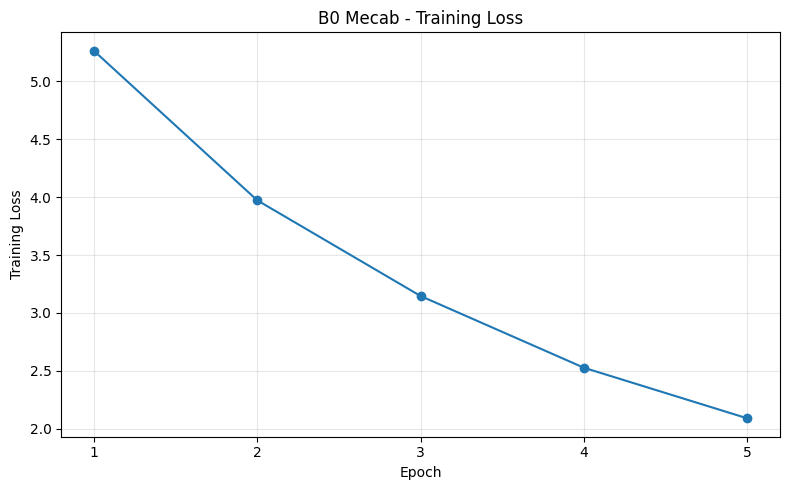

In [12]:
# ============================================================
# 7-3. Training Loss Curve
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_b0_df["epoch"],
    history_b0_df["train_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("B0 Mecab - Training Loss")

plt.xticks(
    history_b0_df["epoch"]
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

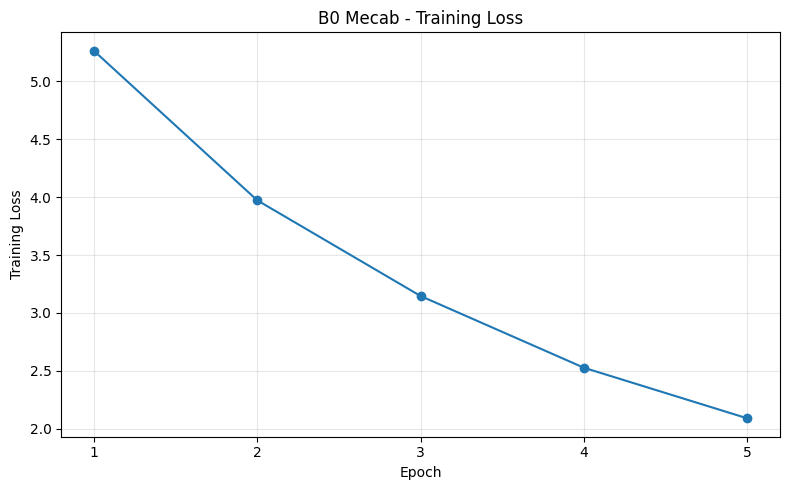

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/b0_mecab_loss_epoch1_5.png


In [13]:
B0_LOSS_PLOT_PATH = (
    OUTPUT_DIR / "b0_mecab_loss_epoch1_5.png"
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_b0_df["epoch"],
    history_b0_df["train_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("B0 Mecab - Training Loss")
plt.xticks(history_b0_df["epoch"])
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    B0_LOSS_PLOT_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", B0_LOSS_PLOT_PATH)

In [14]:
# ============================================================
# 7-4. Key Probe Evolution
# ============================================================

KEY_PROBES = [
    "P01",
    "P03",
    "P07",
    "P08",
]

key_probe_history = (
    probe_history_b0_df[
        probe_history_b0_df["id"].isin(KEY_PROBES)
    ]
    .sort_values(
        ["id", "epoch"]
    )
)

display(
    key_probe_history[
        [
            "epoch",
            "id",
            "focus",
            "korean",
            "translation",
        ]
    ]
)

,epoch,id,focus,korean,translation
0,1,P01,baseline,오바마는 대통령이다.,obama is the first president elect obama .
12,2,P01,baseline,오바마는 대통령이다.,"obama is the president of obama , who is rever..."
24,3,P01,baseline,오바마는 대통령이다.,obama is the president .
36,4,P01,baseline,오바마는 대통령이다.,"obama will be president , obama's , president ..."
48,5,P01,baseline,오바마는 대통령이다.,obama will also be on president .
2,1,P03,negation,커피는 필요 없다.,the <unk> is not a <unk> .
14,2,P03,negation,커피는 필요 없다.,coffee coffee to be the most coffee of the cof...
26,3,P03,negation,커피는 필요 없다.,the coffee is non-binding .
38,4,P03,negation,커피는 필요 없다.,the coffee is not necessarily need to be needed .
50,5,P03,negation,커피는 필요 없다.,the need for the need to be hunted .


In [15]:
# ============================================================
# 7-5. Probe Comparison — Epoch 1 vs Epoch 5
# ============================================================

probe_1 = (
    probe_history_b0_df[
        probe_history_b0_df["epoch"] == 1
    ][
        ["id", "translation"]
    ]
    .rename(
        columns={
            "translation": "epoch1_translation"
        }
    )
)

probe_5 = (
    probe_history_b0_df[
        probe_history_b0_df["epoch"] == 5
    ][
        ["id", "korean", "translation"]
    ]
    .rename(
        columns={
            "translation": "epoch5_translation"
        }
    )
)

probe_compare_1_5 = probe_5.merge(
    probe_1,
    on="id",
    how="left"
)

probe_compare_1_5 = probe_compare_1_5[
    [
        "id",
        "korean",
        "epoch1_translation",
        "epoch5_translation",
    ]
]

display(probe_compare_1_5)

,id,korean,epoch1_translation,epoch5_translation
0,P01,오바마는 대통령이다.,obama is the first president elect obama .,obama will also be on president .
1,P02,시민들은 도시 속에 산다.,the protesters are also being held in the city .,the civil town is sprawling .
2,P03,커피는 필요 없다.,the <unk> is not a <unk> .,the need for the need to be hunted .
3,P04,일곱 명의 사망자가 발생했다.,the death toll was killed in the deaths of the...,"there were more than 3 , 000 people dead ."
4,P05,구글 번역 결과를 뛰어 넘어보자!,the new cnn/orc is a <unk> <unk> .,"the result is the result of the <unk> , and yo..."
5,P06,물음표는 나라마다 쓰임이 다른가?,""" the <unk> is now <unk> .",so what's the next thing is ?
6,P07,오바마는 이제 대통령이 아니다.,obama is now president barack obama is now a p...,obama is not the president .
7,P08,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,"if you get the money , "" he said .",what you may feel if you can feel certain ?
8,P09,오바마는 대통령인가?,obama is now president barack obama ?,obama will pick up the <unk> ?
9,P10,7명의 사망자가 발생했다.,seven of the seven were killed in the seven .,seven of the seven were killed in the seven we...


In [16]:
B0_PROBE_COMPARE_PATH = (
    OUTPUT_DIR /
    "b0_mecab_probe_epoch1_vs_epoch5.csv"
)

probe_compare_1_5.to_csv(
    B0_PROBE_COMPARE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", B0_PROBE_COMPARE_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/b0_mecab_probe_epoch1_vs_epoch5.csv


## Attention Map을 그려보자.

In [17]:
# ============================================================
# 8-1. Attention Map Utility
# ============================================================

def plot_attention_map(
    model,
    sentence,
    device,
    title=None,
    save_path=None
):
    result = translate_b0(
        model=model,
        sentence=sentence,
        device=device
    )

    source_tokens = result[
        "source_tokens"
    ]

    target_tokens = result[
        "predicted_tokens"
    ]

    attention = result[
        "attention"
    ].numpy()

    # 실제 생성 token 수 / source token 수만 사용
    attention = attention[
        :len(target_tokens),
        :len(source_tokens)
    ]

    print("Korean      :", sentence)
    print("Source      :", source_tokens)
    print(
        "Translation :",
        result["translation"]
    )

    plt.figure(
        figsize=(
            max(8, len(source_tokens) * 0.7),
            max(5, len(target_tokens) * 0.55)
        )
    )

    plt.imshow(
        attention,
        aspect="auto",
        interpolation="nearest"
    )

    plt.xticks(
        range(len(source_tokens)),
        source_tokens,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(target_tokens)),
        target_tokens
    )

    plt.xlabel("Korean Source Tokens")
    plt.ylabel("Generated English Tokens")

    if title is None:
        title = "Bahdanau Attention Map"

    plt.title(title)

    plt.colorbar(
        label="Attention Weight"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=160,
            bbox_inches="tight"
        )

    plt.show()

    return result

Korean      : 오바마는 대통령이다.
Source      : ['오바마', '는', '대통령', '이', '다', '.']
Translation : obama will also be on president .


/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

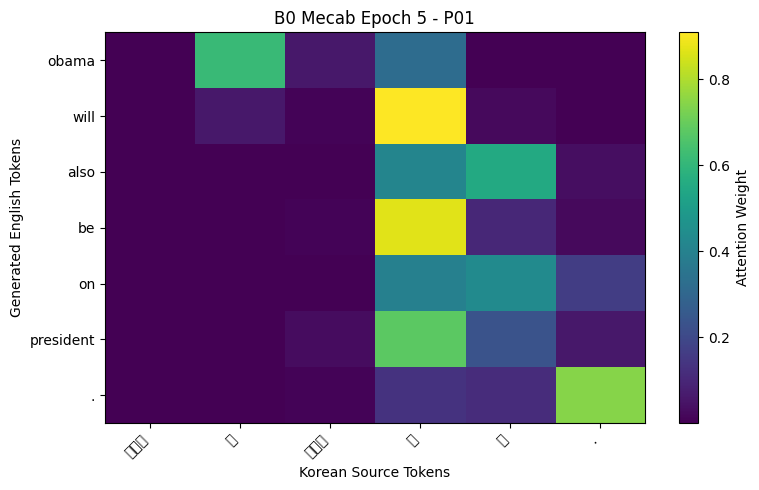

In [18]:
P01_PATH = (
    OUTPUT_DIR /
    "b0_epoch5_attention_P01.png"
)

p01_result = plot_attention_map(
    model=model_b0,
    sentence="오바마는 대통령이다.",
    device=DEVICE,
    title="B0 Mecab Epoch 5 - P01",
    save_path=P01_PATH
)

Korean      : 오바마는 이제 대통령이 아니다.
Source      : ['오바마', '는', '이제', '대통령', '이', '아니', '다', '.']
Translation : obama is not the president .


/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

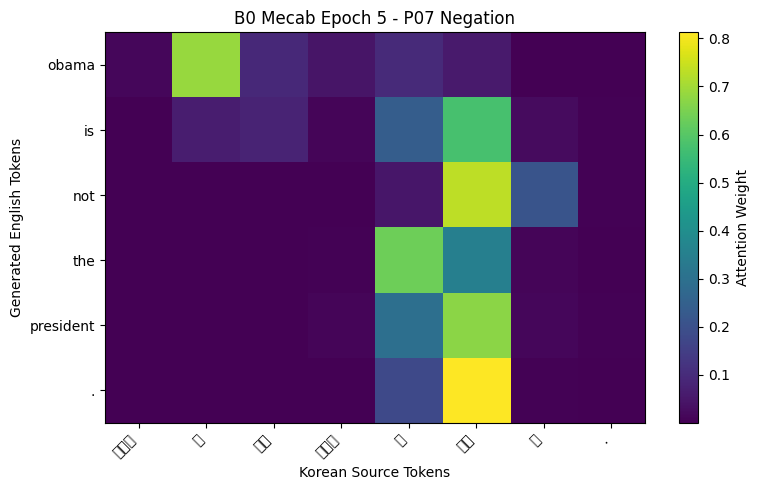

In [19]:
# P07 부정 미니멀 페어
P07_PATH = (
    OUTPUT_DIR /
    "b0_epoch5_attention_P07.png"
)

p07_result = plot_attention_map(
    model=model_b0,
    sentence="오바마는 이제 대통령이 아니다.",
    device=DEVICE,
    title="B0 Mecab Epoch 5 - P07 Negation",
    save_path=P07_PATH
)

Korean      : 닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?
Source      : ['닷', '프로덕트', '어텐션', '이렇게', '쓰', '면', '어떤', '용어', '인지', '아', '시', '나요', '?']
Translation : what you may feel if you can feel certain ?


/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45815 (\N{HANGUL SYLLABLE DAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45909 (\N{HANGUL SYLLABLE DEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 53584 (\N{HANGUL SYLLABLE TEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


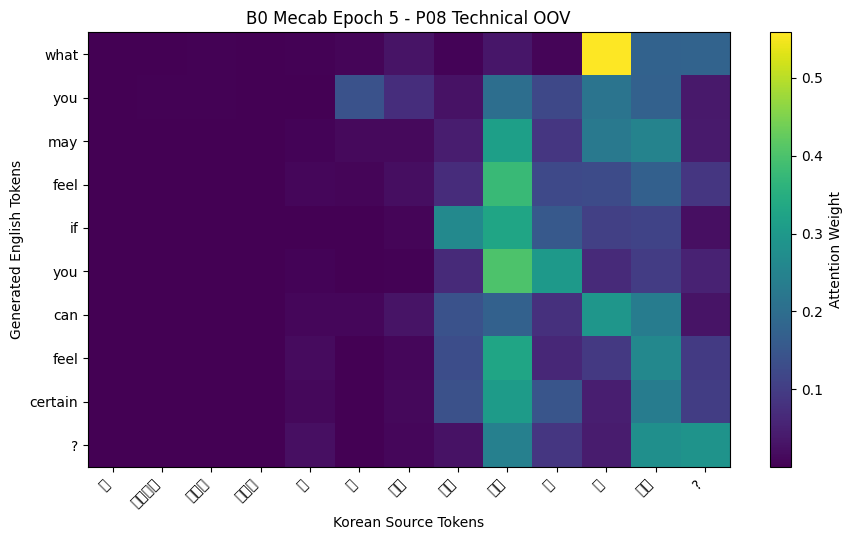

In [20]:
# P08 OOV 기술 용어
P08_PATH = (
    OUTPUT_DIR /
    "b0_epoch5_attention_P08.png"
)

p08_result = plot_attention_map(
    model=model_b0,
    sentence=(
        "닷프로덕트어텐션 이렇게 쓰면 "
        "어떤 용어인지 아시나요?"
    ),
    device=DEVICE,
    title="B0 Mecab Epoch 5 - P08 Technical OOV",
    save_path=P08_PATH
)

In [21]:
# ============================================================
# 9-1. Top Attention Alignment
# ============================================================

def attention_alignment_table(result):
    source_tokens = result[
        "source_tokens"
    ]

    target_tokens = result[
        "predicted_tokens"
    ]

    attention = result[
        "attention"
    ][
        :len(target_tokens),
        :len(source_tokens)
    ]

    rows = []

    for target_idx, target_token in enumerate(
        target_tokens
    ):
        weights = attention[target_idx]

        max_idx = int(
            weights.argmax().item()
        )

        rows.append({
            "target_token": target_token,
            "top_source_token":
                source_tokens[max_idx],
            "attention_weight":
                float(weights[max_idx]),
        })

    return pd.DataFrame(rows)

In [22]:
print("[P01]")
display(
    attention_alignment_table(
        p01_result
    )
)

[P01]


,target_token,top_source_token,attention_weight
0,obama,는,0.615765
1,will,이,0.908825
2,also,다,0.550532
3,be,이,0.867488
4,on,다,0.434200
5,president,이,0.678360
6,.,.,0.743284


In [23]:
print("[P07]")
display(
    attention_alignment_table(
        p07_result
    )
)

[P07]


,target_token,top_source_token,attention_weight
0,obama,는,0.686824
1,is,아니,0.574749
2,not,아니,0.733037
3,the,이,0.633528
4,president,아니,0.672559
5,.,아니,0.812462


In [25]:
print("[P08]")
display(
    attention_alignment_table(
        p08_result
    )
)

[P08]


,target_token,top_source_token,attention_weight
0,what,시,0.558602
1,you,시,0.214110
2,may,인지,0.316351
3,feel,인지,0.378792
4,if,인지,0.329460
5,you,인지,0.402734
6,can,시,0.294549
7,feel,인지,0.328008
8,certain,인지,0.306354
9,?,?,0.287929


## 깨달은점:
###training objective를 더 잘 맞추는 것과 일반화가 좋아지는 것은 별개의 일이다.

### Attention Map은 생각했던 것보다 더 흥미롭다

P01을 보면

obama - 오바마

president - 대통령

처럼 깔끔하게 나오지 않음.


| Target    | 가장 높은 Source |
| --------- | ------------ |
| obama     | 는            |
| will      | 이            |
| also      | 다            |
| be        | 이            |
| president | 이            |
| .         | .            |


현재 encoder가 단방향 GRU 이기 때문에


```
오바마 → 는 → 대통령 → 이 → 다
  h1      h2      h3      h4    h5
```

Decoder가 해당 단어를 생성할 때 그 위치까지 문맥이 누적된 Encoder hidden state에 높은 weight를 부여했다.

Attention Map의 열은 글자 자체가 아니라 그 위치의 contextual hidden state인 것


### 실험 기준 고정:



```
Primary tokenizer ablation

B0 — Mecab
58,805 pairs
20k vocab
5 epochs
GRU + Bahdanau
Adam 1e-3
seed 42

       VS

T1 — Unigram
58,805 pairs
20k vocab
5 epochs
GRU + Bahdanau
Adam 1e-3
seed 42
```



## B0-Mecab Epoch 5 중간 분석

B0-Mecab 모델의 training loss는 5 epoch 동안 다음과 같이 감소하였다.

| Epoch | Training Loss |
|---:|---:|
| 1 | 5.2661 |
| 2 | 3.9731 |
| 3 | 3.1458 |
| 4 | 2.5256 |
| 5 | 2.0883 |

Training loss는 지속적으로 감소하여 모델이 정상적으로 학습되고 있음을
확인하였다.

그러나 diagnostic probe에서는 training loss 감소와 번역 품질의 향상이
항상 일치하지 않았다.

예를 들어 P01은 Epoch 3에서
`obama is the president .`를 생성했으나 Epoch 5에서는
`obama will also be on president .`로 변화하였다.

이는 training corpus에 대한 objective 감소와 unseen diagnostic 입력에
대한 일반화 성능이 동일한 개념이 아님을 보여준다.

반면 부정 minimal pair P07에서는 Epoch 5에
`obama is not the president .`가 생성되어
한국어의 `아니다` 정보를 영어의 `not`으로 반영하는 능력이 관찰되었다.

### Attention 관찰

P01에서는 `obama`가 `는`, `president`가 `이` 위치에 높은 attention을
보였다. 이를 조사 자체에 대한 직접적인 단어 대응으로 해석하지 않는다.

Encoder가 단방향 GRU이므로 각 위치의 hidden state는 해당 token뿐 아니라
그 위치까지 누적된 앞선 문맥을 포함한다. 따라서 `는` 위치의 hidden state는
`오바마는`, `이` 위치의 hidden state는 `오바마는 대통령이`까지의
contextual representation으로 이해할 수 있다.

P08에서는 기술용어 자체보다 `인지`, `시`, `?`와 같은 질문 구조를 나타내는
위치에 attention이 집중되었다. 결과적으로 기술용어의 의미는 번역하지 못한
반면 일반적인 영어 질문 형태가 생성되었다.

이 결과는 Mecab 20k vocabulary에서 발생한 OOV와
Attention/Decoder 출력의 관계를 후속 SentencePiece Unigram 모델과
비교할 근거로 사용한다.

Attention weight는 인과적 feature importance로 해석하지 않고,
각 target 생성 단계에서 source position representation에 부여된
상대적인 의존 가중치로 해석한다.

Korean      : 오바마는 이제 대통령이 아니다.
Source      : ['오바마', '는', '이제', '대통령', '이', '아니', '다', '.']
Translation : obama is not the president .


/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/882021430.py:80: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

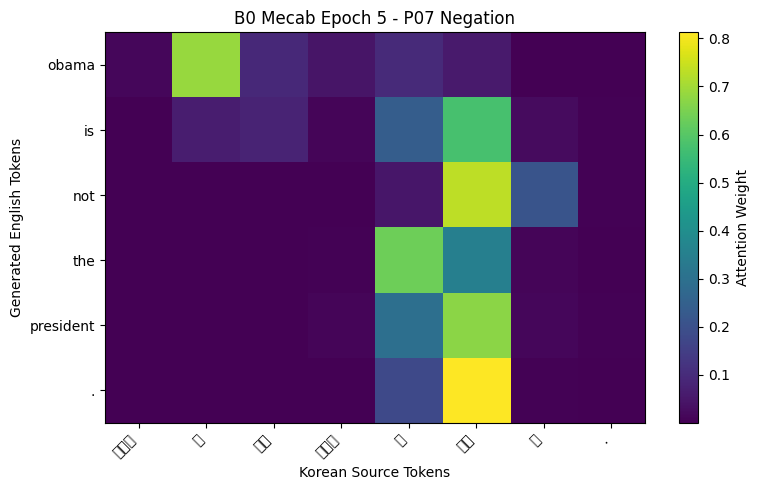

,target_token,top_source_token,attention_weight
0,obama,는,0.686824
1,is,아니,0.574749
2,not,아니,0.733037
3,the,이,0.633528
4,president,아니,0.672559
5,.,아니,0.812462


Map  : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/b0_epoch5_attention_P07.png
Table: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/b0_epoch5_attention_P07_alignment.csv


In [26]:
# ============================================================
# 8-5. P07 Attention Alignment
# ============================================================

P07_PATH = (
    OUTPUT_DIR /
    "b0_epoch5_attention_P07.png"
)

p07_result = plot_attention_map(
    model=model_b0,
    sentence="오바마는 이제 대통령이 아니다.",
    device=DEVICE,
    title="B0 Mecab Epoch 5 - P07 Negation",
    save_path=P07_PATH
)

p07_alignment_df = attention_alignment_table(
    p07_result
)

display(p07_alignment_df)

P07_ALIGNMENT_PATH = (
    OUTPUT_DIR /
    "b0_epoch5_attention_P07_alignment.csv"
)

p07_alignment_df.to_csv(
    P07_ALIGNMENT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Map  :", P07_PATH)
print("Table:", P07_ALIGNMENT_PATH)

## T1 모델 생성

In [29]:
# ============================================================
# T1-1. Build Fresh T1 Unigram Model
# Fully self-contained after runtime recovery
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ------------------------------------------------------------
# 2. IMPORTANT:
# T1 must start from completely new random weights.
#
# Do NOT load B0 weights.
# Only architecture / hyperparameters are shared.
# ------------------------------------------------------------

attention_t1 = BahdanauAttention(
    HID_DIM
)

encoder_t1 = Encoder(
    input_dim=SRC_VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    pad_id=sp.pad_id()
)

decoder_t1 = Decoder(
    output_dim=TGT_VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    attention=attention_t1,
    pad_id=TGT_PAD_ID
)

model_t1 = Seq2SeqAttention(
    encoder=encoder_t1,
    decoder=decoder_t1,
    device=DEVICE,
    src_pad_id=sp.pad_id()
).to(DEVICE)


# ------------------------------------------------------------
# 3. Same optimizer / loss as B0
# ------------------------------------------------------------

optimizer_t1 = optim.Adam(
    model_t1.parameters(),
    lr=LEARNING_RATE
)

criterion_t1 = nn.CrossEntropyLoss(
    ignore_index=TGT_PAD_ID
)


# ------------------------------------------------------------
# 4. Fresh Unigram DataLoader
# Same seed as B0
# ------------------------------------------------------------

unigram_loader = make_loader(
    unigram_src_tensor
)


# ------------------------------------------------------------
# 5. Sanity checks
# ------------------------------------------------------------

print("===================================")
print("T1-UNIGRAM MODEL READY")
print("===================================")

print("Device       :", DEVICE)
print("Source vocab :", SRC_VOCAB_SIZE)
print("Target vocab :", TGT_VOCAB_SIZE)
print("SP pad ID    :", sp.pad_id())
print("SP unk ID    :", sp.unk_id())
print("Batches      :", len(unigram_loader))

print("\nModel:")
print(model_t1)

T1-UNIGRAM MODEL READY
Device       : cuda
Source vocab : 20000
Target vocab : 20000
SP pad ID    : 0
SP unk ID    : 1
Batches      : 919

Model:
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=20000, bias=True)
  )
)


In [30]:
# ============================================================
# T1-1A. One-Batch Forward Sanity Check
# ============================================================

src_batch, tgt_in_batch, tgt_out_batch = next(
    iter(unigram_loader)
)

src_seq = (
    src_batch
    .transpose(0, 1)
    .to(DEVICE)
)

tgt_seq = (
    tgt_in_batch
    .transpose(0, 1)
    .to(DEVICE)
)

model_t1.eval()

with torch.no_grad():
    t1_test_outputs, t1_test_attentions = model_t1(
        src_seq,
        tgt_seq
    )

print("src        :", src_seq.shape)
print("target     :", tgt_seq.shape)
print("logits     :", t1_test_outputs.shape)
print("attentions :", t1_test_attentions.shape)

src        : torch.Size([40, 64])
target     : torch.Size([40, 64])
logits     : torch.Size([40, 64, 20000])
attentions : torch.Size([40, 64, 40])


In [31]:
# Reset loader after sanity check
unigram_loader = make_loader(
    unigram_src_tensor
)

print("T1 loader reset:", len(unigram_loader))

T1 loader reset: 919


In [33]:
# ============================================================
# T1-A. Inference & Probe Utilities
# ============================================================

@torch.no_grad()
def translate_t1(
    model,
    sentence,
    device,
    max_len=MAX_LEN
):
    model.eval()

    # ----------------------------------------
    # 1. Korean preprocessing
    # ----------------------------------------
    normalized = preprocess_korean(sentence)

    # ----------------------------------------
    # 2. SentencePiece Unigram
    # ----------------------------------------
    source_tokens = sp.encode(
        normalized,
        out_type=str
    )

    source_ids = sp.encode(
        normalized,
        out_type=int
    )

    # ----------------------------------------
    # 3. Padding
    # ----------------------------------------
    source_ids = pad_sequence_ids(
        source_ids,
        max_len,
        sp.pad_id()
    )

    # (seq_len, batch=1)
    src = torch.tensor(
        source_ids,
        dtype=torch.long
    ).unsqueeze(1).to(device)

    # ----------------------------------------
    # 4. Autoregressive inference
    # ----------------------------------------
    outputs, attentions = model(
        src,
        trg=None,
        max_len=max_len,
        bos_id=TGT_START_ID,
        eos_id=TGT_END_ID
    )

    predicted_ids = (
        outputs
        .argmax(dim=-1)
        .squeeze(1)
        .cpu()
        .tolist()
    )

    # ----------------------------------------
    # 5. English ID -> token
    # ----------------------------------------
    predicted_tokens = []

    for idx in predicted_ids:

        idx = int(idx)

        if idx == TGT_END_ID:
            break

        if idx in {
            TGT_PAD_ID,
            TGT_START_ID
        }:
            continue

        if 0 <= idx < len(eng_id_to_token):
            predicted_tokens.append(
                eng_id_to_token[idx]
            )

    return {
        "translation": " ".join(predicted_tokens),
        "predicted_ids": predicted_ids,
        "predicted_tokens": predicted_tokens,
        "source_tokens": source_tokens,
        "attention": attentions[:, 0].detach().cpu(),
        "normalized": normalized,
    }


def evaluate_probes_t1(
    model,
    probe_df,
    epoch,
    device
):
    rows = []

    for _, row in probe_df.iterrows():

        result = translate_t1(
            model=model,
            sentence=row["korean"],
            device=device
        )

        rows.append({
            "run": "T1-Unigram",
            "epoch": epoch,
            "id": row["id"],
            "focus": row["focus"],
            "korean": row["korean"],
            "translation": result["translation"],
        })

    return pd.DataFrame(rows)


print("translate_t1() ready")
print("evaluate_probes_t1() ready")

translate_t1() ready
evaluate_probes_t1() ready


In [34]:
# ============================================================
# T1-B. Verify Epoch 1 In-Memory State
# ============================================================

print("history_t1:")
print(history_t1)

print("\nModel device:")
print(next(model_t1.parameters()).device)

print("\nOptimizer LR:")
print(optimizer_t1.param_groups[0]["lr"])

history_t1:
[{'epoch': 1, 'train_loss': 5.347354752973322, 'seconds': 285.60498452186584}]

Model device:
cuda:0

Optimizer LR:
0.001


In [35]:
# ============================================================
# T1-C. Evaluate Probe after Epoch 1
# ============================================================

probe_epoch1_t1_df = evaluate_probes_t1(
    model=model_t1,
    probe_df=probe_df,
    epoch=1,
    device=DEVICE
)

display(
    probe_epoch1_t1_df[
        [
            "id",
            "focus",
            "korean",
            "translation"
        ]
    ]
)

,id,focus,korean,translation
0,P01,baseline,오바마는 대통령이다.,obama is obama to win the obama campaign .
1,P02,baseline,시민들은 도시 속에 산다.,the <unk> is a <unk> .
2,P03,negation,커피는 필요 없다.,the <unk> is a <unk> .
3,P04,number_word,일곱 명의 사망자가 발생했다.,the bombing of the people were killed in the a...
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자!,the new york philharmonic orchestra is expecte...
5,P06,question_mark,물음표는 나라마다 쓰임이 다른가?,why is a <unk> <unk> <unk> ?
6,P07,negation_contrast,오바마는 이제 대통령이 아니다.,obama is also a democrat for president barack ...
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,"why is the first time in the past <unk> , "" <u..."
8,P09,statement_question,오바마는 대통령인가?,"obama is a former president obama , who is the..."
9,P10,digit_contrast,7명의 사망자가 발생했다.,seven of the seven were killed in the seven se...


In [36]:
# ============================================================
# T1-D. Save Epoch 1 Immediately
# ============================================================

T1_MODEL_DIR = MODEL_DIR / "t1_unigram"
T1_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

T1_LATEST_PATH = (
    T1_MODEL_DIR /
    "t1_unigram_latest.pt"
)

T1_EPOCH5_PATH = (
    T1_MODEL_DIR /
    "t1_unigram_epoch5.pt"
)

T1_HISTORY_PATH = (
    OUTPUT_DIR /
    "t1_unigram_training_history.csv"
)

T1_PROBE_PATH = (
    OUTPUT_DIR /
    "t1_unigram_probe_history.csv"
)


# ----------------------------------------
# History
# ----------------------------------------

pd.DataFrame(
    history_t1
).to_csv(
    T1_HISTORY_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------
# Probe
# ----------------------------------------

probe_epoch1_t1_df.to_csv(
    T1_PROBE_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ----------------------------------------
# Checkpoint
# ----------------------------------------

torch.save(
    {
        "epoch": 1,

        "model_state_dict":
            model_t1.state_dict(),

        "optimizer_state_dict":
            optimizer_t1.state_dict(),

        "history":
            history_t1,

        "config": {
            "src_tokenizer":
                "sentencepiece_unigram",

            "src_vocab":
                SRC_VOCAB_SIZE,

            "tgt_vocab":
                TGT_VOCAB_SIZE,

            "embedding_dim":
                EMB_DIM,

            "hidden_dim":
                HID_DIM,

            "max_len":
                MAX_LEN,

            "batch_size":
                BATCH_SIZE,

            "learning_rate":
                LEARNING_RATE,

            "seed":
                SEED,
        }
    },
    T1_LATEST_PATH
)

print("T1 Epoch 1 saved.")
print("History   :", T1_HISTORY_PATH)
print("Probe     :", T1_PROBE_PATH)
print("Checkpoint:", T1_LATEST_PATH)

T1 Epoch 1 saved.
History   : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/t1_unigram_training_history.csv
Probe     : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/t1_unigram_probe_history.csv
Checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/t1_unigram/t1_unigram_latest.pt


In [37]:
# ============================================================
# T1-E. T1 Training Step
# ============================================================

def train_step_t1(
    model,
    data_loader,
    optimizer,
    criterion,
    epoch,
    device
):
    model.train()

    epoch_loss = 0.0

    progress_bar = tqdm(
        data_loader,
        desc=f"T1-Unigram Epoch {epoch + 1}",
        leave=True
    )

    for src, trg_input, trg_label in progress_bar:

        src = src.to(device)
        trg_input = trg_input.to(device)
        trg_label = trg_label.to(device)

        # (batch, seq_len)
        # →
        # (seq_len, batch)
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        outputs, _ = model(
            src,
            trg_input
        )

        outputs = outputs.reshape(
            -1,
            outputs.shape[-1]
        )

        trg_label = trg_label.reshape(-1)

        loss = criterion(
            outputs,
            trg_label
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1
        )

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        epoch_loss
        / len(data_loader)
    )

In [38]:
# ============================================================
# T1-F. Continue Training — Epoch 2 to 5
# ============================================================

probe_history_t1 = [
    probe_epoch1_t1_df.copy()
]


for epoch in range(1, 5):
    # epoch=1 → Epoch 2
    # epoch=4 → Epoch 5

    start_time = time.time()

    train_loss = train_step_t1(
        model=model_t1,
        data_loader=unigram_loader,
        optimizer=optimizer_t1,
        criterion=criterion_t1,
        epoch=epoch,
        device=DEVICE
    )

    elapsed = (
        time.time()
        - start_time
    )

    # ----------------------------------------
    # Loss history
    # ----------------------------------------

    history_t1.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "seconds": elapsed,
    })

    print(
        f"\nT1 Epoch {epoch + 1} | "
        f"Loss: {train_loss:.4f} | "
        f"Time: {elapsed / 60:.2f} min"
    )


    # ----------------------------------------
    # Probe
    # ----------------------------------------

    probe_epoch_df = (
        evaluate_probes_t1(
            model=model_t1,
            probe_df=probe_df,
            epoch=epoch + 1,
            device=DEVICE
        )
    )

    probe_history_t1.append(
        probe_epoch_df
    )


    # ----------------------------------------
    # History CSV
    # ----------------------------------------

    pd.DataFrame(
        history_t1
    ).to_csv(
        T1_HISTORY_PATH,
        index=False,
        encoding="utf-8-sig"
    )


    # ----------------------------------------
    # Probe CSV
    # ----------------------------------------

    pd.concat(
        probe_history_t1,
        ignore_index=True
    ).to_csv(
        T1_PROBE_PATH,
        index=False,
        encoding="utf-8-sig"
    )


    # ----------------------------------------
    # Latest checkpoint
    # ----------------------------------------

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model_t1.state_dict(),

            "optimizer_state_dict":
                optimizer_t1.state_dict(),

            "history":
                history_t1,

            "config": {
                "src_tokenizer":
                    "sentencepiece_unigram",

                "src_vocab":
                    SRC_VOCAB_SIZE,

                "tgt_vocab":
                    TGT_VOCAB_SIZE,

                "embedding_dim":
                    EMB_DIM,

                "hidden_dim":
                    HID_DIM,

                "max_len":
                    MAX_LEN,

                "batch_size":
                    BATCH_SIZE,

                "learning_rate":
                    LEARNING_RATE,

                "seed":
                    SEED,
            }
        },
        T1_LATEST_PATH
    )

    print(
        f"T1 Epoch {epoch + 1} saved."
    )


# --------------------------------------------
# Epoch 5 dedicated checkpoint
# --------------------------------------------

torch.save(
    {
        "epoch": 5,

        "model_state_dict":
            model_t1.state_dict(),

        "optimizer_state_dict":
            optimizer_t1.state_dict(),

        "history":
            history_t1,
    },
    T1_EPOCH5_PATH
)

print("\nT1-Unigram Epoch 5 completed.")
print("Final checkpoint:", T1_EPOCH5_PATH)

T1-Unigram Epoch 2:   0%|          | 0/919 [00:00<?, ?it/s]


T1 Epoch 2 | Loss: 4.1202 | Time: 4.75 min
T1 Epoch 2 saved.


T1-Unigram Epoch 3:   0%|          | 0/919 [00:00<?, ?it/s]


T1 Epoch 3 | Loss: 3.2766 | Time: 4.87 min
T1 Epoch 3 saved.


T1-Unigram Epoch 4:   0%|          | 0/919 [00:00<?, ?it/s]


T1 Epoch 4 | Loss: 2.6229 | Time: 4.83 min
T1 Epoch 4 saved.


T1-Unigram Epoch 5:   0%|          | 0/919 [00:00<?, ?it/s]


T1 Epoch 5 | Loss: 2.1574 | Time: 4.81 min
T1 Epoch 5 saved.

T1-Unigram Epoch 5 completed.
Final checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/t1_unigram/t1_unigram_epoch5.pt


In [39]:
# ============================================================
# 11-1. B0 vs T1 Training Loss Comparison
# ============================================================

b0_history_df = pd.read_csv(
    B0_HISTORY_PATH
)

t1_history_df = pd.read_csv(
    T1_HISTORY_PATH
)

loss_compare_df = (
    b0_history_df[
        ["epoch", "train_loss"]
    ]
    .rename(
        columns={
            "train_loss": "B0_Mecab"
        }
    )
    .merge(
        t1_history_df[
            ["epoch", "train_loss"]
        ].rename(
            columns={
                "train_loss": "T1_Unigram"
            }
        ),
        on="epoch"
    )
)

loss_compare_df["T1_minus_B0"] = (
    loss_compare_df["T1_Unigram"]
    - loss_compare_df["B0_Mecab"]
)

display(
    loss_compare_df.round(4)
)

,epoch,B0_Mecab,T1_Unigram,T1_minus_B0
0,1,5.2661,5.3474,0.0813
1,2,3.9731,4.1202,0.1471
2,3,3.1458,3.2766,0.1308
3,4,2.5256,2.6229,0.0973
4,5,2.0883,2.1574,0.0690


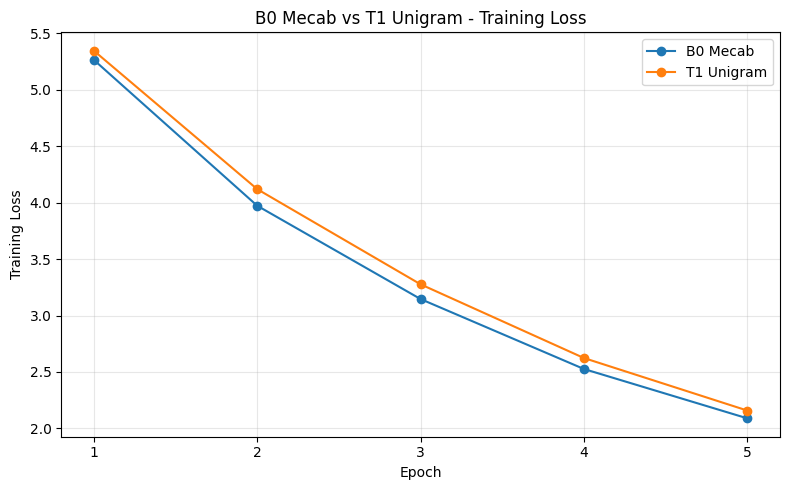

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd05_seq2seq/b0_vs_t1_training_loss_epoch1_5.png


In [41]:
# ============================================================
# 11-2. B0 vs T1 Loss Curve
# ============================================================

import matplotlib.pyplot as plt

LOSS_COMPARE_PATH = (
    OUTPUT_DIR /
    "b0_vs_t1_training_loss_epoch1_5.png"
)

plt.figure(figsize=(8, 5))

plt.plot(
    loss_compare_df["epoch"],
    loss_compare_df["B0_Mecab"],
    marker="o",
    label="B0 Mecab"
)

plt.plot(
    loss_compare_df["epoch"],
    loss_compare_df["T1_Unigram"],
    marker="o",
    label="T1 Unigram"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("B0 Mecab vs T1 Unigram - Training Loss")
plt.xticks(loss_compare_df["epoch"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    LOSS_COMPARE_PATH,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOSS_COMPARE_PATH)

### B0-Mecab vs T1-Unigram 학습 안정성

동일한 58,805개의 Korean-English pair와 동일한
GRU + Bahdanau Attention 구조를 사용하고,
source tokenizer만 변경하여 비교하였다.

B0-Mecab과 T1-Unigram 모두 5 epoch 동안 training loss가
안정적으로 감소하였다.

- B0-Mecab: 5.2661 → 2.0883
- T1-Unigram: 5.3474 → 2.1574

5 epoch 동안 B0-Mecab의 training loss가 T1-Unigram보다
소폭 낮았으나 두 모델의 감소 추세는 유사하였다.

따라서 SentencePiece Unigram의 장점을 training loss 자체의
감소 속도로 판단하기보다, OOV 발생 여부와 diagnostic probe에서의
의미 보존 및 attention pattern 차이를 중심으로 비교한다.

In [42]:
# ============================================================
# 11-3. B0 vs T1 — Epoch 5 Diagnostic Probes
# ============================================================

b0_probe_df = pd.read_csv(
    B0_PROBE_HISTORY_PATH
)

t1_probe_df = pd.read_csv(
    T1_PROBE_PATH
)


b0_epoch5 = (
    b0_probe_df[
        b0_probe_df["epoch"] == 5
    ][
        [
            "id",
            "focus",
            "korean",
            "translation"
        ]
    ]
    .rename(
        columns={
            "translation":
                "B0_Mecab_translation"
        }
    )
)


t1_epoch5 = (
    t1_probe_df[
        t1_probe_df["epoch"] == 5
    ][
        [
            "id",
            "translation"
        ]
    ]
    .rename(
        columns={
            "translation":
                "T1_Unigram_translation"
        }
    )
)


probe_compare_df = (
    b0_epoch5.merge(
        t1_epoch5,
        on="id",
        how="inner"
    )
)

display(probe_compare_df)

,id,focus,korean,B0_Mecab_translation,T1_Unigram_translation
0,P01,baseline,오바마는 대통령이다.,obama will also be on president .,obama will also be held in the race .
1,P02,baseline,시민들은 도시 속에 산다.,the civil town is sprawling .,the urban mountain is a <unk> .
2,P03,negation,커피는 필요 없다.,the need for the need to be hunted .,there is no word on the issue .
3,P04,number_word,일곱 명의 사망자가 발생했다.,"there were more than 3 , 000 people dead .",several people were killed in the attack .
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자!,"the result is the result of the <unk> , and yo...",google earth in the second half of the debate ...
5,P06,question_mark,물음표는 나라마다 쓰임이 다른가?,so what's the next thing is ?,do you do that ?
6,P07,negation_contrast,오바마는 이제 대통령이 아니다.,obama is not the president .,obama is the president of the illinois democra...
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,what you may feel if you can feel certain ?,what would you have a <unk> ?
8,P09,statement_question,오바마는 대통령인가?,obama will pick up the <unk> ?,a presidential race is a big ?
9,P10,digit_contrast,7명의 사망자가 발생했다.,seven of the seven were killed in the seven we...,seven people were killed in the shootings .


| Probe            | B0 Mecab                         | T1 Unigram                         | 해석                                                                    |
| ---------------- | -------------------------------- | ---------------------------------- | --------------------------------------------------------------------- |
| **P01 기본**       | `obama ... president`            | `obama ... race`                   | 둘 다 Obama는 보존했지만 의미 정확도는 B0가 상대적으로 낫다.                                |
| **P03 부정**       | 부정 의미 소실                         | `there is no ...`                  | T1은 적어도 부정 구조 `no`를 보존했다.                                             |
| **P04 한글 수사**    | 죽음은 표현하나 `3,000`으로 왜곡            | `several people were killed`       | T1이 사건 의미는 더 자연스럽지만 `일곱`이라는 정확한 수량은 잃었다.                              |
| **P05 구글**       | `Google` 의미 소실                   | `google earth ...`                 | T1은 `구글 → google` lexical identity를 살렸다. 그러나 전체 번역은 틀렸다.              |
| **P06 의문문**      | 질문문                              | 질문문                                | 둘 다 `?`와 의문문 형태를 보존.                                                  |
| **P07 부정 최소대조**  | **`obama is not the president`** | 부정 완전 소실                           | **B0의 명확한 우위 사례. 형태소 `아니`가 의미 차이 학습에 도움을 준 것으로 볼 여지가 있다.**            |
| **P08 붙인 기술용어**  | 일반 질문으로 붕괴                       | 일반 질문 + `<unk>`                    | T1이 source OOV를 없앴지만 의미 번역에는 성공하지 못했다.                                |
| **P09 대통령인가?**   | Obama + 질문                       | presidential race + 질문             | 둘 다 질문 구조는 알지만 의미 정확도 낮음.                                             |
| **P10 숫자 7**     | `seven` 반복                       | **`seven people were killed ...`** | **T1이 매우 명확하게 우세한 사례.**                                               |
| **P11 띄어쓴 기술용어** | P08과 동일 출력                       | **P08과 다른 출력**                     | Mecab은 두 입력 차이를 사실상 소거했지만 Unigram은 차이를 보존했다. 다만 번역 품질 개선으로 이어지지는 않았다. |
| **P12 Google**   | Google 의미 소실                     | Google 의미 소실                       | Latin script 보존 자체가 번역 성공을 보장하지 않음.                                   |


In [44]:
# ============================================================
# 11-5. Minimal-Pair Comparison
# ============================================================

PAIR_IDS = [
    "P01", "P07",   # statement / negation
    "P04", "P10",   # word number / digit
    "P05", "P12",   # Korean / Latin
    "P08", "P11",   # no-space / space
]

minimal_pair_df = (
    probe_compare_df[
        probe_compare_df["id"].isin(
            PAIR_IDS
        )
    ]
)

display(
    minimal_pair_df[
        [
            "id",
            "focus",
            "korean",
            "B0_Mecab_translation",
            "T1_Unigram_translation"
        ]
    ]
)

,id,focus,korean,B0_Mecab_translation,T1_Unigram_translation
0,P01,baseline,오바마는 대통령이다.,obama will also be on president .,obama will also be held in the race .
3,P04,number_word,일곱 명의 사망자가 발생했다.,"there were more than 3 , 000 people dead .",several people were killed in the attack .
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자!,"the result is the result of the <unk> , and yo...",google earth in the second half of the debate ...
6,P07,negation_contrast,오바마는 이제 대통령이 아니다.,obama is not the president .,obama is the president of the illinois democra...
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,what you may feel if you can feel certain ?,what would you have a <unk> ?
9,P10,digit_contrast,7명의 사망자가 발생했다.,seven of the seven were killed in the seven we...,seven people were killed in the shootings .
10,P11,spacing_contrast,닷 프로덕트 어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,what you may feel if you can feel certain ?,what kind of doing the <unk> <unk> is a <unk> ?
11,P12,latin_contrast,Google 번역 결과를 뛰어 넘어보자!,"a result of the situation , which is a critica...",""" there is no word on the bottom ."


Korean      : 오바마는 대통령이다.
Source      : ['▁오바마는', '▁대통령이', '다', '▁.']
Translation : obama will also be held in the race .


/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

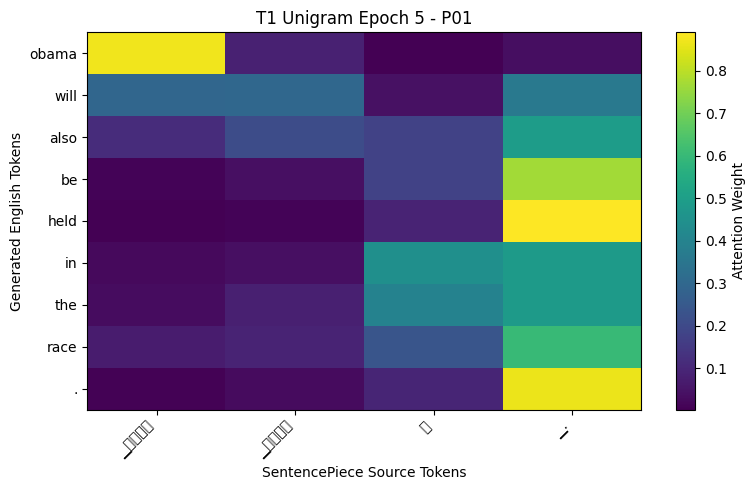

Korean      : 오바마는 이제 대통령이 아니다.
Source      : ['▁오바마는', '▁이제', '▁대통령이', '▁아니다', '▁.']
Translation : obama is the president of the illinois democrat's president , the president .


/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

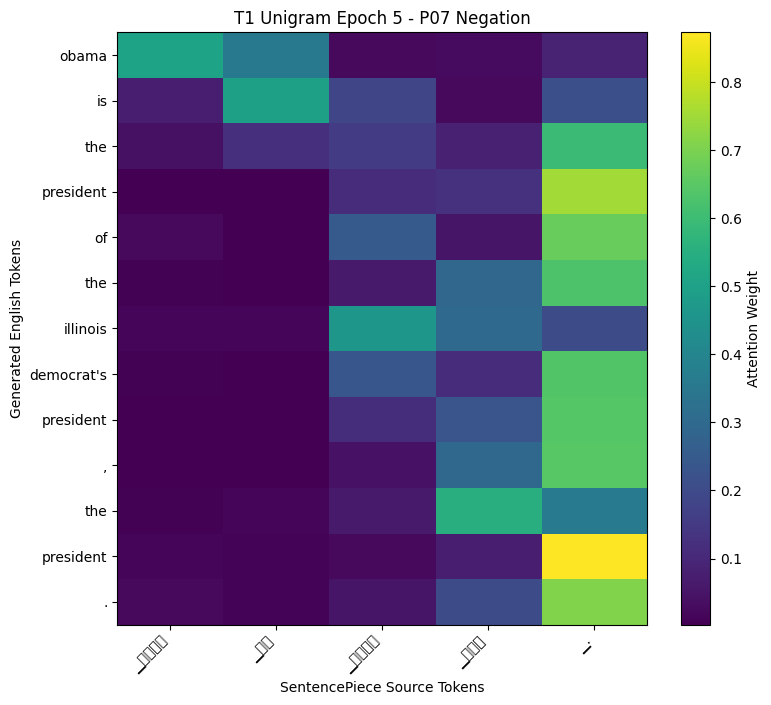

Korean      : 닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?
Source      : ['▁닷', '프', '로', '덕', '트', '어', '텐', '션', '▁이렇게', '▁쓰', '면', '▁어떤', '▁용', '어', '인지', '▁아', '시', '나', '요', '▁', '?']
Translation : what would you have a <unk> ?


/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 45815 (\N{HANGUL SYLLABLE DAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 45909 (\N{HANGUL SYLLABLE DEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1475/877939461.py:92: UserWarning: Glyph 53584 (\N{HANGUL SYLLABLE TEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


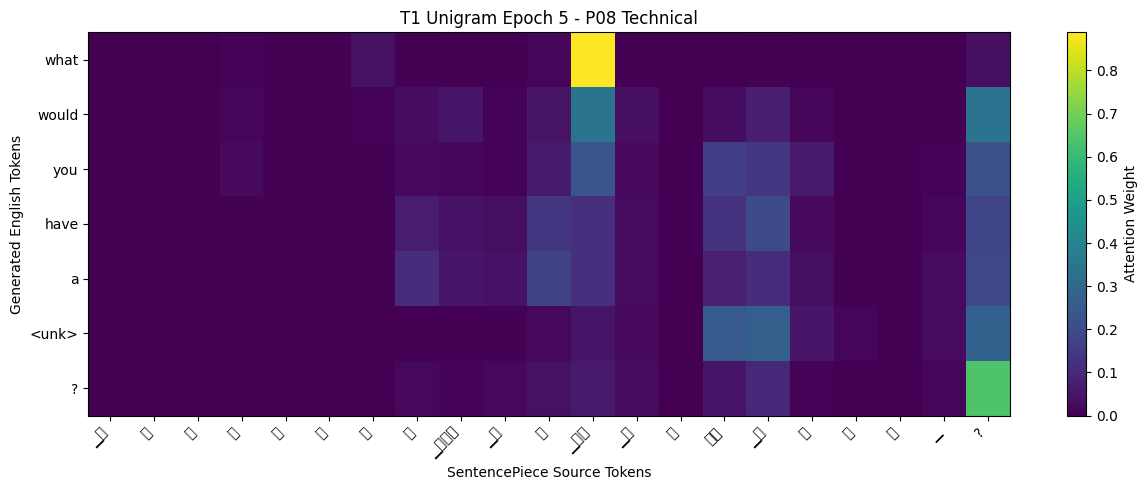

In [46]:
# ============================================================
# 12-2. T1 Epoch 5 — P01 / P07 / P08 Attention
# ============================================================

T1_P01_PATH = (
    OUTPUT_DIR /
    "t1_epoch5_attention_P01.png"
)

T1_P07_PATH = (
    OUTPUT_DIR /
    "t1_epoch5_attention_P07.png"
)

T1_P08_PATH = (
    OUTPUT_DIR /
    "t1_epoch5_attention_P08.png"
)


t1_p01_result = plot_attention_map_t1(
    model=model_t1,
    sentence="오바마는 대통령이다.",
    device=DEVICE,
    title="T1 Unigram Epoch 5 - P01",
    save_path=T1_P01_PATH
)


t1_p07_result = plot_attention_map_t1(
    model=model_t1,
    sentence="오바마는 이제 대통령이 아니다.",
    device=DEVICE,
    title="T1 Unigram Epoch 5 - P07 Negation",
    save_path=T1_P07_PATH
)


t1_p08_result = plot_attention_map_t1(
    model=model_t1,
    sentence=(
        "닷프로덕트어텐션 이렇게 쓰면 "
        "어떤 용어인지 아시나요?"
    ),
    device=DEVICE,
    title="T1 Unigram Epoch 5 - P08 Technical",
    save_path=T1_P08_PATH
)

## Tokenizer Ablation 결과 고정

동일한 58,805개 병렬 문장과 동일한 GRU + Bahdanau Attention 구조에서
한국어 source tokenizer만 변경하여 5 epoch 학습했다.

- B0-Mecab: 5.2661 → 2.0883
- T1-Unigram: 5.3474 → 2.1574

두 모델 모두 안정적으로 training loss가 감소했다.
B0-Mecab이 매 epoch 소폭 낮은 training loss를 보였으나,
validation set을 별도로 두지 않은 프로젝트 조건이므로
training loss만으로 tokenizer의 우열을 판단하지 않는다.

Diagnostic probe에서는 tokenizer별 trade-off가 확인됐다.

- Mecab은 P07 부정 표현에서 의미를 잘 보존
- Unigram은 P10 숫자 표현에서 더 자연스러운 결과를 생성함
- P08/P11에서 Mecab은 띄어쓰기 차이를 사실상 소거했으나,
  Unigram은 서로 다른 representation과 출력을 생성함
- 그러나 Unigram의 source OOV 감소가 기술용어의 정확한 번역을
  자동으로 보장하지는 않음

따라서 본 실험은 어느 tokenizer가 절대적으로 우수하다는 결론보다,
형태소 기반 tokenization과 subword tokenization의 representation
trade-off를 관찰한 ablation으로 해석한다.

## 같은 Mecab 모델을 더 오래 학습시키면 번역 품질은 어떻게 변하는가?

```
Experiment A
Tokenizer Ablation
B0-5 vs T1-5

[이제 진행!]
Experiment B
Training Progression
B0-5 → B0-10
```



In [58]:
# ============================================================
# 14-1. B0 Extended Training Paths
# ============================================================

B0_EXT_HISTORY_PATH = (
    OUTPUT_DIR /
    "b0_mecab_training_history_epoch1_10.csv"
)

B0_EXT_PROBE_PATH = (
    OUTPUT_DIR /
    "b0_mecab_probe_history_epoch1_10.csv"
)

B0_EPOCH10_PATH = (
    B0_MODEL_DIR /
    "b0_mecab_epoch10.pt"
)

print("B0 current completed epoch:", completed_epoch)
print("Epoch 5 checkpoint:", B0_EPOCH5_PATH)
print("Epoch 10 target    :", B0_EPOCH10_PATH)

B0 current completed epoch: 5
Epoch 5 checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/b0_mecab/b0_mecab_epoch5.pt
Epoch 10 target    : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/b0_mecab/b0_mecab_epoch10.pt


In [59]:
# ============================================================
# 14-2. Restore B0 Probe History
# ============================================================

probe_history_b0_df = pd.read_csv(
    B0_PROBE_HISTORY_PATH
)

print(
    "Probe epochs:",
    sorted(
        probe_history_b0_df["epoch"]
        .unique()
        .tolist()
    )
)

print(
    "Rows:",
    len(probe_history_b0_df)
)

Probe epochs: [1, 2, 3, 4, 5]
Rows: 60


In [60]:
# ============================================================
# 15. B0 Extended Training — Epoch 6 to 10
# ============================================================

import time


for epoch_number in range(6, 11):

    start_time = time.time()

    # train_step()의 epoch 인자는 0-based 표시용이므로
    # Epoch 6 → epoch=5
    train_loss = train_step(
        model=model_b0,
        data_loader=mecab_loader,
        optimizer=optimizer_b0,
        criterion=criterion,
        epoch=epoch_number - 1,
        device=DEVICE
    )

    elapsed = (
        time.time()
        - start_time
    )

    # ----------------------------------------
    # 1. Loss
    # ----------------------------------------

    history_b0.append({
        "epoch": epoch_number,
        "train_loss": train_loss,
        "seconds": elapsed,
    })

    print(
        f"\nB0 Epoch {epoch_number} | "
        f"Loss: {train_loss:.4f} | "
        f"Time: {elapsed / 60:.2f} min"
    )


    # ----------------------------------------
    # 2. Diagnostic probes
    # ----------------------------------------

    probe_epoch_df = evaluate_probes(
        model=model_b0,
        probe_df=probe_df,
        epoch=epoch_number,
        run_name="B0-Mecab",
        device=DEVICE
    )

    probe_history_b0_df = pd.concat(
        [
            probe_history_b0_df,
            probe_epoch_df
        ],
        ignore_index=True
    )


    # ----------------------------------------
    # 3. History save
    # ----------------------------------------

    pd.DataFrame(
        history_b0
    ).to_csv(
        B0_EXT_HISTORY_PATH,
        index=False,
        encoding="utf-8-sig"
    )


    # ----------------------------------------
    # 4. Probe save
    # ----------------------------------------

    probe_history_b0_df.to_csv(
        B0_EXT_PROBE_PATH,
        index=False,
        encoding="utf-8-sig"
    )


    # ----------------------------------------
    # 5. Latest checkpoint
    # ----------------------------------------

    torch.save(
        {
            "epoch": epoch_number,

            "model_state_dict":
                model_b0.state_dict(),

            "optimizer_state_dict":
                optimizer_b0.state_dict(),

            "history":
                history_b0,

            "config": {
                "src_tokenizer": "mecab",
                "src_vocab": SRC_VOCAB_SIZE,
                "tgt_vocab": TGT_VOCAB_SIZE,
                "embedding_dim": EMB_DIM,
                "hidden_dim": HID_DIM,
                "max_len": MAX_LEN,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "seed": SEED,
            }
        },
        B0_LATEST_PATH
    )

    print(
        f"B0 Epoch {epoch_number} saved."
    )


# --------------------------------------------
# Dedicated Epoch 10 checkpoint
# --------------------------------------------

torch.save(
    {
        "epoch": 10,
        "model_state_dict":
            model_b0.state_dict(),
        "optimizer_state_dict":
            optimizer_b0.state_dict(),
        "history":
            history_b0,
    },
    B0_EPOCH10_PATH
)

print("\nB0 Epoch 10 completed.")
print("Final checkpoint:", B0_EPOCH10_PATH)

B0 Epoch 6:   0%|          | 0/919 [00:00<?, ?it/s]


B0 Epoch 6 | Loss: 1.7580 | Time: 4.88 min
B0 Epoch 6 saved.


B0 Epoch 7:   0%|          | 0/919 [00:00<?, ?it/s]


B0 Epoch 7 | Loss: 1.5021 | Time: 4.87 min
B0 Epoch 7 saved.


B0 Epoch 8:   0%|          | 0/919 [00:00<?, ?it/s]


B0 Epoch 8 | Loss: 1.2969 | Time: 4.87 min
B0 Epoch 8 saved.


B0 Epoch 9:   0%|          | 0/919 [00:00<?, ?it/s]


B0 Epoch 9 | Loss: 1.1309 | Time: 4.88 min
B0 Epoch 9 saved.


B0 Epoch 10:   0%|          | 0/919 [00:00<?, ?it/s]


B0 Epoch 10 | Loss: 0.9981 | Time: 4.87 min
B0 Epoch 10 saved.

B0 Epoch 10 completed.
Final checkpoint: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/b0_mecab/b0_mecab_epoch10.pt


In [61]:
# ============================================================
# 16-1. B0 Epoch 1~10 Loss
# ============================================================

b0_history_1_10_df = pd.DataFrame(
    history_b0
)

display(
    b0_history_1_10_df[
        [
            "epoch",
            "train_loss"
        ]
    ].round(4)
)

,epoch,train_loss
0,1,5.2661
1,2,3.9731
2,3,3.1458
3,4,2.5256
4,5,2.0883
5,6,1.7580
6,7,1.5021
7,8,1.2969
8,9,1.1309
9,10,0.9981


### B0-Mecab 10 Epoch 학습

Mecab 기반 모델을 10 epoch까지 추가 학습했다.

Training loss는 1 epoch의 5.2661에서 10 epoch의 0.9981까지
약 81% 감소하였으며, 전 epoch에서 일관된 감소 추세를 보였다.

이는 GRU + Bahdanau Attention Seq2Seq 모델이 학습 데이터에 대해
안정적으로 최적화되고 있음을 보여준다.

다만 training loss 감소가 unseen diagnostic 문장의 번역 품질 향상을
직접 보장하지는 않으므로, Epoch 3, 5, 10의 동일 probe 결과를 비교하여
optimization과 diagnostic generalization의 관계를 추가 관찰한다.

In [63]:
# ============================================================
# 16-3. B0 Probe Pivot — Epoch 3 / 5 / 10
# ============================================================

probe_pivot = (
    probe_3_5_10
    .pivot(
        index=[
            "id",
            "focus",
            "korean"
        ],
        columns="epoch",
        values="translation"
    )
    .reset_index()
    .rename(
        columns={
            3: "epoch3",
            5: "epoch5",
            10: "epoch10"
        }
    )
)

display(probe_pivot)

epoch,id,focus,korean,epoch3,epoch5,epoch10
0,P01,baseline,오바마는 대통령이다.,obama is the president .,obama will also be on president .,obama will be president when he goes to the ob...
1,P02,baseline,시민들은 도시 속에 산다.,citizens were cities in cities cities in citie...,the civil town is sprawling .,of civil rights :
2,P03,negation,커피는 필요 없다.,the coffee is non-binding .,the need for the need to be hunted .,the chance for coffee is even lose .
3,P04,number_word,일곱 명의 사망자가 발생했다.,the death toll was killed .,"there were more than 3 , 000 people dead .",there were no death toll on casualties .
4,P05,proper_noun_exclamation,구글 번역 결과를 뛰어 넘어보자!,"the result of the google project's google , th...","the result is the result of the <unk> , and yo...",the result is the result of the global search ...
5,P06,question_mark,물음표는 나라마다 쓰임이 다른가?,""" i think that this is a <unk> , "" <unk> said .",so what's the next thing is ?,so it has become a very much ?
6,P07,negation_contrast,오바마는 이제 대통령이 아니다.,obama is now president obama .,obama is not the president .,obama may not be elected president .
7,P08,technical_oov,닷프로덕트어텐션 이렇게 쓰면 어떤 용어인지 아시나요?,what you may have a <unk> ?,what you may feel if you can feel certain ?,"what if you have any other , you may be any ki..."
8,P09,statement_question,오바마는 대통령인가?,obama will be president obama's ?,obama will pick up the <unk> ?,""" obama will head the president ?"
9,P10,digit_contrast,7명의 사망자가 발생했다.,seven people were killed .,seven of the seven were killed in the seven we...,seven deaths were killed in the attack .


Epoch가 증가함에 따라 training loss는 지속적으로 감소했으나, exact-match unseen diagnostic probe의 번역 품질은 단조롭게 향상되지 않았다.

따라서 training objective의 최적화에 맞춰 번역 품질도 같이 좋아진다고는 볼 수 없다...

### Epoch 증가와 Diagnostic Generalization

B0-Mecab 모델을 총 10 epoch까지 학습한 결과,
training loss는 5.2661에서 0.9981까지 지속적으로 감소하였다.

그러나 exact-match unseen diagnostic probe의 번역 품질은
training loss와 동일한 방향으로 개선되지 않았다.

예를 들어:

- P01 `오바마는 대통령이다.`
  - Epoch 3: `obama is the president .`
  - Epoch 10: `obama will be president when ...`

- P07 `오바마는 이제 대통령이 아니다.`
  - Epoch 5: `obama is not the president .`
  - Epoch 10: `obama may not be elected president .`

- P10 `7명의 사망자가 발생했다.`
  - Epoch 3: `seven people were killed .`
  - Epoch 10: `seven deaths were killed in the attack .`

따라서 학습 데이터에 대한 objective 감소와
새로운 입력에 대한 번역 품질 향상이 반드시 일치하지 않는 것으로.. 확인

In [64]:
# ============================================================
# 17-1. Load Final B0-Mecab Epoch 10 Checkpoint
# ============================================================

assert B0_EPOCH10_PATH.exists(), (
    f"Epoch 10 checkpoint not found: {B0_EPOCH10_PATH}"
)

b0_epoch10_checkpoint = torch.load(
    B0_EPOCH10_PATH,
    map_location=DEVICE,
    weights_only=False
)

model_b0.load_state_dict(
    b0_epoch10_checkpoint["model_state_dict"]
)

model_b0.eval()

print("===================================")
print("FINAL B0-MECAB MODEL")
print("===================================")
print("Checkpoint :", B0_EPOCH10_PATH)
print("Epoch      :", b0_epoch10_checkpoint["epoch"])
print("Device     :", DEVICE)


FINAL B0-MECAB MODEL
Checkpoint : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/b0_mecab/b0_mecab_epoch10.pt
Epoch      : 10
Device     : cuda


In [65]:
# ============================================================
# 17-2. LMS Fixed Translation Sentences
# B0-Mecab Epoch 10
# ============================================================

FIXED_IDS = ["P01", "P02", "P03", "P04"]

fixed_probe_df = (
    probe_df[
        probe_df["id"].isin(FIXED_IDS)
    ]
    .copy()
    .sort_values("id")
)


fixed_translation_rows = []

for _, row in fixed_probe_df.iterrows():

    result = translate_b0(
        model=model_b0,
        sentence=row["korean"],
        device=DEVICE
    )

    fixed_translation_rows.append({
        "id": row["id"],
        "korean": row["korean"],
        "source_tokens": " / ".join(
            result["source_tokens"]
        ),
        "translation": result["translation"],
    })


fixed_translation_df = pd.DataFrame(
    fixed_translation_rows
)

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    fixed_translation_df[
        [
            "id",
            "korean",
            "translation"
        ]
    ]
)

,id,korean,translation
0,P01,오바마는 대통령이다.,obama will be president when he goes to the obama .
1,P02,시민들은 도시 속에 산다.,of civil rights :
2,P03,커피는 필요 없다.,the chance for coffee is even lose .
3,P04,일곱 명의 사망자가 발생했다.,there were no death toll on casualties .


In [66]:
# ============================================================
# 17-3. Full Translation Print
# ============================================================

for _, row in fixed_translation_df.iterrows():

    print("=" * 80)
    print(f"[{row['id']}]")
    print("Korean      :", row["korean"])
    print("Translation :", row["translation"])

print("=" * 80)

[P01]
Korean      : 오바마는 대통령이다.
Translation : obama will be president when he goes to the obama .
[P02]
Korean      : 시민들은 도시 속에 산다.
Translation : of civil rights :
[P03]
Korean      : 커피는 필요 없다.
Translation : the chance for coffee is even lose .
[P04]
Korean      : 일곱 명의 사망자가 발생했다.
Translation : there were no death toll on casualties .


| Rubric                        | 요구사항                                                         | 현재 확보한 근거                                                                                                     | 판정                                  |
| ----------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------- | ----------------------------------- |
| **1. 텍스트 데이터 전처리**            | 구두점·대소문자·띄어쓰기 처리, 한국어 형태소 분석, pair 보존, 중복 제거, 길이 필터링         | 한영 pair 단위 dedup, NFKC/구두점/공백 정규화, 영어 lowercase, Mecab 형태소 분석, pair 정합성 유지, 양쪽 token ≤40 적용, 최종 58,805쌍       | **충족**                              |
| **2. Attentional Seq2Seq 학습** | Encoder-Decoder 정상 동작, Bahdanau Attention 정상 동작, loss 안정적 감소 | GRU Encoder/Decoder + Bahdanau 구현, Attention 합=1 및 PAD attention=0 확인, loss `5.2661 → 0.9981`로 10 epoch 연속 감소 | **충족**                              |
| **3. 번역 결과**                  | 고정 테스트 문장에서 의미가 통하는 영어 번역 생성                                 | P01~P04 Epoch 10 최종 출력으로 확인                                                                                   | **현재는 부분 충족 가능성이 높음 — 최종 출력 확인 필요** |


In [67]:
# ============================================================
# 20-1. Compare Candidate Checkpoints
# B0 Epoch 3 / 5 / 10 vs T1 Epoch 3 / 5
# ============================================================

b0_probe_history = pd.read_csv(
    B0_EXT_PROBE_PATH
)

t1_probe_history = pd.read_csv(
    T1_PROBE_PATH
)

FIXED_IDS = ["P01", "P02", "P03", "P04"]


def get_probe_snapshot(
    df,
    epoch,
    model_name
):
    snapshot = (
        df[
            (df["epoch"] == epoch)
            & (df["id"].isin(FIXED_IDS))
        ][
            ["id", "korean", "translation"]
        ]
        .copy()
    )

    snapshot = snapshot.rename(
        columns={
            "translation":
                f"{model_name}_epoch{epoch}"
        }
    )

    return snapshot


b0_e3 = get_probe_snapshot(
    b0_probe_history,
    3,
    "B0"
)

b0_e5 = get_probe_snapshot(
    b0_probe_history,
    5,
    "B0"
)

b0_e10 = get_probe_snapshot(
    b0_probe_history,
    10,
    "B0"
)

t1_e3 = get_probe_snapshot(
    t1_probe_history,
    3,
    "T1"
)

t1_e5 = get_probe_snapshot(
    t1_probe_history,
    5,
    "T1"
)


candidate_compare = (
    b0_e3
    .merge(
        b0_e5[
            ["id", "B0_epoch5"]
        ],
        on="id"
    )
    .merge(
        b0_e10[
            ["id", "B0_epoch10"]
        ],
        on="id"
    )
    .merge(
        t1_e3[
            ["id", "T1_epoch3"]
        ],
        on="id"
    )
    .merge(
        t1_e5[
            ["id", "T1_epoch5"]
        ],
        on="id"
    )
)

pd.set_option(
    "display.max_colwidth",
    None
)

display(candidate_compare)


,id,korean,B0_epoch3,B0_epoch5,B0_epoch10,T1_epoch3,T1_epoch5
0,P01,오바마는 대통령이다.,obama is the president .,obama will also be on president .,obama will be president when he goes to the obama .,obama will also be re-elected .,obama will also be held in the race .
1,P02,시민들은 도시 속에 산다.,citizens were cities in cities cities in cities cities .,the civil town is sprawling .,of civil rights :,the urban mountain is a <unk> .,the urban mountain is a <unk> .
2,P03,커피는 필요 없다.,the coffee is non-binding .,the need for the need to be hunted .,the chance for coffee is even lose .,the coffee is nothing .,there is no word on the issue .
3,P04,일곱 명의 사망자가 발생했다.,the death toll was killed .,"there were more than 3 , 000 people dead .",there were no death toll on casualties .,several people were killed .,several people were killed in the attack .




```
① B0-Mecab Epoch 10
   = LMS에서 요구한 10 epoch까지 정상 학습한 최종 run
   = loss 0.9981

② B0-Mecab Epoch 3 reproduced
   = Mecab 조건 내 정성적으로 더 나은 번역 checkpoint
   = 제출용 번역 결과 후보

③ T1-Unigram Epoch 3 reproduced
   = tokenizer ablation에서 정성적으로 가장 흥미로운 candidate
   = 추가 실험
```



In [68]:
# ============================================================
# 21-1. Reproduce B0-Mecab Epoch 3
# ============================================================

set_seed(SEED)

# ------------------------------------------------------------
# Fresh B0 model
# ------------------------------------------------------------

attention_b0_e3 = BahdanauAttention(
    HID_DIM
)

encoder_b0_e3 = Encoder(
    input_dim=SRC_VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    pad_id=SRC_PAD_ID
)

decoder_b0_e3 = Decoder(
    output_dim=TGT_VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    attention=attention_b0_e3,
    pad_id=TGT_PAD_ID
)

model_b0_e3 = Seq2SeqAttention(
    encoder=encoder_b0_e3,
    decoder=decoder_b0_e3,
    device=DEVICE,
    src_pad_id=SRC_PAD_ID
).to(DEVICE)


optimizer_b0_e3 = optim.Adam(
    model_b0_e3.parameters(),
    lr=LEARNING_RATE
)

criterion_b0_e3 = nn.CrossEntropyLoss(
    ignore_index=TGT_PAD_ID
)


# IMPORTANT:
# fresh loader, same seed/order from Epoch 1
mecab_loader_e3 = make_loader(
    mecab_src_tensor
)


history_b0_e3 = []

for epoch in range(3):

    start_time = time.time()

    train_loss = train_step(
        model=model_b0_e3,
        data_loader=mecab_loader_e3,
        optimizer=optimizer_b0_e3,
        criterion=criterion_b0_e3,
        epoch=epoch,
        device=DEVICE
    )

    elapsed = time.time() - start_time

    history_b0_e3.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "seconds": elapsed
    })

    print(
        f"\nB0-E3 Epoch {epoch + 1} | "
        f"Loss: {train_loss:.4f}"
    )

B0 Epoch 1:   0%|          | 0/919 [00:00<?, ?it/s]


B0-E3 Epoch 1 | Loss: 5.2661


B0 Epoch 2:   0%|          | 0/919 [00:00<?, ?it/s]


B0-E3 Epoch 2 | Loss: 3.9731


B0 Epoch 3:   0%|          | 0/919 [00:00<?, ?it/s]


B0-E3 Epoch 3 | Loss: 3.1458


In [69]:
# ============================================================
# 21-2. Save Reproduced B0 Epoch 3
# ============================================================

B0_EPOCH3_REPRO_PATH = (
    B0_MODEL_DIR /
    "b0_mecab_epoch3_reproduced.pt"
)

torch.save(
    {
        "epoch": 3,
        "model_state_dict":
            model_b0_e3.state_dict(),
        "optimizer_state_dict":
            optimizer_b0_e3.state_dict(),
        "history":
            history_b0_e3,
        "config": {
            "src_tokenizer": "mecab",
            "reproduced": True,
            "seed": SEED,
            "src_vocab": SRC_VOCAB_SIZE,
            "tgt_vocab": TGT_VOCAB_SIZE,
            "embedding_dim": EMB_DIM,
            "hidden_dim": HID_DIM,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
        }
    },
    B0_EPOCH3_REPRO_PATH
)

print("Saved:", B0_EPOCH3_REPRO_PATH)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd05_seq2seq/b0_mecab/b0_mecab_epoch3_reproduced.pt


In [70]:
# ============================================================
# 21-3. B0 Epoch 3 — Fixed Translation Check
# ============================================================

for probe_id in ["P01", "P02", "P03", "P04"]:

    sentence = probe_df.loc[
        probe_df["id"] == probe_id,
        "korean"
    ].iloc[0]

    result = translate_b0(
        model=model_b0_e3,
        sentence=sentence,
        device=DEVICE
    )

    print("=" * 80)
    print(f"[{probe_id}]")
    print("Korean      :", sentence)
    print("Translation :", result["translation"])

print("=" * 80)

[P01]
Korean      : 오바마는 대통령이다.
Translation : obama is the president .
[P02]
Korean      : 시민들은 도시 속에 산다.
Translation : citizens were cities in cities cities in cities cities .
[P03]
Korean      : 커피는 필요 없다.
Translation : the coffee is non-binding .
[P04]
Korean      : 일곱 명의 사망자가 발생했다.
Translation : the death toll was killed .


In [71]:
# ============================================================
# 22-1. Reproduce T1-Unigram Epoch 3
# ============================================================

set_seed(SEED)

# ------------------------------------------------------------
# Fresh T1 model
# ------------------------------------------------------------

attention_t1_e3 = BahdanauAttention(
    HID_DIM
)

encoder_t1_e3 = Encoder(
    input_dim=SRC_VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    pad_id=sp.pad_id()
)

decoder_t1_e3 = Decoder(
    output_dim=TGT_VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hidden_dim=HID_DIM,
    attention=attention_t1_e3,
    pad_id=TGT_PAD_ID
)

model_t1_e3 = Seq2SeqAttention(
    encoder=encoder_t1_e3,
    decoder=decoder_t1_e3,
    device=DEVICE,
    src_pad_id=sp.pad_id()
).to(DEVICE)


optimizer_t1_e3 = optim.Adam(
    model_t1_e3.parameters(),
    lr=LEARNING_RATE
)

criterion_t1_e3 = nn.CrossEntropyLoss(
    ignore_index=TGT_PAD_ID
)


# Fresh loader — same seed/order from Epoch 1
unigram_loader_e3 = make_loader(
    unigram_src_tensor
)


history_t1_e3 = []

for epoch in range(3):

    start_time = time.time()

    train_loss = train_step_t1(
        model=model_t1_e3,
        data_loader=unigram_loader_e3,
        optimizer=optimizer_t1_e3,
        criterion=criterion_t1_e3,
        epoch=epoch,
        device=DEVICE
    )

    elapsed = time.time() - start_time

    history_t1_e3.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "seconds": elapsed,
    })

    print(
        f"\nT1-E3 Epoch {epoch + 1} | "
        f"Loss: {train_loss:.4f}"
    )

T1-Unigram Epoch 1:   0%|          | 0/919 [00:00<?, ?it/s]


T1-E3 Epoch 1 | Loss: 5.3474


T1-Unigram Epoch 2:   0%|          | 0/919 [00:00<?, ?it/s]


T1-E3 Epoch 2 | Loss: 4.1202


T1-Unigram Epoch 3:   0%|          | 0/919 [00:00<?, ?it/s]


T1-E3 Epoch 3 | Loss: 3.2766


In [73]:
# ============================================================
# 22-3. T1 Epoch 3 — Fixed Translation Check
# ============================================================

for probe_id in [
    "P01",
    "P02",
    "P03",
    "P04"
]:

    sentence = probe_df.loc[
        probe_df["id"] == probe_id,
        "korean"
    ].iloc[0]

    result = translate_t1(
        model=model_t1_e3,
        sentence=sentence,
        device=DEVICE
    )

    print("=" * 80)
    print(f"[{probe_id}]")
    print(
        "Korean      :",
        sentence
    )
    print(
        "Translation :",
        result["translation"]
    )

print("=" * 80)

[P01]
Korean      : 오바마는 대통령이다.
Translation : obama will also be re-elected .
[P02]
Korean      : 시민들은 도시 속에 산다.
Translation : the urban mountain is a <unk> .
[P03]
Korean      : 커피는 필요 없다.
Translation : the coffee is nothing .
[P04]
Korean      : 일곱 명의 사망자가 발생했다.
Translation : several people were killed .


동일한 모델 구조에서 한국어 source tokenizer만 변경하여 비교한 결과, Mecab 기반 모델은 P01의 기본 의미 관계를 가장 정확히 보존했으며, SentencePiece Unigram 기반 모델은 P03·P04에서 보다 자연스러운 의미 표현을 보였다. 따라서 tokenizer에 따라 보존되는 정보의 성격이 달라질 수 있다.

| 문장                   | B0-Mecab E3                                                | T1-Unigram E3                     | 정성 판단                                 |
| -------------------- | ---------------------------------------------------------- | --------------------------------- | ------------------------------------- |
| P01 오바마는 대통령이다.      | `obama is the president .`                                 | `obama will also be re-elected .` | **B0 우세** — 원문 의미에 가장 정확              |
| P02 시민들은 도시 속에 산다.   | `citizens were cities in cities cities in cities cities .` | `the urban mountain is a <unk> .` | 둘 다 실패. B0는 `citizens/cities` 핵심어는 보존 |
| P03 커피는 필요 없다.       | `the coffee is non-binding .`                              | `the coffee is nothing .`         | **T1 약간 우세** — 부정성은 더 잘 살아 있음         |
| P04 일곱 명의 사망자가 발생했다. | `the death toll was killed .`                              | `several people were killed .`    | **T1 확실히 우세** — 자연스럽고 사건 의미도 더 잘 보존   |
